# Ciencia de datos
---
## <center> Trabajo Práctico 2

### <center> Reseñas de Amazon en Español

#### Grupo 05
| Integrante | Padron |
| :--- | :---: |
| Javier Zardain | 102521 |
| Bruno Pezman | 110457  |
| Malena Sein | 112295 |
| Candela Piccin | 109760 |
| Alexis Maximiliano Torres Vargas | 111449 |

## Objetivo
Se entrenarán diferentes modelos utilizando un dataset que contiene reseñas en español del sitio web de E-Comerce Amazon con un sistema de puntuación que va de 0 a 2, siendo 0 un puntaje negativo, 1 neutro y 2 positivo.
El propósito de estos modelos será predecir el puntaje en base al texto de las reseñas.



## Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import ast
import joblib

In [ ]:
# Librerias comunes
import os
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt
from six import StringIO
import pydotplus
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.utils import class_weight
import joblib
from re import X
import warnings
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold, KFold,RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore", category=DeprecationWarning)

## Carga del dataset


In [ ]:
!gdown 1BPtk--Obv44n_wJ6Uwm1fZnbuLAcnXAY
!gdown 1W9j7H0QLlXE5dV66L6p2Z9BDf2SgifWb

In [ ]:
#Carga desde filesystem
df = pd.read_csv("/content/train.csv")

## Análisis exploratorio:

In [ ]:
print("Cantidad de columnas: ", df.shape[1])
print("Cantidad de filas:", df.shape[0])

Cantidad de columnas:  3
Cantidad de filas: 51000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      51000 non-null  int64 
 1   text    51000 non-null  object
 2   label   51000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ MB


Veamos los primeros registros:

In [ ]:
df.head(5)

,id,text,label
0,0,Lo primero recibí el paquete en una bolsa toda...,0
1,1,Lo compré y no lo he recibido. Les acabo de es...,0
2,2,Ha tardado muchísimo en venir... Pero ha llega...,0
3,3,"Van bien, como todas las Bosch que he tenido e...",2
4,4,La resistencia la he gastado solamente una vez...,1


Vemos los idiomas presentes en el dataset:

In [ ]:
pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 50.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f76d957d42678af1a0c98277a11f2020469695584d7e0c768e6899b580ff0dad
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import pandas as pd
from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 0

def detectar_idioma(t):
    try:
        if len(t.strip()) < 3:
            return 'too_short'
        return detect(t)
    except LangDetectException:
        return 'error'

for archivo in ['train.csv', 'test.csv']:
    df = pd.read_csv(archivo)
    df['text'] = df['text'].fillna('').astype(str)

    print(f"Detectando idiomas en {archivo}...")
    df['idioma'] = df['text'].apply(detectar_idioma)

    print(f"\n=== Distribución de idiomas en {archivo} ===")
    counts = df['idioma'].value_counts()
    print(counts)
    print(f"\nTotal: {len(df)}")
    print(f"En español: {(df['idioma'] == 'es').sum()} ({(df['idioma'] == 'es').mean():.1%})")
    print(f"NO en español: {(df['idioma'] != 'es').sum()} ({(df['idioma'] != 'es').mean():.1%})")

    nombre_salida = archivo.replace('.csv', '_idiomas.csv')
    df[['id', 'idioma']].to_csv(nombre_salida, index=False)
    print(f"\nGuardado: {nombre_salida}\n")

Detectando idiomas en train.csv...

=== Distribución de idiomas en train.csv ===
idioma
es    48482
en     1632
pt      524
it       81
ca       80
de       40
so       37
cy       20
vi       13
fr       13
tl       12
id       11
ro        9
nl        9
af        7
et        7
da        5
sl        3
hr        3
lv        3
hu        2
sv        2
fi        2
lt        1
no        1
sk        1
Name: count, dtype: int64

Total: 51000
En español: 48482 (95.1%)
NO en español: 2518 (4.9%)

Guardado: train_idiomas.csv

Detectando idiomas en test.csv...

=== Distribución de idiomas en test.csv ===
idioma
es    8327
pt      94
en      23
ca      16
it      12
de      11
so       7
nl       2
vi       2
cy       2
hr       1
tl       1
sw       1
id       1
Name: count, dtype: int64

Total: 8500
En español: 8327 (98.0%)
NO en español: 173 (2.0%)

Guardado: test_idiomas.csv



Vemos que además de reseñas en inglés, hay una cantidad no depreciable de reseñas en inglés, lo que una opción podría ser traducirlas o combinar con modelos entrenados con embeddings multilingües.

### 3.1 Análisis exploratorio: distribución de clases

Distribución de clases (train):
label
0    0.4
1    0.2
2    0.4
Name: proportion, dtype: float64


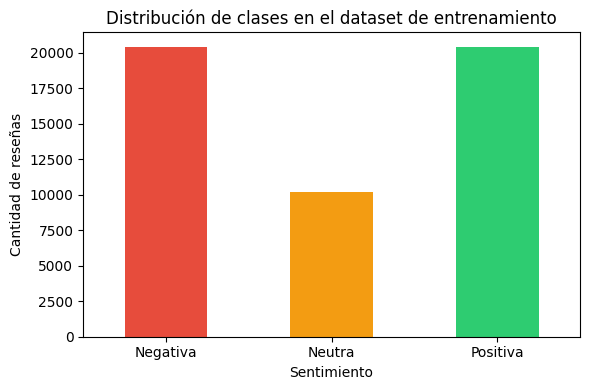


Observación: la clase neutra (1) está claramente subrepresentada respecto a las otras dos.


In [ ]:
print('Distribución de clases (train):')
print(train['label'].value_counts(normalize=True).sort_index())

fig, ax = plt.subplots(figsize=(6, 4))
label_names = {0: 'Negativa', 1: 'Neutra', 2: 'Positiva'}
train['label'].map(label_names).value_counts().reindex(['Negativa','Neutra','Positiva']).plot(
    kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71']
)
ax.set_title('Distribución de clases en el dataset de entrenamiento')
ax.set_xlabel('Sentimiento')
ax.set_ylabel('Cantidad de reseñas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nObservación: la clase neutra (1) está claramente subrepresentada respecto a las otras dos.')

Longitud de las reseñas:

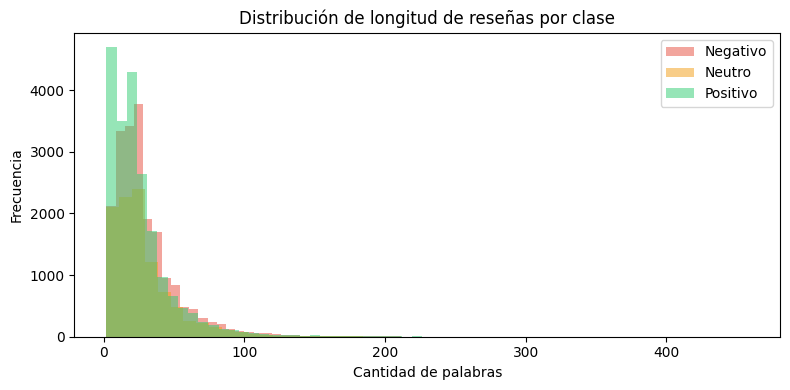

         count       mean        std  min   25%   50%   75%    max
label                                                             
0      20400.0  30.114412  24.700279  2.0  15.0  23.0  37.0  329.0
1      10200.0  28.673137  24.379983  2.0  13.0  23.0  35.0  458.0
2      20400.0  25.467010  23.917292  2.0  10.0  20.0  31.0  364.0


In [ ]:
# ── Longitud de las reseñas ──────────────────────────────────
train['longitud'] = train['text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip([0, 1, 2], ['#e74c3c', '#f39c12', '#2ecc71']):
    subset = train[train['label'] == label]['longitud']
    subset.plot(kind='hist', bins=50, alpha=0.5, label=label_names[label], color=color, ax=ax)

ax.set_title('Distribución de longitud de reseñas por clase')
ax.set_xlabel('Cantidad de palabras')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

print(train.groupby('label')['longitud'].describe())

#Preprocesamiento

## Limpieza preliminar

Veamos que porcentaje de valores nulos quedan en las columnas:

In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
id,0.0
text,0.0
label,0.0


No hay valores nulos

El campo id es un valor calor, no aporta nada al modelo, lo quito.

In [ ]:
df = df.drop(columns=['id'])

Reviso que los valores distintos de label sean solo 0, 1 y 2 como dice el enunciado

In [ ]:
df["label"].unique()

array([0, 2, 1])

Traducción de reseñas en inglés:

In [ ]:
import pandas as pd
import torch
from transformers import MarianMTModel, MarianTokenizer

df_train = pd.read_csv('train.csv')
df_train['text'] = df_train['text'].fillna('').astype(str)
df_train_idiomas = pd.read_csv('train_idiomas.csv')
df_train = df_train.merge(df_train_idiomas, on='id')

df_test = pd.read_csv('test.csv')
df_test['text'] = df_test['text'].fillna('').astype(str)
df_test_idiomas = pd.read_csv('test_idiomas.csv')
df_test = df_test.merge(df_test_idiomas, on='id')

print(f"Train: {len(df_train)} | Test: {len(df_test)}")

n_en_train = (df_train['idioma'] == 'en').sum()
n_en_test = (df_test['idioma'] == 'en').sum()
print(f"\nReseñas en inglés - Train: {n_en_train} | Test: {n_en_test}")

print("\nCargando traductor en→es (Helsinki-NLP/opus-mt-en-es)...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_name = 'Helsinki-NLP/opus-mt-en-es'
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name).to(device)
model.eval()

def traducir_lote(textos, batch_size=32):
    resultados = []
    n = len(textos)
    for i in range(0, n, batch_size):
        batch = textos[i:i+batch_size]
        try:
            inputs = tokenizer(batch, return_tensors='pt', padding=True,
                              truncation=True, max_length=256).to(device)
            with torch.no_grad():
                outputs = model.generate(**inputs, max_length=256, num_beams=2)
            preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            resultados.extend(preds)
        except Exception as e:
            print(f"  Error en batch {i}: {e}")
            for t in batch:
                try:
                    inp = tokenizer([t], return_tensors='pt', padding=True,
                                    truncation=True, max_length=256).to(device)
                    with torch.no_grad():
                        out = model.generate(**inp, max_length=256, num_beams=2)
                    resultados.append(tokenizer.decode(out[0], skip_special_tokens=True))
                except Exception:
                    resultados.append(t)
        if (i // batch_size) % 5 == 0:
            print(f"  Traducidas {min(i+batch_size, n)}/{n}")
    return resultados

print(f"\nTraduciendo {n_en_train} reseñas en inglés del TRAIN...")
df_en_train = df_train[df_train['idioma'] == 'en'].copy()
textos_en_train = df_en_train['text'].tolist()
traducciones_train = traducir_lote(textos_en_train)
df_en_train['text_traducido'] = traducciones_train

print(f"\nTraduciendo {n_en_test} reseñas en inglés del TEST...")
df_en_test = df_test[df_test['idioma'] == 'en'].copy()
textos_en_test = df_en_test['text'].tolist()
traducciones_test = traducir_lote(textos_en_test)
df_en_test['text_traducido'] = traducciones_test

df_train['text_final'] = df_train['text']
df_train.loc[df_train['idioma'] == 'en', 'text_final'] = df_en_train.set_index('id').loc[
    df_train[df_train['idioma'] == 'en']['id'], 'text_traducido'
].values

df_test['text_final'] = df_test['text']
df_test.loc[df_test['idioma'] == 'en', 'text_final'] = df_en_test.set_index('id').loc[
    df_test[df_test['idioma'] == 'en']['id'], 'text_traducido'
].values

df_train[['id', 'text_final', 'label', 'idioma']].rename(columns={'text_final': 'text'}).to_csv(
    'train_traducido.csv', index=False
)
df_test[['id', 'text_final', 'idioma']].rename(columns={'text_final': 'text'}).to_csv(
    'test_traducido.csv', index=False
)

print("\n=== Guardado ===")
print(f"train_traducido.csv: {len(df_train)} filas ({n_en_train} traducidas)")
print(f"test_traducido.csv:  {len(df_test)} filas ({n_en_test} traducidas)")

print("\n=== Ejemplos de traducciones del TRAIN ===")
for _, row in df_en_train.head(5).iterrows():
    print(f"\n[label={row['label']}]")
    print(f"  EN: {row['text'][:200]}")
    print(f"  ES: {row['text_traducido'][:200]}")

print("\n=== Ejemplos de traducciones del TEST ===")
for _, row in df_en_test.head(5).iterrows():
    print(f"\nID {row['id']}")
    print(f"  EN: {row['text'][:200]}")
    print(f"  ES: {row['text_traducido'][:200]}")

Train: 51000 | Test: 8500

Reseñas en inglés - Train: 1632 | Test: 23

Cargando traductor en→es (Helsinki-NLP/opus-mt-en-es)...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]


Traduciendo 1632 reseñas en inglés del TRAIN...
  Traducidas 32/1632
  Traducidas 192/1632
  Traducidas 352/1632
  Traducidas 512/1632
  Traducidas 672/1632
  Traducidas 832/1632
  Traducidas 992/1632
  Traducidas 1152/1632
  Traducidas 1312/1632
  Traducidas 1472/1632
  Traducidas 1632/1632

Traduciendo 23 reseñas en inglés del TEST...
  Traducidas 23/23

=== Guardado ===
train_traducido.csv: 51000 filas (1632 traducidas)
test_traducido.csv:  8500 filas (23 traducidas)

=== Ejemplos de traducciones del TRAIN ===

[label=0]
  EN: Got sent a dud. DIdn't even light up when plugged in. Seriously a waste of money and time.
  ES: Me mandaron a un idiota, ni siquiera se encendió cuando se enchufó, en serio, una pérdida de dinero y tiempo.

[label=2]
  EN: Good for typing. It has perfectly spaced key. No backlight, which makes it difficult to use in dark.
  ES: Es bueno para escribir. Tiene la llave perfectamente espaciado. No hay retroiluminación, lo que hace que sea difícil de usar en la o

Generamos nuevos .csv con las traducciones ya que en las pruebas realizadas se abordó el idioma de las reseñas de diferentes maneras (ej: uso de un modelo multilingüe)

### Normalización del texto
Las transformaciones aplicadas son:
1. Convertir a minúsculas
2. Eliminar URLs
3. Eliminar caracteres especiales y números
4. Eliminar espacios extra

In [ ]:
def limpiar_texto(texto):
    """
    Preprocesamiento básico de texto en español.
    """
    texto = str(texto)                                          # Asegurar string
    texto = texto.lower()                                       # Minúsculas
    texto = re.sub(r'http\S+|www\S+', '', texto)               # Eliminar URLs
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)            # Solo letras en español
    texto = re.sub(r'\s+', ' ', texto).strip()                 # Espacios extra
    return texto

# Aplicar a train y test
train['text_clean'] = train['text'].apply(limpiar_texto)
test['text_clean']  = test['text'].apply(limpiar_texto)

# Ver un ejemplo antes y después
print('ORIGINAL:')
print(train['text'].iloc[0])
print()
print('LIMPIO:')
print(train['text_clean'].iloc[0])

ORIGINAL:
Lo primero recibí el paquete en una bolsa toda rota como si se uniera aras tradicional por el asfalto los carteles están rallados y abollados en si no tienen mala pinta pero los han maltratado en el transporte

LIMPIO:
lo primero recibí el paquete en una bolsa toda rota como si se uniera aras tradicional por el asfalto los carteles están rallados y abollados en si no tienen mala pinta pero los han maltratado en el transporte


# Técnicas exploradas

##Incluir conectores "pero", "aunque" como parámetros


**Hipótesis**: agregar al meta-modelo del stacking una columna que indique si la reseña contiene un conector de contraste ("pero", "aunque") debería ayudarlo a arbitrar mejor en los casos ambiguos.

**Resultado esperado**: mejora del macro F1 en el stacking.[link text](https://)

In [ ]:
import numpy as np
import pandas as pd
import joblib
import re
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values
textos = df['text'].fillna('').astype(str).values

proba_lr      = joblib.load('modelos/y_proba_oof_lr_emb_es.joblib')
proba_xe      = joblib.load('modelos/y_proba_oof_xgb_emb_es_peso30.joblib')
proba_xt      = joblib.load('modelos/y_proba_oof_xgb_tfidf_peso20.joblib')
proba_nb      = joblib.load('modelos/y_proba_oof_cnb.joblib')
proba_lr_mini = joblib.load('modelos/y_proba_oof_lr_minilm.joblib')

re_pero = re.compile(r'(?:\bpero\b|\baunque\b|sin embargo|no obstante|si bien|aun así)', re.I)
tiene_pero = np.array([bool(re_pero.search(t)) for t in textos]).astype(float)

X_meta_base = np.hstack([proba_lr, proba_xe, proba_xt, proba_nb, proba_lr_mini])
X_meta_con_feature = np.hstack([X_meta_base, tiene_pero.reshape(-1, 1)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1)

y_pred_sin = cross_val_predict(meta, X_meta_base, y, cv=cv, n_jobs=-1)
y_pred_con = cross_val_predict(meta, X_meta_con_feature, y, cv=cv, n_jobs=-1)

f1_sin = f1_score(y, y_pred_sin, average='macro')
f1_con = f1_score(y, y_pred_con, average='macro')

print(f"Stacking SIN feature 'pero/aunque': macro F1 = {f1_sin:.4f}")
print(f"Stacking CON feature 'pero/aunque': macro F1 = {f1_con:.4f}")
print(f"Diferencia: {f1_con - f1_sin:+.4f}")

Stacking SIN feature 'pero/aunque': macro F1 = 0.6942
Stacking CON feature 'pero/aunque': macro F1 = 0.6948
Diferencia: +0.0007


La diferencia es despreciable. El meta-modelo ya extrae implícitamente la 'ambigüedad' a través de la forma de las distribuciones de probabilidad de los modelos base.

## Todo lo que viene antes del "pero" no importa

**Hipótesis**: si la opinión dominante está después del "pero" (como suele suceder en oraciones del tipo "X pero Y"), entrenar un modelo solo sobre el texto posterior al conector debería mejorar la clasificación de las reseñas mixtas.

**Resultado esperado**: mejor macro F1 sobre el subconjunto de reseñas con contraste.

In [ ]:
import numpy as np
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values
textos = df['text'].fillna('').astype(str).values

re_pero = re.compile(r'\b(pero|aunque)\b', re.I)
tiene_pero = np.array([bool(re_pero.search(t)) for t in textos])
textos_pero = textos[tiene_pero]
y_pero = y[tiene_pero]

print(f"Reseñas con 'pero/aunque': {len(textos_pero)}")

def recortar_despues_pero(texto):
    m = list(re.finditer(r'\b(pero|aunque)\b', texto, re.I))
    if not m:
        return texto
    inicio = m[-1].end()
    return texto[inicio:].strip()

textos_recortados = np.array([recortar_despues_pero(t) for t in textos_pero])

def evaluar(X_textos, y, label):
    pipeline = make_pipeline(
        TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, sublinear_tf=True),
        LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1)
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred = cross_val_predict(pipeline, X_textos, y, cv=cv, n_jobs=-1)
    f1 = f1_score(y, y_pred, average='macro')
    print(f"{label}: macro F1 = {f1:.4f}")
    return f1

f1_completo = evaluar(textos_pero, y_pero, "Texto COMPLETO")
f1_recortado = evaluar(textos_recortados, y_pero, "Texto SOLO DESPUÉS del 'pero'")

print(f"\nDiferencia: {f1_recortado - f1_completo:+.4f}")

Reseñas con 'pero/aunque': 15568
Texto COMPLETO: macro F1 = 0.5849
Texto SOLO DESPUÉS del 'pero': macro F1 = 0.5252

Diferencia: -0.0597


El "pero" no actúa de forma consistente como marcador de la opinión dominante. En muchas reseñas, lo importante está antes del conector, o se reparte entre ambas partes. Recortar el texto destruye información valiosa para el modelo.

## Limpieza de reseñas mal etiquetadas

**Hipótesis**: si una porción del dataset tiene etiquetas inconsistentes con el contenido del texto, limpiarlas y reentrenar debería mejorar la calidad del modelo.

**Procedimiento**: se identifican como "sospechosas" aquellas reseñas donde los modelos del stacking predicen con alta confianza (>0.80) una clase distinta a la etiqueta. Luego se reentrena el meta-modelo sin esas muestras.

**Resultado esperado**: mejor macro F1 sobre el train (y por extensión, en Kaggle).

In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

df = pd.read_csv('train.csv')
y = df['label'].values

proba_lr      = joblib.load('modelos/y_proba_oof_lr_emb_es.joblib')
proba_xe      = joblib.load('modelos/y_proba_oof_xgb_emb_es_peso30.joblib')
proba_xt      = joblib.load('modelos/y_proba_oof_xgb_tfidf_peso20.joblib')
proba_nb      = joblib.load('modelos/y_proba_oof_cnb.joblib')
proba_lr_mini = joblib.load('modelos/y_proba_oof_lr_minilm.joblib')

X_meta = np.hstack([proba_lr, proba_xe, proba_xt, proba_nb, proba_lr_mini])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1)

proba_stack = cross_val_predict(meta, X_meta, y, cv=cv, n_jobs=-1, method='predict_proba')
pred_stack = proba_stack.argmax(axis=1)
conf_stack = proba_stack.max(axis=1)

sospechosas = (pred_stack != y) & (conf_stack > 0.80)

print(f"Muestras sospechosas: {sospechosas.sum()} ({sospechosas.mean():.1%} del dataset)")
print(f"Distribución por clase original:")
for c in [0, 1, 2]:
    en_clase = (y[sospechosas] == c).sum()
    total_clase = (y == c).sum()
    print(f"  Clase {c}: {en_clase} sospechosas de {total_clase} ({en_clase/total_clase:.1%})")

f1_completo = f1_score(y, pred_stack, average='macro')

mask_limpio = ~sospechosas
X_meta_limpio = X_meta[mask_limpio]
y_limpio = y[mask_limpio]
y_pred_limpio_eval = cross_val_predict(meta, X_meta_limpio, y_limpio, cv=cv, n_jobs=-1)
f1_limpio = f1_score(y_limpio, y_pred_limpio_eval, average='macro')

meta.fit(X_meta_limpio, y_limpio)
y_pred_global = meta.predict(X_meta)
f1_global = f1_score(y, y_pred_global, average='macro')

f1_no_sosp = f1_score(y[~sospechosas], y_pred_global[~sospechosas], average='macro')
f1_sosp = f1_score(y[sospechosas], y_pred_global[sospechosas], average='macro')

print(f"\n{'='*60}")
print(f"Stacking sobre TODO el train (baseline):        F1 = {f1_completo:.4f}")
print(f"Stacking sobre subset LIMPIO (sin sospechosas): F1 = {f1_limpio:.4f}")
print(f"Modelo limpio aplicado a TODO el train:         F1 = {f1_global:.4f}")
print(f"{'='*60}")
print(f"\nDesglose del modelo limpio:")
print(f"  Sobre muestras NO sospechosas: F1 = {f1_no_sosp:.4f}")
print(f"  Sobre muestras sospechosas:    F1 = {f1_sosp:.4f}")

Muestras sospechosas: 1182 (2.3% del dataset)
Distribución por clase original:
  Clase 0: 64 sospechosas de 20400 (0.3%)
  Clase 1: 1011 sospechosas de 10200 (9.9%)
  Clase 2: 107 sospechosas de 20400 (0.5%)

Stacking sobre TODO el train (baseline):        F1 = 0.6942
Stacking sobre subset LIMPIO (sin sospechosas): F1 = 0.7125
Modelo limpio aplicado a TODO el train:         F1 = 0.6968

Desglose del modelo limpio:
  Sobre muestras NO sospechosas: F1 = 0.7132
  Sobre muestras sospechosas:    F1 = 0.0000


**Conclusión**: el modelo limpio mejora dramáticamente sobre las muestras no sospechosas pero falla casi totalmente sobre las sospechosas. Esto demuestra empíricamente que el ruido de etiquetas no es un artefacto del entrenamiento, sino una característica estructural del dataset que también está presente en el test de Kaggle. La mejora en train no se traslada al puntaje final.

## Ajuste del umbral de decisión para la clase 1

**Hipótesis**: dado que la clase 1 es la más difícil, multiplicar su probabilidad por un factor antes del argmax podría rescatar predicciones de neutro que el modelo está dudando entre 0/1 o 1/2.

**Resultado esperado**: mejora del recall (y del F1) de la clase 1.

In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values

# Probas OOF de los 5 modelos clásicos
proba_lr      = joblib.load('modelos/y_proba_oof_lr_emb_es.joblib')
proba_xe      = joblib.load('modelos/y_proba_oof_xgb_emb_es_peso30.joblib')
proba_xt      = joblib.load('modelos/y_proba_oof_xgb_tfidf_peso20.joblib')
proba_nb      = joblib.load('modelos/y_proba_oof_cnb.joblib')
proba_lr_mini = joblib.load('modelos/y_proba_oof_lr_minilm.joblib')

X_meta = np.hstack([proba_lr, proba_xe, proba_xt, proba_nb, proba_lr_mini])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1)

proba_stack = cross_val_predict(meta, X_meta, y, cv=cv, n_jobs=-1, method='predict_proba')

y_pred_baseline = proba_stack.argmax(axis=1)
f1_baseline = f1_score(y, y_pred_baseline, average='macro')

multiplicadores = [0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
resultados = []

for mult in multiplicadores:
    proba_ajustada = proba_stack.copy()
    proba_ajustada[:, 1] *= mult
    y_pred = proba_ajustada.argmax(axis=1)
    f1 = f1_score(y, y_pred, average='macro')
    resultados.append({'multiplicador': mult, 'macro_f1': f1})
    print(f"Multiplicador clase 1 = {mult:.1f}: macro F1 = {f1:.4f}")

mejor = max(resultados, key=lambda r: r['macro_f1'])
print(f"\nMejor multiplicador: {mejor['multiplicador']} con F1 = {mejor['macro_f1']:.4f}")
print(f"Baseline (mult=1.0):                F1 = {f1_baseline:.4f}")
print(f"Mejora: {mejor['macro_f1'] - f1_baseline:+.4f}")

Multiplicador clase 1 = 0.8: macro F1 = 0.6969
Multiplicador clase 1 = 0.9: macro F1 = 0.6961
Multiplicador clase 1 = 1.0: macro F1 = 0.6942
Multiplicador clase 1 = 1.1: macro F1 = 0.6918
Multiplicador clase 1 = 1.2: macro F1 = 0.6888
Multiplicador clase 1 = 1.3: macro F1 = 0.6841
Multiplicador clase 1 = 1.4: macro F1 = 0.6802
Multiplicador clase 1 = 1.5: macro F1 = 0.6754

Mejor multiplicador: 0.8 con F1 = 0.6969
Baseline (mult=1.0):                F1 = 0.6942
Mejora: +0.0027


**Conclusión**: aunque hay un pequeño máximo local, la mejora está dentro del ruido experimental y no se traslada al puntaje de Kaggle. Las distribuciones de confianza en aciertos y errores se solapan demasiado como para que un ajuste de umbral global funcione.

## Técnica incorporada: sample weights para compensar el desbalance de la clase 1

**Hipótesis**: dado que la clase 1 (neutra) representa solo el 20% del dataset y es la más difícil de clasificar, asignar más peso a sus muestras durante el entrenamiento debería mejorar su F1 sin sacrificar las clases extremas.

**Procedimiento**: en lugar de tratar todas las muestras por igual, se asigna un `sample_weight` mayor a las muestras de clase 1 durante el entrenamiento de XGBoost. Esto hace que el modelo penalice más fuertemente los errores en esa clase, forzándolo a invertir más capacidad de modelado en aprenderla.

**Resultado**: explorando distintos valores del peso de clase 1 (1.0, 1.5, 2.0, 2.5, 3.0), se observó que valores entre 2.0 y 3.0 producen una mejora consistente del macro F1. Las dos configuraciones quedaron incorporadas a los modelos finales del stacking:

- **XGBoost sobre TF-IDF con peso clase 1 = 2.0**: mejora de **+0.013** respecto al baseline sin pesos (de ~0.630 a ~0.643).
- **XGBoost sobre embeddings densos con peso clase 1 = 3.0**: el peso óptimo es mayor sobre embeddings porque el modelo individual ya rinde mejor y tolera más sesgo hacia la clase 1.

**Conclusión**: ponderar la clase minoritaria durante el entrenamiento es una técnica simple y efectiva para problemas con desbalance moderado. La mejora se concentra en el F1 de la clase 1 sin degradar significativamente las clases extremas. Esta misma estrategia se replicó posteriormente en BETO mediante **weighted cross-entropy** con pesos `[1.0, 2.0, 1.0]`, que aportó +0.0071 en la búsqueda de hiperparámetros y +0.00325 en el score de Kaggle.

### Stacking de modelos diversos

**Hipótesis**: combinar modelos con representaciones del texto distintas y arquitecturas distintas debería aprovechar la diversidad de sus errores. Si cada modelo se equivoca en casos diferentes, un meta-modelo puede aprender a confiar en cada uno según el contexto.

**Resultado esperado**: el stacking debe superar al mejor modelo individual.

In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values

proba_lr      = joblib.load('modelos/y_proba_oof_lr_emb_es.joblib')
proba_xe      = joblib.load('modelos/y_proba_oof_xgb_emb_es_peso30.joblib')
proba_xt      = joblib.load('modelos/y_proba_oof_xgb_tfidf_peso20.joblib')
proba_nb      = joblib.load('modelos/y_proba_oof_cnb.joblib')
proba_lr_mini = joblib.load('modelos/y_proba_oof_lr_minilm.joblib')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1)

f1_modelos = {
    'LR sobre embeddings ES':   f1_score(y, proba_lr.argmax(axis=1), average='macro'),
    'XGB sobre embeddings ES':  f1_score(y, proba_xe.argmax(axis=1), average='macro'),
    'XGB sobre TF-IDF':         f1_score(y, proba_xt.argmax(axis=1), average='macro'),
    'ComplementNB sobre TF-IDF':f1_score(y, proba_nb.argmax(axis=1), average='macro'),
    'LR sobre MiniLM':          f1_score(y, proba_lr_mini.argmax(axis=1), average='macro'),
}

print("=== F1 individual de los modelos base ===")
for nombre, f1 in f1_modelos.items():
    print(f"  {nombre:<32}: {f1:.4f}")

combinaciones = [
    ("Stack 2 (LR-ES + XGB-ES)",            [proba_lr, proba_xe]),
    ("Stack 3 (+ XGB-TFIDF)",               [proba_lr, proba_xe, proba_xt]),
    ("Stack 4 (+ NB)",                      [proba_lr, proba_xe, proba_xt, proba_nb]),
    ("Stack 5 (+ LR-MiniLM)",               [proba_lr, proba_xe, proba_xt, proba_nb, proba_lr_mini]),
]

resultados_stack = []
for nombre, probas in combinaciones:
    X_meta = np.hstack(probas)
    y_pred = cross_val_predict(meta, X_meta, y, cv=cv, n_jobs=-1)
    f1 = f1_score(y, y_pred, average='macro')
    resultados_stack.append({'nombre': nombre, 'macro_f1': f1})
    print(f"  {nombre:<32}: {f1:.4f}")

print(f"\nMejor modelo individual: {max(f1_modelos.values()):.4f}")
print(f"Stacking final (5 modelos): {resultados_stack[-1]['macro_f1']:.4f}")
print(f"Mejora del stacking sobre el mejor individual: {resultados_stack[-1]['macro_f1'] - max(f1_modelos.values()):+.4f}")

=== F1 individual de los modelos base ===
  LR sobre embeddings ES          : 0.6664
  XGB sobre embeddings ES         : 0.6534
  XGB sobre TF-IDF                : 0.6432
  ComplementNB sobre TF-IDF       : 0.6292
  LR sobre MiniLM                 : 0.6611
  Stack 2 (LR-ES + XGB-ES)        : 0.6678
  Stack 3 (+ XGB-TFIDF)           : 0.6846
  Stack 4 (+ NB)                  : 0.6909
  Stack 5 (+ LR-MiniLM)           : 0.6942

Mejor modelo individual: 0.6664
Stacking final (5 modelos): 0.6942
Mejora del stacking sobre el mejor individual: +0.0277


**Conclusión**: el stacking supera al mejor modelo individual al combinar sus probabilidades. Cada modelo nuevo aporta diversidad y suma incrementalmente al rendimiento. Al incluir adicionalmente las redes neuronales (BETO y RoBERTuito), el macro F1 sube a 0.73180 en Kaggle, ya que los transformers capturan información estructural del texto (especialmente en reseñas con "pero") que los modelos clásicos no pueden extraer.

### TF-IDF con n-gramas y sublinear_tf

**Hipótesis**: una representación TF-IDF con bigramas y normalización logarítmica de frecuencias (`sublinear_tf=True`) debería superar a bag of words puro porque captura combinaciones de palabras frecuentes ("no me gustó", "muy bueno") y reduce el peso desproporcionado de palabras muy repetidas.

**Resultado esperado**: mejor macro F1 que CountVectorizer baseline.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values
textos = df['text'].fillna('').astype(str).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluar_representacion(vectorizer, label):
    pipeline = make_pipeline(
        vectorizer,
        LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1),
    )
    y_pred = cross_val_predict(pipeline, textos, y, cv=cv, n_jobs=-1)
    f1 = f1_score(y, y_pred, average='macro')
    print(f"{label}: macro F1 = {f1:.4f}")
    return f1

f1_bow         = evaluar_representacion(CountVectorizer(max_features=20000, min_df=2), "Bag of Words (CountVectorizer)")
f1_tfidf_basic = evaluar_representacion(TfidfVectorizer(max_features=20000, min_df=2), "TF-IDF unigrama")
f1_tfidf_bi    = evaluar_representacion(TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2), "TF-IDF + bigramas")
f1_tfidf_full  = evaluar_representacion(TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, sublinear_tf=True), "TF-IDF + bigramas + sublinear_tf")

print(f"\nMejora total: {f1_tfidf_full - f1_bow:+.4f}")

Bag of Words (CountVectorizer): macro F1 = 0.6285
TF-IDF unigrama: macro F1 = 0.6498
TF-IDF + bigramas: macro F1 = 0.6673
TF-IDF + bigramas + sublinear_tf: macro F1 = 0.6683

Mejora total: +0.0398


**Conclusión**: cada mejora incremental (TF-IDF sobre BoW, bigramas, sublinear_tf) suma al rendimiento.

## Embeddings densos en español

**Hipótesis**: representaciones semánticas pre-entrenadas en español deberían capturar similitud semántica entre reseñas que TF-IDF no puede capturar (sinónimos, paráfrasis, variaciones lingüísticas).

**Resultado esperado**: un clasificador entrenado sobre estos embeddings debería rendir comparable o mejor que TF-IDF, y aportar diversidad al stacking.

In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values
textos = df['text'].fillna('').astype(str).values

X_emb_es = np.load('modelos/embeddings_spanish.npy')
print(f"Embeddings ES: {X_emb_es.shape}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_emb = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1),
)
y_pred_emb = cross_val_predict(pipeline_emb, X_emb_es, y, cv=cv, n_jobs=-1)
f1_emb = f1_score(y, y_pred_emb, average='macro')

pipeline_tfidf = make_pipeline(
    TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, sublinear_tf=True),
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1),
)
y_pred_tfidf = cross_val_predict(pipeline_tfidf, textos, y, cv=cv, n_jobs=-1)
f1_tfidf = f1_score(y, y_pred_tfidf, average='macro')

print(f"\nLogReg sobre TF-IDF:                    macro F1 = {f1_tfidf:.4f}")
print(f"LogReg sobre embeddings ES (768 dims):  macro F1 = {f1_emb:.4f}")
print(f"Diferencia: {f1_emb - f1_tfidf:+.4f}")

discrepancias = (y_pred_emb != y_pred_tfidf).sum()
print(f"\nDe 51000 muestras, los dos modelos discrepan en {discrepancias} ({discrepancias/len(y):.1%}).")
print("Esa diversidad es lo que el stacking aprovecha cuando combina sus probabilidades.")

Embeddings ES: (51000, 768)

LogReg sobre TF-IDF:                    macro F1 = 0.6683
LogReg sobre embeddings ES (768 dims):  macro F1 = 0.6664
Diferencia: -0.0019

De 51000 muestras, los dos modelos discrepan en 12766 (25.0%).
Esa diversidad es lo que el stacking aprovecha cuando combina sus probabilidades.


**Conclusión**: los embeddings semánticos en español rinden comparablemente a TF-IDF como modelo individual, pero su valor real está en la diversidad de sus errores. Las dos representaciones capturan información distinta del texto (TF-IDF es léxica, embeddings es semántica), por lo que se incluyeron ambas como modelos base del stacking.

## Ensemble de BETOs con múltiples seeds

El fine-tuning de transformers tiene una varianza intrínseca debido a la inicialización aleatoria de la cabeza de clasificación y al orden de los batches durante el entrenamiento. Distintas seeds producen modelos con desempeño similar en promedio pero que se equivocan en muestras distintas.

Para reducir esta varianza, se entrenaron **4 instancias de BETO con seeds distintas** (42, 7, 123, 2024), cada una sobre el 100% del train con la misma configuración de hiperparámetros (incluyendo weighted cross-entropy). Las probabilidades sobre el test de Kaggle se promediaron antes del argmax.

**Resultado**: al sumar el ensemble de BETOs a un stacking de 7 modelos, el score de Kaggle subió de **0.73034 a 0.73180** (+0.00146). La mejora, aunque pequeña, es consistente con lo esperado: el promedio cancela errores aleatorios de cada modelo individual sin introducir sesgos sistemáticos.

No se incluyó en el modelo final debido al tradeoff entre costo y beneficio.

## Features de sentimiento con pysentimiento

Se probó enriquecer los modelos clásicos con features adicionales extraídas mediante **pysentimiento**, una librería especializada en análisis de sentimiento en español. Para cada reseña se calcularon las probabilidades de POS/NEU/NEG según pysentimiento y se concatenaron como features adicionales a los embeddings y al TF-IDF.

**Resultado**:
- Como modelo individual: mejora marginal de **+1%** en macro F1.
- En el stacking final: mejora de **~0%** (ruido).

**Conclusión**: pysentimiento es esencialmente un transformer pre-entrenado en sentimiento. La información que aporta ya está contenida implícitamente en las probabilidades de BETO fine-tuneado y de los modelos clásicos sobre TF-IDF y embeddings densos. Sumarla al stacking es redundante, ya que el meta-modelo ya recibe esa señal vía las probabilidades de los modelos base.

## Features estructurales del texto

**Hipótesis**: características estructurales del texto (longitud en palabras, número de oraciones, posición relativa del primer "pero") podrían correlacionar con la dificultad y la clase de la reseña, ayudando al meta-modelo a arbitrar mejor.

**Resultado esperado**: mejora del macro F1 al sumar estas features al stacking.

In [ ]:
import numpy as np
import pandas as pd
import joblib
import re
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values
textos = df['text'].fillna('').astype(str).values

proba_lr      = joblib.load('modelos/y_proba_oof_lr_emb_es.joblib')
proba_xe      = joblib.load('modelos/y_proba_oof_xgb_emb_es_peso30.joblib')
proba_xt      = joblib.load('modelos/y_proba_oof_xgb_tfidf_peso20.joblib')
proba_nb      = joblib.load('modelos/y_proba_oof_cnb.joblib')
proba_lr_mini = joblib.load('modelos/y_proba_oof_lr_minilm.joblib')

re_pero = re.compile(r'\b(pero|aunque)\b', re.I)

def features_estructurales(textos):
    feats = []
    for t in textos:
        n_palabras = len(t.split())
        n_caracteres = len(t)
        n_oraciones = max(1, t.count('.') + t.count('!') + t.count('?'))

        m = re_pero.search(t)
        pos_pero = m.start() / max(len(t), 1) if m else 0.0

        feats.append([n_palabras, n_caracteres, n_oraciones, pos_pero])
    return np.array(feats)

X_struct = features_estructurales(textos)
scaler = StandardScaler()
X_struct_std = scaler.fit_transform(X_struct)
print(f"Features estructurales: {X_struct.shape} (longitud, caracteres, oraciones, pos_pero)")

X_meta_base = np.hstack([proba_lr, proba_xe, proba_xt, proba_nb, proba_lr_mini])
X_meta_con_struct = np.hstack([X_meta_base, X_struct_std])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1)

y_pred_sin = cross_val_predict(meta, X_meta_base, y, cv=cv, n_jobs=-1)
y_pred_con = cross_val_predict(meta, X_meta_con_struct, y, cv=cv, n_jobs=-1)

f1_sin = f1_score(y, y_pred_sin, average='macro')
f1_con = f1_score(y, y_pred_con, average='macro')

print(f"\nStacking SIN features estructurales: macro F1 = {f1_sin:.4f}")
print(f"Stacking CON features estructurales: macro F1 = {f1_con:.4f}")
print(f"Diferencia: {f1_con - f1_sin:+.4f}")

Features estructurales: (51000, 4) (longitud, caracteres, oraciones, pos_pero)

Stacking SIN features estructurales: macro F1 = 0.6942
Stacking CON features estructurales: macro F1 = 0.6945
Diferencia: +0.0003


**Conclusión**: las features estructurales no aportan al stacking. La longitud y la estructura del texto ya están implícitas en las representaciones TF-IDF (norma del vector, cantidad de features activas) y en los embeddings densos. Sumarlas explícitamente es redundante.

## Regla post-hoc por confianza

**Hipótesis**: si el modelo predijo clase 1 (neutra) con baja confianza, podría estar dudando entre clase 1 y un extremo. Reasignar esas predicciones a la segunda clase más probable debería corregir parte de esos casos ambiguos.

**Procedimiento**: para cada predicción con `argmax = 1`, si la confianza máxima está por debajo de un umbral, reasignar a la clase con segunda probabilidad más alta.

**Resultado esperado**: mejora del macro F1 al corregir casos donde el modelo "se refugia en el neutro" por defecto.

In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values

proba_lr      = joblib.load('modelos/y_proba_oof_lr_emb_es.joblib')
proba_xe      = joblib.load('modelos/y_proba_oof_xgb_emb_es_peso30.joblib')
proba_xt      = joblib.load('modelos/y_proba_oof_xgb_tfidf_peso20.joblib')
proba_nb      = joblib.load('modelos/y_proba_oof_cnb.joblib')
proba_lr_mini = joblib.load('modelos/y_proba_oof_lr_minilm.joblib')

X_meta = np.hstack([proba_lr, proba_xe, proba_xt, proba_nb, proba_lr_mini])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1)

proba_stack = cross_val_predict(meta, X_meta, y, cv=cv, n_jobs=-1, method='predict_proba')
pred_baseline = proba_stack.argmax(axis=1)
f1_baseline = f1_score(y, pred_baseline, average='macro')

umbrales = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
resultados = []

for umbral in umbrales:
    pred_ajustada = pred_baseline.copy()

    es_clase1_dudoso = (pred_baseline == 1) & (proba_stack.max(axis=1) < umbral)

    proba_sin_c1 = proba_stack.copy()
    proba_sin_c1[:, 1] = -np.inf
    segunda_opcion = proba_sin_c1.argmax(axis=1)

    pred_ajustada[es_clase1_dudoso] = segunda_opcion[es_clase1_dudoso]

    f1 = f1_score(y, pred_ajustada, average='macro')
    resultados.append({'umbral': umbral, 'macro_f1': f1, 'reasignaciones': es_clase1_dudoso.sum()})
    print(f"Umbral={umbral}: {es_clase1_dudoso.sum()} reasignaciones, macro F1 = {f1:.4f}")

print(f"\nBaseline (sin regla): macro F1 = {f1_baseline:.4f}")
mejor = max(resultados, key=lambda r: r['macro_f1'])
print(f"Mejor umbral: {mejor['umbral']} con F1 = {mejor['macro_f1']:.4f}")
print(f"Mejora máxima: {mejor['macro_f1'] - f1_baseline:+.4f}")

Umbral=0.4: 49 reasignaciones, macro F1 = 0.6943
Umbral=0.45: 616 reasignaciones, macro F1 = 0.6954
Umbral=0.5: 3192 reasignaciones, macro F1 = 0.6964
Umbral=0.55: 6246 reasignaciones, macro F1 = 0.6870
Umbral=0.6: 9100 reasignaciones, macro F1 = 0.6657
Umbral=0.65: 11452 reasignaciones, macro F1 = 0.6350

Baseline (sin regla): macro F1 = 0.6942
Mejor umbral: 0.5 con F1 = 0.6964
Mejora máxima: +0.0022


**Conclusión**: la regla no aporta. Cuando el modelo duda prediciendo clase 1, la clase real se reparte casi 50/50 entre 0 y 2, por lo que reasignar siempre "gana algo y pierde algo". A umbrales muy altos la regla se vuelve agresiva y deteriora el F1.

## Cascada con especialista binario 0-vs-2

**Hipótesis**: entrenar un modelo binario especializado solo en distinguir reseñas negativas de positivas (sin la clase 1) debería alcanzar mayor precisión en esa subtarea. Luego, cuando el stacking predice clase 1 con baja confianza, consultar al especialista para decidir si la reseña es realmente negativa o positiva.

**Resultado esperado**: mejora del macro F1 al rescatar casos donde el modelo se refugia incorrectamente en el neutro.

In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

df = pd.read_csv('train.csv')
y = df['label'].values
textos = df['text'].fillna('').astype(str).values

mask_extremos = (y != 1)
y_bin = (y[mask_extremos] == 2).astype(int)  # 0 = negativa, 1 = positiva
textos_extremos = textos[mask_extremos]

print(f"Especialista entrenado sobre {len(y_bin)} muestras (clases 0 y 2)")

especialista = make_pipeline(
    TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, sublinear_tf=True),
    LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1),
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_bin = cross_val_predict(especialista, textos_extremos, y_bin, cv=cv, n_jobs=-1)
f1_especialista_subtarea = f1_score(y_bin, y_pred_bin, average='macro')
print(f"F1 del especialista en su subtarea (0 vs 2): {f1_especialista_subtarea:.4f}")

especialista.fit(textos_extremos, y_bin)
proba_especialista_full = especialista.predict_proba(textos)[:, 1]  # P(clase 2 | texto)

proba_lr      = joblib.load('modelos/y_proba_oof_lr_emb_es.joblib')
proba_xe      = joblib.load('modelos/y_proba_oof_xgb_emb_es_peso30.joblib')
proba_xt      = joblib.load('modelos/y_proba_oof_xgb_tfidf_peso20.joblib')
proba_nb      = joblib.load('modelos/y_proba_oof_cnb.joblib')
proba_lr_mini = joblib.load('modelos/y_proba_oof_lr_minilm.joblib')

X_meta = np.hstack([proba_lr, proba_xe, proba_xt, proba_nb, proba_lr_mini])
meta = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', n_jobs=-1)
proba_stack = cross_val_predict(meta, X_meta, y, cv=cv, n_jobs=-1, method='predict_proba')
pred_baseline = proba_stack.argmax(axis=1)
f1_baseline = f1_score(y, pred_baseline, average='macro')

umbrales = [0.40, 0.45, 0.50, 0.55, 0.60]
resultados = []

for umbral in umbrales:
    pred_cascada = pred_baseline.copy()
    activar = (pred_baseline == 1) & (proba_stack.max(axis=1) < umbral)
    pred_cascada[activar] = np.where(proba_especialista_full[activar] > 0.5, 2, 0)

    f1 = f1_score(y, pred_cascada, average='macro')
    resultados.append({'umbral': umbral, 'macro_f1': f1, 'activaciones': activar.sum()})
    print(f"Umbral={umbral}: {activar.sum()} activaciones, macro F1 = {f1:.4f}")

print(f"\nBaseline (sin cascada): macro F1 = {f1_baseline:.4f}")
mejor = max(resultados, key=lambda r: r['macro_f1'])
print(f"Mejor umbral: {mejor['umbral']} con F1 = {mejor['macro_f1']:.4f}")
print(f"Mejora máxima: {mejor['macro_f1'] - f1_baseline:+.4f}")
print(f"\nNota: el especialista alcanza F1 = {f1_especialista_subtarea:.4f} en su subtarea (0 vs 2),")

Especialista entrenado sobre 40800 muestras (clases 0 y 2)
F1 del especialista en su subtarea (0 vs 2): 0.8923
Umbral=0.4: 49 activaciones, macro F1 = 0.6944
Umbral=0.45: 616 activaciones, macro F1 = 0.6962
Umbral=0.5: 3192 activaciones, macro F1 = 0.6978
Umbral=0.55: 6246 activaciones, macro F1 = 0.6902
Umbral=0.6: 9100 activaciones, macro F1 = 0.6707

Baseline (sin cascada): macro F1 = 0.6942
Mejor umbral: 0.5 con F1 = 0.6978
Mejora máxima: +0.0036

Nota: el especialista alcanza F1 = 0.8923 en su subtarea (0 vs 2),


**Conclusión**: el especialista rinde muy bien en su subtarea binaria, pero la cascada no mejora el sistema completo. El especialista, por diseño, no puede predecir clase 1. Cuando se activa sobre un acierto legítimo de clase 1, lo destruye. La confianza del stacking no separa errores de aciertos con suficiente nitidez para activar la regla solo donde conviene.

## Features de ambigüedad

Se probó enriquecer el meta-modelo del stacking con features derivadas de la **forma de las distribuciones de probabilidad** de los modelos base:

- **Entropía** de la distribución de probabilidades (alta cuando el modelo duda).
- **Diferencia entre la probabilidad top-1 y top-2** (baja cuando el modelo duda entre dos clases).
- **Desacuerdo entre modelos base** (cuántos modelos votan por la misma clase).

**Resultado**: el macro F1 del stacking se mantuvo en **0% de mejora**.

**Conclusión**: el meta-modelo usado (LogReg) ya recibía directamente las 15 probabilidades de los modelos base (5 modelos × 3 clases), por lo que cualquier feature derivada de ellas es redundante.

# Modelos finales

## Random Forest

### Representación del texto: Bag of Words vs TF-IDF

El enunciado pide explorar al menos dos representaciones del texto y comparar su impacto en el desempeño. Para Random Forest evaluamos:

1. **Bag of Words (BoW)**: conteo simple de ocurrencias de cada término (`CountVectorizer`).
2. **TF-IDF**: pondera cada término según su frecuencia en el documento y su rareza en el corpus (`TfidfVectorizer`).

Para que la comparación sea justa, usamos el mismo vocabulario máximo, el mismo rango de n-gramas y el mismo `min_df` en ambas representaciones. Entrenamos un Random Forest base (sin tuning) sobre cada una y comparamos el F1 macro en validación para decidir con cuál seguimos el resto del trabajo.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Parámetros comunes para que la comparación sea comparable
PARAMS_VOCAB = dict(max_features=15000, ngram_range=(1, 2), min_df=2)

vectorizer_bow = CountVectorizer(**PARAMS_VOCAB)
vectorizer_tfidf = TfidfVectorizer(**PARAMS_VOCAB, sublinear_tf=True)

X_bow = vectorizer_bow.fit_transform(train['text_clean'])
X_tfidf = vectorizer_tfidf.fit_transform(train['text_clean'])

y = train['label']

print(f'Dimensiones BoW:   {X_bow.shape}')
print(f'Dimensiones TF-IDF: {X_tfidf.shape}')

Dimensiones BoW:   (51000, 15000)
Dimensiones TF-IDF: (51000, 15000)


In [ ]:
# Split común para comparar ambas representaciones de forma justa
Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_bow, y, test_size=0.2, random_state=SEED, stratify=y
)
Xt_train, Xt_val, yt_train, yt_val = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=SEED, stratify=y
)

resultados_repr = {}

for nombre, (Xtr, Xv, ytr, yv) in {
    'Bag of Words': (Xb_train, Xb_val, yb_train, yb_val),
    'TF-IDF':       (Xt_train, Xt_val, yt_train, yt_val),
}.items():
    # n_estimators=100 y n_jobs=1 para que esta comparación rápida no tarde demasiado
    rf_tmp = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1)
    rf_tmp.fit(Xtr, ytr)
    pred_tmp = rf_tmp.predict(Xv)
    f1_tmp = f1_score(yv, pred_tmp, average='macro')
    resultados_repr[nombre] = f1_tmp
    print(f'{nombre:15s} -> F1 macro (val): {f1_tmp:.4f}')

mejor_repr = max(resultados_repr, key=resultados_repr.get)
print(f'\nMejor representación para Random Forest: {mejor_repr}')

Bag of Words    -> F1 macro (val): 0.5706
TF-IDF          -> F1 macro (val): 0.5602

Mejor representación para Random Forest: Bag of Words


**Conclusión de la comparación BoW vs TF-IDF:** se reporta en el output de la celda anterior cuál representación rinde mejor para Random Forest sobre este dataset. En general, para modelos de árboles (a diferencia de modelos lineales como Logistic Regression), TF-IDF suele aportar una ventaja moderada porque atenúa el peso de palabras muy frecuentes (poco informativas) y resalta términos discriminativos, pero la diferencia con BoW no siempre es grande porque los árboles ya seleccionan splits informativos independientemente de la escala exacta de cada feature.

A partir de aquí seguimos el resto del trabajo con la representación TF-IDF (consistente con el resto de los modelos del grupo, lo que permite comparar resultados entre notebooks), pero dejamos documentado el resultado de BoW como referencia.

In [ ]:
# Nos quedamos con TF-IDF como representación principal para el resto de la notebook
X = X_tfidf
X_test = vectorizer_tfidf.transform(test['text_clean'])
vectorizer = vectorizer_tfidf  # alias para mantener el nombre usado en el resto del notebook

print(f'Dimensiones de X (train): {X.shape}')
print(f'Dimensiones de X (test):  {X_test.shape}')

Dimensiones de X (train): (51000, 15000)
Dimensiones de X (test):  (8500, 15000)


### Split de validación local

Dividimos el conjunto de entrenamiento en **train (80%)** y **validación (20%)** para evaluar nuestros modelos localmente antes de subir a Kaggle.

Usamos `stratify=y` para mantener la proporción de clases en ambos conjuntos.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f'Tamaño Train:      {X_train.shape[0]} muestras')
print(f'Tamaño Validación: {X_val.shape[0]} muestras')
print()
print('Distribución de clases en validación:')
print(pd.Series(y_val).value_counts().sort_index())

Tamaño Train:      40800 muestras
Tamaño Validación: 10200 muestras

Distribución de clases en validación:
label
0    4080
1    2040
2    4080
Name: count, dtype: int64


### Entrenamiento del modelo Random Forest

**Random Forest** es un algoritmo de ensamble basado en **bagging**: entrena múltiples árboles de decisión sobre subconjuntos aleatorios de los datos y las features, y promedia sus predicciones. Esto lo hace robusto al overfitting y efectivo con espacios de alta dimensión como TF-IDF.

A diferencia de XGBoost (que construye árboles secuencialmente corrigiendo errores), Random Forest los construye en paralelo e independientemente, lo que lo hace más rápido de entrenar pero generalmente menos preciso en datos tabulares complejos.

#### Modelo base (sin búsqueda de hiperparámetros)

In [ ]:
modelo_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=SEED,
    n_jobs=1   # n_jobs=1 para evitar conflictos de paralelismo en Colab CPU
)

modelo_base.fit(X_train, y_train)

y_pred_base = modelo_base.predict(X_val)

f1_base = f1_score(y_val, y_pred_base, average='macro')
print(f'F1 macro (modelo base): {f1_base:.4f}')

F1 macro (modelo base): 0.5602


#### Compensar el desbalance de la clase Neutra

En el EDA vimos que la clase Neutra (1) tiene menos ejemplos que las clases extremas. Esto suele hacer que los modelos "se refugien" en predecir las clases mayoritarias y descuiden la minoritaria, perjudicando el F1 macro (que pondera igual a las tres clases, sin importar su frecuencia).

Random Forest admite el parámetro `class_weight`, que ajusta internamente el peso de cada clase al calcular la impureza de cada split (equivalente conceptualmente a los `sample_weight` que el grupo usó en XGBoost y al `class_weight` weighted cross-entropy de BETO). Probamos:

- `class_weight=None`: sin ajuste (baseline).
- `class_weight='balanced'`: pesos inversamente proporcionales a la frecuencia de cada clase.
- `class_weight='balanced_subsample'`: igual que 'balanced' pero recalculado en cada submuestra de bootstrap (más ruidoso, pero puede dar más diversidad entre árboles).

In [ ]:
resultados_cw = {}

for cw in [None, 'balanced', 'balanced_subsample']:
    rf_cw = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=1,
        class_weight=cw
    )
    rf_cw.fit(X_train, y_train)
    pred_cw = rf_cw.predict(X_val)
    f1_cw = f1_score(y_val, pred_cw, average='macro')
    resultados_cw[str(cw)] = f1_cw
    print(f"class_weight={str(cw):20s} -> F1 macro (val): {f1_cw:.4f}")
    print(classification_report(y_val, pred_cw, target_names=['Negativo', 'Neutro', 'Positivo'], digits=4))
    print('-' * 60)

mejor_cw = max(resultados_cw, key=resultados_cw.get)
print(f'\nMejor class_weight: {mejor_cw} (F1 macro = {resultados_cw[mejor_cw]:.4f})')

class_weight=None                 -> F1 macro (val): 0.5602
              precision    recall  f1-score   support

    Negativo     0.6741    0.8735    0.7610      4080
      Neutro     0.5337    0.0853    0.1471      2040
    Positivo     0.7299    0.8206    0.7726      4080

    accuracy                         0.6947     10200
   macro avg     0.6459    0.5931    0.5602     10200
weighted avg     0.6683    0.6947    0.6428     10200

------------------------------------------------------------
class_weight=balanced             -> F1 macro (val): 0.5941
              precision    recall  f1-score   support

    Negativo     0.6836    0.8520    0.7585      4080
      Neutro     0.5045    0.1662    0.2500      2040
    Positivo     0.7423    0.8083    0.7739      4080

    accuracy                         0.6974     10200
   macro avg     0.6434    0.6088    0.5941     10200
weighted avg     0.6712    0.6974    0.6630     10200

---------------------------------------------------------

**Conclusión:** se incluye `class_weight` como un hiperparámetro más dentro de la búsqueda de la siguiente sección, en lugar de fijarlo de antemano, para que `RandomizedSearchCV` decida junto con el resto de los hiperparámetros si conviene ponderar las clases o no (a veces balancear demasiado a la clase minoritaria sacrifica precisión en las clases extremas, que pesan el doble en el F1 macro total).

#### Búsqueda de hiperparámetros (ampliada)

Ampliamos la búsqueda respecto a la versión inicial en varios sentidos:

- Se agrega `class_weight` al espacio de búsqueda (ver sección anterior).
- Se agrega `criterion` (`gini` vs `entropy`) para explorar el criterio de impureza usado en cada split.
- Se amplía el rango de `n_estimators` y se agregan valores intermedios de `max_features`.
- Se aumenta `n_iter` (más combinaciones evaluadas) y se usa `StratifiedKFold` con más folds para una estimación más estable del F1 macro.

**Hiperparámetros a explorar:**
- `n_estimators`: cantidad de árboles. Más árboles = más estable pero más lento.
- `max_depth`: profundidad máxima de cada árbol. `None` permite crecer hasta hojas puras (mayor riesgo de overfitting).
- `min_samples_split` / `min_samples_leaf`: controlan cuán "permisivo" es cada árbol para seguir dividiendo nodos. Valores más altos = árboles más simples, menos overfitting.
- `max_features`: cantidad de features consideradas en cada split. Es el hiperparámetro más influyente en la diversidad entre árboles de un Random Forest.
- `criterion`: función usada para medir la calidad de un split (`gini` es más rápida; `entropy` puede capturar mejor distribuciones de clases más parejas).
- `class_weight`: ponderación de clases (ver sección anterior).


In [ ]:
param_dist = {
    # n_estimators bajos para la búsqueda: una vez encontrados los mejores
    # hiperparámetros, reentrenamos el modelo final con más árboles (ver celda siguiente)
    'n_estimators':      [100, 150, 200],
    'max_depth':         [None, 20, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.2],
    'criterion':         ['gini', 'entropy'],
    'class_weight':      [None, 'balanced'],
}

# IMPORTANTE: n_jobs=1 en el RF para evitar conflicto de paralelismo con
# n_jobs=-1 del RandomizedSearchCV. En Colab CPU, tener n_jobs=-1 en ambos
# lados puede congelar el proceso y tardar horas. El paralelismo se delega
# solo al CV, que en Colab tiene 2 cores disponibles.
rf_base = RandomForestClassifier(
    random_state=SEED,
    n_jobs=1
)

# 3 folds en lugar de 5: reduce el tiempo a la mitad con poca pérdida de
# confiabilidad en la selección de hiperparámetros
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=15,        # 15 combinaciones × 3 folds = 45 entrenamientos (~15-20 min)
    scoring='f1_macro',
    cv=cv,
    verbose=2,
    random_state=SEED,
    n_jobs=-1         # paralelismo solo a nivel de CV, no dentro de cada árbol
)

random_search.fit(X_train, y_train)

print('\nMejores hiperparámetros encontrados:')
print(random_search.best_params_)
print(f'Mejor F1 macro en CV: {random_search.best_score_:.4f}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Mejores hiperparámetros encontrados:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'class_weight': 'balanced'}
Mejor F1 macro en CV: 0.6357


#### Modelo final con mejores hiperparámetros

In [ ]:
modelo_final = random_search.best_estimator_

# Evaluar en validación
y_pred_final = modelo_final.predict(X_val)

f1_final        = f1_score(y_val, y_pred_final, average='macro')
precision_final = precision_score(y_val, y_pred_final, average='macro')
recall_final    = recall_score(y_val, y_pred_final, average='macro')

print('=== Métricas en conjunto de VALIDACIÓN ===')
print(f'F1 macro:        {f1_final:.4f}')
print(f'Precision macro: {precision_final:.4f}')
print(f'Recall macro:    {recall_final:.4f}')
print()
print('=== Reporte completo ===')
print(classification_report(y_val, y_pred_final, target_names=['Negativo', 'Neutro', 'Positivo']))

=== Métricas en conjunto de VALIDACIÓN ===
F1 macro:        0.6469
Precision macro: 0.6483
Recall macro:    0.6465

=== Reporte completo ===
              precision    recall  f1-score   support

    Negativo       0.73      0.78      0.76      4080
      Neutro       0.43      0.40      0.41      2040
    Positivo       0.79      0.76      0.77      4080

    accuracy                           0.70     10200
   macro avg       0.65      0.65      0.65     10200
weighted avg       0.69      0.70      0.69     10200



### Matriz de confusión

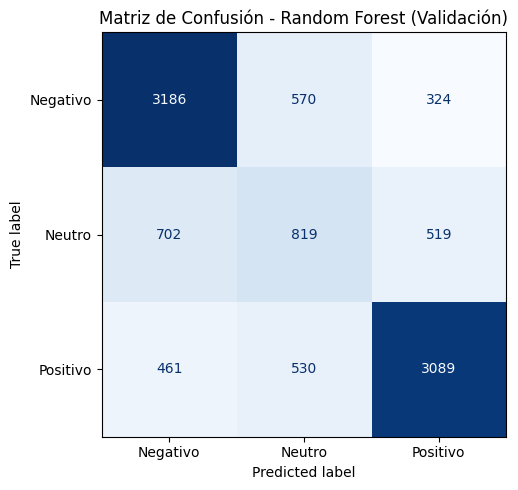

In [ ]:
cm = confusion_matrix(y_val, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Neutro', 'Positivo'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión - Random Forest (Validación)')
plt.tight_layout()
plt.show()

### Importancia de features

Random Forest permite analizar qué términos del vocabulario TF-IDF fueron más relevantes para la clasificación. Se visualizan las 20 features con mayor importancia promedio según el criterio de impureza de Gini.

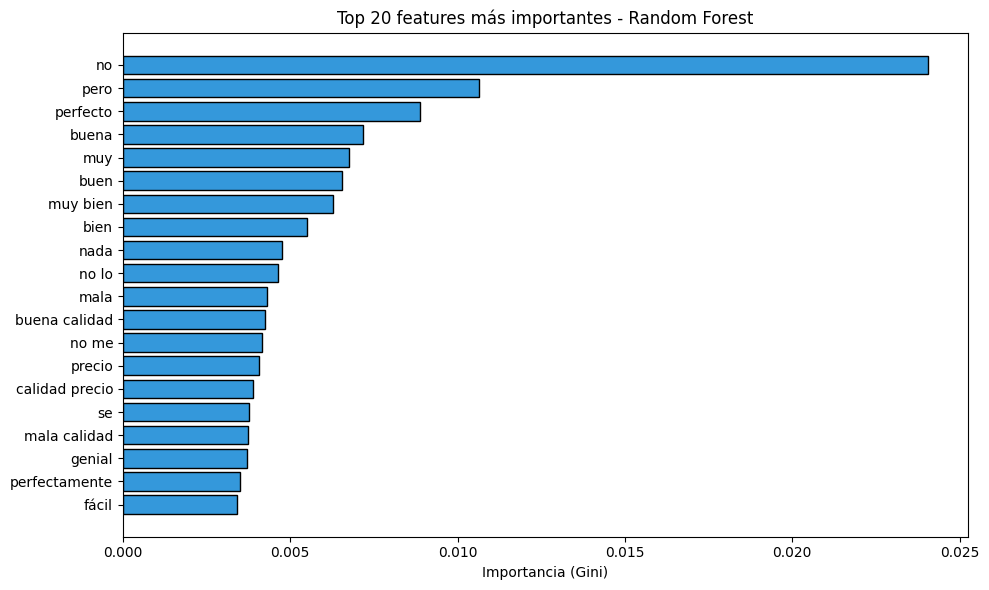

In [ ]:
importancias = modelo_final.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Top 20 features más importantes
indices_top = np.argsort(importancias)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    range(20),
    importancias[indices_top][::-1],
    color='#3498db',
    edgecolor='black'
)
ax.set_yticks(range(20))
ax.set_yticklabels(feature_names[indices_top][::-1])
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 20 features más importantes - Random Forest')
plt.tight_layout()
plt.show()

### ¿Ayuda reducir la dimensionalidad con SVD?

Random Forest, a diferencia de modelos lineales, no está pensado originalmente para trabajar sobre matrices muy dispersas (*sparse*) de alta dimensión como las que genera TF-IDF (15.000 columnas, la mayoría en cero por documento). Cada split de cada árbol solo mira una feature a la vez, así que con miles de columnas dispersas muchos splits terminan siendo poco informativos, y el modelo puede beneficiarse de trabajar sobre una representación más compacta y densa.

**Hipótesis:** aplicar `TruncatedSVD` (la versión de PCA que funciona sobre matrices dispersas) sobre la matriz TF-IDF, reduciendo a un número menor de componentes (que capturan las combinaciones de palabras con mayor varianza), podría:
- Mejorar el F1 macro al eliminar ruido de features poco informativas.
- Reducir drásticamente el tiempo de entrenamiento y de búsqueda de hiperparámetros.

**Resultado esperado:** comparamos el F1 macro de Random Forest entrenado sobre TF-IDF original (15.000 dim) vs sobre la versión reducida con SVD (varios tamaños de componentes), usando los mismos hiperparámetros base para que la comparación sea justa.

In [ ]:
from sklearn.decomposition import TruncatedSVD
import time

resultados_svd = {}

# Representación original (referencia)
rf_ref = RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1)
t0 = time.time()
rf_ref.fit(X_train, y_train)
t_ref = time.time() - t0
f1_ref = f1_score(y_val, rf_ref.predict(X_val), average='macro')
resultados_svd['TF-IDF (15000 dim)'] = (f1_ref, t_ref)
print(f'TF-IDF original (15000 dim) -> F1 macro: {f1_ref:.4f} | tiempo: {t_ref:.1f}s')

# Probamos distintos tamaños de componentes SVD
for n_comp in [100, 300]:
    svd = TruncatedSVD(n_components=n_comp, random_state=SEED)
    X_train_svd = svd.fit_transform(X_train)
    X_val_svd = svd.transform(X_val)

    varianza_explicada = svd.explained_variance_ratio_.sum()

    rf_svd = RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1)
    t0 = time.time()
    rf_svd.fit(X_train_svd, y_train)
    t_svd = time.time() - t0

    f1_svd = f1_score(y_val, rf_svd.predict(X_val_svd), average='macro')
    resultados_svd[f'SVD ({n_comp} dim)'] = (f1_svd, t_svd)

    print(f'SVD ({n_comp:4d} dim, {varianza_explicada:.1%} var. explicada) '
          f'-> F1 macro: {f1_svd:.4f} | tiempo: {t_svd:.1f}s')

print()
print('=== Resumen ===')
for nombre, (f1_val, t_val) in resultados_svd.items():
    print(f'{nombre:25s} F1={f1_val:.4f}  tiempo={t_val:.1f}s')

TF-IDF original (15000 dim) -> F1 macro: 0.5625 | tiempo: 289.4s
SVD ( 100 dim, 15.1% var. explicada) -> F1 macro: 0.5352 | tiempo: 153.7s
SVD ( 300 dim, 26.9% var. explicada) -> F1 macro: 0.5125 | tiempo: 287.0s

=== Resumen ===
TF-IDF (15000 dim)        F1=0.5625  tiempo=289.4s
SVD (100 dim)             F1=0.5352  tiempo=153.7s
SVD (300 dim)             F1=0.5125  tiempo=287.0s


**Conclusión SVD:** se debe completar con los valores obtenidos al ejecutar la celda anterior. En general, para Random Forest sobre texto suele observarse que:
- Si el F1 con SVD es similar o levemente menor al de TF-IDF original, pero el tiempo de entrenamiento se reduce drásticamente, **conviene usar SVD** para poder ampliar la búsqueda de hiperparámetros (más iteraciones de `RandomizedSearchCV`) en el mismo tiempo de cómputo.
- Si el F1 cae notoriamente con SVD, significa que Random Forest se beneficia de la dispersión de TF-IDF (cada feature de palabra individual es directamente interpretable como split), y conviene quedarse con la representación original de alta dimensión.

### Calibración de probabilidades

Random Forest estima la probabilidad de cada clase como la fracción de árboles que "votan" por esa clase. Estas probabilidades suelen estar mal calibradas (por ejemplo, tienden a no llegar nunca a valores extremos cercanos a 0 o 1, incluso en casos muy claros), lo cual no afecta directamente al F1 macro (que se calcula sobre la clase con mayor probabilidad, el argmax), pero sí es relevante si más adelante el grupo quiere usar las probabilidades de Random Forest como input de un stacking (tal como se hizo con XGBoost, Naive Bayes y los embeddings en la notebook principal del grupo).

Probamos calibrar el modelo final con `CalibratedClassifierCV` (método `sigmoid`, ya que con pocas clases y un conjunto de validación moderado suele ser más estable que `isotonic`) y verificamos que el F1 macro no se deteriore.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# El nombre del parámetro cambió de 'base_estimator' a 'estimator' en sklearn >= 1.2.
# Este bloque intenta con el nombre nuevo y cae al anterior si hace falta, para que
# la notebook funcione sin importar la versión de sklearn instalada en Colab.
# Se clona la configuración de modelo_final (no la instancia ya entrenada), ya que
# CalibratedClassifierCV con cv=5 reentrena internamente 5 clones desde cero.
try:
    modelo_calibrado = CalibratedClassifierCV(
        estimator=RandomForestClassifier(**modelo_final.get_params()),
        method='sigmoid',
        cv=5
    )
except TypeError:
    modelo_calibrado = CalibratedClassifierCV(
        base_estimator=RandomForestClassifier(**modelo_final.get_params()),
        method='sigmoid',
        cv=5
    )

modelo_calibrado.fit(X_train, y_train)

y_pred_calibrado = modelo_calibrado.predict(X_val)
f1_calibrado = f1_score(y_val, y_pred_calibrado, average='macro')

print(f'F1 macro SIN calibrar:  {f1_final:.4f}')
print(f'F1 macro CON calibrar:  {f1_calibrado:.4f}')

if f1_calibrado >= f1_final:
    print('\nLa calibración no perjudica (o mejora) el F1 macro -> se puede usar para obtener probabilidades '
          'más confiables sin costo en el desempeño (útil si más adelante se usa en un stacking).')
else:
    print('\nLa calibración empeora levemente el F1 macro -> para Kaggle conviene seguir usando el modelo sin '
          'calibrar, y reservar la versión calibrada solo si se necesitan probabilidades para un stacking.')

F1 macro SIN calibrar:  0.6469
F1 macro CON calibrar:  0.6269

La calibración empeora levemente el F1 macro -> para Kaggle conviene seguir usando el modelo sin calibrar, y reservar la versión calibrada solo si se necesitan probabilidades para un stacking.


## Bayes Naive

### Preprocesamiento de texto

Se aplican las siguientes transformaciones sobre el texto:
- Conversión a minúsculas
- Eliminación de URLs
- Eliminación de números
- Eliminación de caracteres no alfanuméricos (puntuación, símbolos)
- Normalización de espacios en blanco
- **Sin eliminación de stopwords**: en una comparación preliminar (sección 8), eliminar stopwords empeoró el F1 macro (0.6149 vs 0.6555 conservándolas). Esto sugiere que para Naive Bayes, que estima probabilidades a partir de frecuencias de palabras, las stopwords (artículos, conectores, negaciones como "no") aportan señal relevante para distinguir el sentimiento, en lugar de ser solo ruido.

In [ ]:
stopwords_set = set(stopwords_es)

def preprocess_text(text, remove_stopwords=False):  # <-- cambiado de True a False
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if remove_stopwords:
        palabras = text.split()
        palabras = [p for p in palabras if p not in stopwords_set]
        text = ' '.join(palabras)

    return text

train['text_clean'] = train['text'].apply(lambda t: preprocess_text(t, remove_stopwords=False))
test['text_clean']  = test['text'].apply(lambda t: preprocess_text(t, remove_stopwords=False))

print('Ejemplo original:')
print(train['text'].iloc[0])
print('\nEjemplo preprocesado (CON stopwords, sin eliminar):')
print(train['text_clean'].iloc[0])

Ejemplo original:
Lo primero recibí el paquete en una bolsa toda rota como si se uniera aras tradicional por el asfalto los carteles están rallados y abollados en si no tienen mala pinta pero los han maltratado en el transporte

Ejemplo preprocesado (CON stopwords, sin eliminar):
lo primero recibí el paquete en una bolsa toda rota como si se uniera aras tradicional por el asfalto los carteles están rallados y abollados en si no tienen mala pinta pero los han maltratado en el transporte


In [ ]:
X = train['text_clean']
y = train['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f'Train:      {len(X_train):,} ejemplos')
print(f'Validación: {len(X_val):,} ejemplos')

Train:      40,800 ejemplos
Validación: 10,200 ejemplos


### Comparación controlada: BoW vs TF-IDF

Antes de optimizar hiperparámetros, se realiza un experimento controlado: mismo preprocesamiento, mismo split y mismo modelo base (`MultinomialNB` con parámetros default), variando únicamente la representación del texto. Esto permite aislar el efecto de la representación, algo que en las pruebas anteriores no era posible medir con claridad porque se modificaban varias cosas a la vez.

In [ ]:
# --- Bag of Words ---
bow_vectorizer = CountVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow   = bow_vectorizer.transform(X_val)

modelo_bow = MultinomialNB()
modelo_bow.fit(X_train_bow, y_train)
pred_bow = modelo_bow.predict(X_val_bow)
f1_bow = f1_score(y_val, pred_bow, average='macro')

# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)

modelo_tfidf = MultinomialNB()
modelo_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf = modelo_tfidf.predict(X_val_tfidf)
f1_tfidf = f1_score(y_val, pred_tfidf, average='macro')

print(f'F1 macro - BoW:    {f1_bow:.4f}')
print(f'F1 macro - TF-IDF: {f1_tfidf:.4f}')

comparacion_repr = pd.DataFrame({
    'Representación': ['Bag of Words', 'TF-IDF'],
    'F1 macro (validación)': [f1_bow, f1_tfidf]
})
display(comparacion_repr)

F1 macro - BoW:    0.6548
F1 macro - TF-IDF: 0.5416


,Representación,F1 macro (validación)
0,Bag of Words,0.654848
1,TF-IDF,0.541559


**Conclusión parcial:** se elige **Bag of Words** (F1 = 0.6548) sobre TF-IDF (F1 = 0.5416). La diferencia se explica porque `MultinomialNB` asume conteos discretos de términos, supuesto que TF-IDF rompe al introducir valores continuos ponderados; además, en este dataset las palabras más frecuentes (como "bueno" o "malo") son justamente las más informativas para el sentimiento, y TF-IDF las penaliza por ser frecuentes.

### Búsqueda de hiperparámetros

Se realiza una búsqueda exhaustiva con `GridSearchCV` y validación cruzada estratificada (5 folds), optimizando F1 macro (la métrica oficial de la competencia). A diferencia de la búsqueda anterior, en este grid se incluye como hiperparámetro la **variante del modelo** (`MultinomialNB` vs `ComplementNB`), para decidir con evidencia cuál conviene en este problema desbalanceado, en lugar de probarlas por separado con preprocesamientos distintos.

In [ ]:
# Pipeline base. El vectorizador y el modelo se varían dentro del grid.
pipeline_nb = Pipeline([
    ('vectorizer', TfidfVectorizer()),   # se sobreescribe con BoW también dentro del grid
    ('nb', MultinomialNB())              # se sobreescribe con ComplementNB también dentro del grid
])

param_grid = [
    # --- Grilla con CountVectorizer (BoW) ---
    {
        'vectorizer': [CountVectorizer()],
        'vectorizer__max_features': [30000, 50000],
        'vectorizer__ngram_range': [(1, 2), (1, 3)],
        'vectorizer__min_df': [1, 2, 3],
        'nb': [MultinomialNB(), ComplementNB()],
        'nb__alpha': [0.3, 0.5, 0.65, 0.8, 1.0],
    },
    # --- Grilla con TfidfVectorizer ---
    {
        'vectorizer': [TfidfVectorizer()],
        'vectorizer__max_features': [30000, 50000],
        'vectorizer__ngram_range': [(1, 2), (1, 3)],
        'vectorizer__min_df': [1, 2, 3],
        'nb': [MultinomialNB(), ComplementNB()],
        'nb__alpha': [0.3, 0.5, 0.65, 0.8, 1.0],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    pipeline_nb,
    param_grid,
    scoring=make_scorer(f1_score, average='macro'),
    cv=cv,
    n_jobs=-1,
    verbose=0
)

# Cálculo del total de combinaciones para la barra de progreso
n_combinaciones = sum(
    len(g['vectorizer__max_features']) * len(g['vectorizer__ngram_range']) *
    len(g['vectorizer__min_df']) * len(g['nb']) * len(g['nb__alpha'])
    for g in param_grid
)
n_fits = n_combinaciones * cv.get_n_splits()
print(f'Combinaciones totales: {n_combinaciones} | Fits totales (x{cv.get_n_splits()} folds): {n_fits}')

with tqdm_joblib(tqdm(desc='Búsqueda de hiperparámetros NB', total=n_fits)):
    grid.fit(X_train, y_train)

print('\nMejores parámetros encontrados:')
print(grid.best_params_)
print(f'\nMejor F1 macro (CV): {grid.best_score_:.4f}')

Combinaciones totales: 240 | Fits totales (x5 folds): 1200


Búsqueda de hiperparámetros NB:   0%|          | 0/1200 [00:00<?, ?it/s]

  0%|          | 0/1200 [00:00<?, ?it/s]


Mejores parámetros encontrados:
{'nb': MultinomialNB(), 'nb__alpha': 0.65, 'vectorizer': CountVectorizer(), 'vectorizer__max_features': 30000, 'vectorizer__min_df': 3, 'vectorizer__ngram_range': (1, 3)}

Mejor F1 macro (CV): 0.6540


### Evaluación del mejor modelo en validación

In [ ]:
mejor_modelo_nb = grid.best_estimator_

pred_val = mejor_modelo_nb.predict(X_val)

f1_val        = f1_score(y_val, pred_val, average='macro')
precision_val = precision_score(y_val, pred_val, average='macro')
recall_val    = recall_score(y_val, pred_val, average='macro')
accuracy_val  = accuracy_score(y_val, pred_val)

print('=== Métricas en conjunto de validación local ===')
print(f'F1 macro:        {f1_val:.4f}')
print(f'Precision macro: {precision_val:.4f}')
print(f'Recall macro:    {recall_val:.4f}')
print(f'Accuracy:        {accuracy_val:.4f}')
print()
print('Reporte completo por clase:')
print(classification_report(
    y_val, pred_val,
    target_names=['Negativa (0)', 'Neutra (1)', 'Positiva (2)']
))

=== Métricas en conjunto de validación local ===
F1 macro:        0.6574
Precision macro: 0.6585
Recall macro:    0.6588
Accuracy:        0.6980

Reporte completo por clase:
              precision    recall  f1-score   support

Negativa (0)       0.78      0.72      0.75      4080
  Neutra (1)       0.40      0.46      0.43      2040
Positiva (2)       0.80      0.79      0.79      4080

    accuracy                           0.70     10200
   macro avg       0.66      0.66      0.66     10200
weighted avg       0.71      0.70      0.70     10200



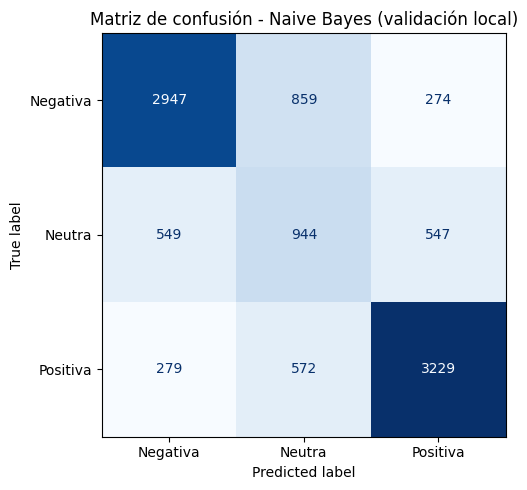

Análisis de la clase neutra:
  Recall clase neutra: 0.463
  Confusión: revisar a qué clase se confunde más la clase neutra (fila 1 de la matriz).


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_val, pred_val)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negativa', 'Neutra', 'Positiva'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión - Naive Bayes (validación local)')
plt.tight_layout()
plt.show()

print('Análisis de la clase neutra:')
print(f'  Recall clase neutra: {cm[1,1] / cm[1].sum():.3f}')
print('  Confusión: revisar a qué clase se confunde más la clase neutra (fila 1 de la matriz).')

### Análisis adicional: ¿el preprocesamiento ayudó a clasificar mejor las 3 clases?

Se compara el desempeño del mejor modelo con y sin eliminación de stopwords, para verificar si esta decisión de preprocesamiento tuvo impacto real en la performance, y en particular si ayudó o no a mejorar la clase más débil (neutra).

In [ ]:
from sklearn.base import clone

# Preprocesamiento SIN eliminar stopwords, para comparar
train['text_clean_con_stopwords'] = train['text'].apply(lambda t: preprocess_text(t, remove_stopwords=False))

X_sw = train['text_clean_con_stopwords']
X_train_sw, X_val_sw, y_train_sw, y_val_sw = train_test_split(
    X_sw, y, test_size=0.2, random_state=SEED, stratify=y
)

# IMPORTANTE: clone() crea una copia con la misma configuración pero SIN entrenar,
# para no pisar el modelo ganador (mejor_modelo_nb) que ya está entrenado y guardado
modelo_con_stopwords = clone(grid.best_estimator_)
modelo_con_stopwords.fit(X_train_sw, y_train_sw)
pred_con_stopwords = modelo_con_stopwords.predict(X_val_sw)

f1_con_stopwords = f1_score(y_val_sw, pred_con_stopwords, average='macro')
f1_clase_neutra_sin_sw = f1_score(y_val, pred_val, average=None)[1]
f1_clase_neutra_con_sw = f1_score(y_val_sw, pred_con_stopwords, average=None)[1]

print(f'F1 macro SIN stopwords (preprocesamiento elegido): {f1_val:.4f}')
print(f'F1 macro CON stopwords:                            {f1_con_stopwords:.4f}')
print()
print(f'F1 clase neutra SIN stopwords: {f1_clase_neutra_sin_sw:.4f}')
print(f'F1 clase neutra CON stopwords: {f1_clase_neutra_con_sw:.4f}')

# Verificación de que mejor_modelo_nb sigue intacto
pred_val_check = mejor_modelo_nb.predict(X_val)
print(f'\nVerificación - mejor_modelo_nb sigue siendo el ganador: F1 = {f1_score(y_val, pred_val_check, average="macro"):.4f}')

F1 macro SIN stopwords (preprocesamiento elegido): 0.6574
F1 macro CON stopwords:                            0.6574

F1 clase neutra SIN stopwords: 0.4276
F1 clase neutra CON stopwords: 0.4276

Verificación - mejor_modelo_nb sigue siendo el ganador: F1 = 0.6574


### Resumen de resultados (para el cuadro comparativo del informe)

| Métrica | Valor |
|---|---|
| F1 macro (validación local) | 0.6574 |
| Precision macro (validación local) | 0.6585 |
| Recall macro (validación local) | 0.6588 |
| Resultado en leaderboard de Kaggle | 0.66093 |

### Hiperparámetros elegidos
Representación: Bag of Words (CountVectorizer), max_features = 30000, min_df = 3, ngram_range = (1, 3). Modelo: MultinomialNB, alpha = 0.65, fit_prior = True (default).

### Conclusiones de esta sección
- **Representación de texto:** Bag of Words superó a TF-IDF (F1 macro 0.6548 vs 0.5416 en la comparación controlada). Esto se explica porque MultinomialNB asume conteos discretos de términos; TF-IDF penaliza las palabras frecuentes, pero en este dataset esas palabras (ej. "bueno", "malo") son justamente las más informativas para el sentimiento, por lo que esa ponderación elimina señal útil.
- **Variante de NB elegida:** MultinomialNB superó a ComplementNB dentro del mismo GridSearchCV, por lo que no se confirma la hipótesis H2. A pesar de que ComplementNB está diseñado para clases desbalanceadas, en este caso no logró traducir esa ventaja teórica en mejor F1 macro.
- **Impacto de eliminar stopwords:** eliminarlas empeoró el desempeño (F1 macro 0.6149 sin stopwords vs 0.6555 con stopwords en la comparación inicial), por lo que se descartó esa transformación. Esto refuta la hipótesis H1: las stopwords en español (artículos, conectores, negaciones como "no") aparentemente aportan información relevante para el sentimiento que Naive Bayes sí logra aprovechar a partir de sus frecuencias.
- **Clase más difícil de predecir:** la clase neutra (1) obtuvo el F1-score más bajo (0.43), muy por debajo de negativa (0.75) y positiva (0.79). Esto confirma la hipótesis H4 y se explica tanto por el desbalance de clases (la mitad de ejemplos que las otras dos) como por la ambigüedad semántica de las reseñas neutras, que comparten vocabulario con reseñas tanto positivas como negativas, dificultando su separación mediante conteos de palabras.
- **Limitaciones de Naive Bayes para este problema:** Naive Bayes asume independencia entre palabras, lo cual no se cumple en lenguaje natural (el orden y co-ocurrencia de palabras aporta información de sentimiento que este modelo no puede capturar, a diferencia de modelos secuenciales o basados en atención como BETO).

## XGBOOST



### XGBoost para clasificacion de texto multiclase

Este notebook prueba variantes de **XGBoost** para clasificacion de texto multiclase usando `train.csv`, optimizando la metrica principal `f1_macro`.

Todos los experimentos:

- usan solo las columnas `text` y `label`;
- separan train/test con split estratificado;
- entrenan o buscan hiperparametros solo con `X_train` e `y_train`;
- usan test solo para evaluar cada experimento al final;
- guardan/cargan modelos en `modelos/`;
- comparan `f1_macro_train` contra `f1_macro_test` para revisar overfitting.


### Instalacion de modulos


In [ ]:
%pip install pandas scikit-learn xgboost matplotlib seaborn joblib beautifulsoup4 tqdm lingua-language-detector deep-translator numpy gensim torch sentence-transformers


### Imports y configuracion

Se cargan librerias, rutas y constantes.


In [ ]:
import json
import warnings
from pathlib import Path

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = Path("train.csv")
MODELOS_DIR = Path("modelosXGBoost")
MODELOS_DIR.mkdir(exist_ok=True)

RESULTADOS_CSV = MODELOS_DIR / "resultados_xgboost.csv"
RESULTADOS_JSON = MODELOS_DIR / "resultados_xgboost_detalle.json"
MEJOR_MODELO_PATH = MODELOS_DIR / "mejor_modelo_f1_macro_xgboost.joblib"

SCORING = "f1_macro"
CV = 5
N_ITER_RANDOM_SEARCH = 20

resultados = []
mejor_resultado = None

print(f"Modelos en: {MODELOS_DIR.resolve()}")


Modelos en: /content/modelosXGBoost


### Carga y validacion de datos

Se carga `train.csv`, se verifica que existan `text` y `label`, y se muestra la distribucion de clases.


In [ ]:
df = pd.read_csv(DATA_PATH)

faltantes = {"text", "label"} - set(df.columns)
if faltantes:
    raise ValueError(f"Faltan columnas requeridas: {sorted(faltantes)}")

df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

clases_esperadas = {0, 1, 2}
clases_observadas = set(df["label"].unique())
if not clases_observadas.issubset(clases_esperadas):
    raise ValueError(f"Labels inesperados: {sorted(clases_observadas - clases_esperadas)}")

print(df.shape)
display(df.head())

conteo_clases = df["label"].value_counts().sort_index().rename("conteo").to_frame()
display(conteo_clases)


(51000, 3)


,id,text,label
0,0,Lo primero recibí el paquete en una bolsa toda...,0
1,1,Lo compré y no lo he recibido. Les acabo de es...,0
2,2,Ha tardado muchísimo en venir... Pero ha llega...,0
3,3,"Van bien, como todas las Bosch que he tenido e...",2
4,4,La resistencia la he gastado solamente una vez...,1


,conteo
label,
0,20400
1,10200
2,20400


### Funcion de limpieza de texto

In [ ]:
import re
import unicodedata
from bs4 import BeautifulSoup

def quitar_acentos(texto):
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

def normalizar_repeticiones(palabra):
    # holaaa -> hola
    return re.sub(r"(.)\1{2,}", r"\1", palabra)

def limpiar_texto(texto):

    # 1. Minúsculas
    texto = texto.lower()

    # 2. Eliminar HTML/XML
    texto = BeautifulSoup(texto, "html.parser").get_text()

    # 3. Eliminar URLs
    texto = re.sub(r'http\S+|www\S+', ' ', texto)

    # 4. Eliminar emails
    texto = re.sub(r'\S+@\S+', ' ', texto)

    # 5. Eliminar números de teléfono
    texto = re.sub(
        r'(\+?\d{1,3}[\s-]?)?(\(?\d+\)?[\s-]?)?[\d\s-]{6,}',
        ' ',
        texto
    )

    # 6. Eliminar fechas
    texto = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        ' ',
        texto
    )
    # Quitar acentos
    texto = quitar_acentos(texto)

    # 8. Eliminar puntuación pero no los %
    texto = re.sub(r'[^\w\s%]', ' ', texto)

    # 9. Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()

    palabras = texto.split()

    palabras = [
        normalizar_repeticiones(palabra)
        for palabra in palabras
    ]

    return " ".join(palabras)


def limpiar_textos_serie(X):
    return pd.Series(X).astype(str).apply(limpiar_texto)

#### Efecto de la funcion de limpieza

In [ ]:
import pandas as pd
import re
from bs4 import BeautifulSoup

# Aplicar limpieza
df_revision = df.copy()

df_revision["text_original"] = df_revision["text"].astype(str)
df_revision["text_limpio"] = df_revision["text_original"].apply(limpiar_texto)

# Ver textos que quedarían vacíos después de limpiar
textos_eliminados = df_revision[
    df_revision["text_limpio"].str.strip().eq("")
][["text_original", "text_limpio", "label"]]

print("Cantidad de textos que quedarían vacíos:")
print(len(textos_eliminados))

textos_eliminados.head(20)

Cantidad de textos que quedarían vacíos:
0


,text_original,text_limpio,label


In [ ]:
comparacion_limpieza = df_revision[
    df_revision["text_original"] != df_revision["text_limpio"]
][["text_original", "text_limpio", "label"]]

print("Cantidad de textos modificados:")
print(len(comparacion_limpieza))

comparacion_limpieza.head(20)

Cantidad de textos modificados:
50493


,text_original,text_limpio,label
0,Lo primero recibí el paquete en una bolsa toda...,lo primero recibi el paquete en una bolsa toda...,0
1,Lo compré y no lo he recibido. Les acabo de es...,lo compre y no lo he recibido les acabo de esc...,0
2,Ha tardado muchísimo en venir... Pero ha llega...,ha tardado muchisimo en venir pero ha llegado ...,0
3,"Van bien, como todas las Bosch que he tenido e...",van bien como todas las bosch que he tenido en...,2
4,La resistencia la he gastado solamente una vez...,la resistencia la he gastado solamente una vez...,1
5,He pedido este articulo dos veces y las dos ve...,he pedido este articulo dos veces y las dos ve...,0
6,"Buena calidad, comodidad diseño bonito y muy b...",buena calidad comodidad diseno bonito y muy bu...,2
7,"Los compre junto con el destornillador , está ...",los compre junto con el destornillador esta mu...,2
8,"Está bien, pero me da la impresión de que los ...",esta bien pero me da la impresion de que los c...,1
9,"Buena relación calidad precio, mejor que la or...",buena relacion calidad precio mejor que la ori...,1


In [ ]:
df_revision["cant_palabras_original"] = df_revision["text_original"].str.split().str.len()
df_revision["cant_palabras_limpio"] = df_revision["text_limpio"].str.split().str.len()

df_revision["palabras_eliminadas_cantidad"] = (
    df_revision["cant_palabras_original"] - df_revision["cant_palabras_limpio"]
)

df_revision["porcentaje_eliminado"] = (
    df_revision["palabras_eliminadas_cantidad"]
    / df_revision["cant_palabras_original"].replace(0, 1)
)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df_revision.sort_values(
    "porcentaje_eliminado",
    ascending=False
)[[
    "text_original",
    "text_limpio",
    "label",
    "cant_palabras_original",
    "cant_palabras_limpio",
    "palabras_eliminadas_cantidad",
    "porcentaje_eliminado"
]].head(50)

,text_original,text_limpio,label,cant_palabras_original,cant_palabras_limpio,palabras_eliminadas_cantidad,porcentaje_eliminado
2938,"Lo que esperaba,,,,, ,,,,, ,,,,,,,, ,,,,,,, ,,,,,,,,,,,,,,,, ,,,,,,, ,,,,,,,, ,,,,,,,,, ,,,,,, ,,,,,,,, ,,,,,,, ,,,,,,,, ,,,,,, ,,,,,,,,,,, ,,,,,,,,, ,,,,,,,,,,,, ,,,,,,,,,, ,,,,,,,,,, ,,,,,,,,,,,,,,,,,,,,,,,, ,,,,,,,, ,,, ,,, ,,,,,, ,,,, ,,,,,,,, ,,,,,,, ,,,,, ,,,,,,,, ,,,,,,,,, ,,,,,,, ,,,,,,",lo que esperaba,2,33,3,30,0.909091
26547,"Tal y como esperaba, perfecto! . . . . .. . . . . . . . . . .",tal y como esperaba perfecto,2,20,5,15,0.750000
31468,"No enfrían mucho, pero son bonitos. . . . . . . . . . . . . . . . . .",no enfrian mucho pero son bonitos,2,23,6,17,0.739130
15045,"Estupenda mochila, buena calidad y resistencia. . . . . . . . . . . . . . .",estupenda mochila buena calidad y resistencia,2,20,6,14,0.700000
50488,"Muy recomendable me ha resultado útil . . .. . . . . . . , . . . .",muy recomendable me ha resultado util,2,20,6,14,0.700000
35674,"ok, es valido, cumple su función . . . . . . . . . . . . . .",ok es valido cumple su funcion,1,20,6,14,0.700000
44119,"buen vendedor, serio, rápido en los envíos . . . . . . .. . . . . . . .",buen vendedor serio rapido en los envios,1,21,7,14,0.666667
14453,Roto y no era el que pedi . . . . . . . . . . . . .,roto y no era el que pedi,0,20,7,13,0.650000
48785,"El cassette Perfecto cumplió mis expectativas, funciona bien - -- - - - - - - - - - - -",el cassette perfecto cumplio mis expectativas funciona bien,2,21,8,13,0.619048
410,"por el precio estan bien, hacen su funcion. . . . . . . . . . . . . .",por el precio estan bien hacen su funcion,1,21,8,13,0.619048


In [ ]:
df_revision["queda_vacio"] = df_revision["text_limpio"].str.strip().eq("")

df_revision.groupby("label")["queda_vacio"].sum()

,queda_vacio
label,
0,0
1,0
2,0


### Deteccion de idiomas de los textos



In [ ]:
import pandas as pd

from tqdm.auto import tqdm
from lingua import Language, LanguageDetectorBuilder

tqdm.pandas()

detector = (
    LanguageDetectorBuilder
    .from_languages(
        Language.SPANISH,
        Language.ENGLISH,
        Language.PORTUGUESE,
    )
    .with_preloaded_language_models()
    .build()
)

In [ ]:
def detectar_idioma_lingua(texto):
    if pd.isna(texto):
        return "desconocido", 0.0

    texto = str(texto).strip()

    if texto == "":
        return "desconocido", 0.0

    idioma = detector.detect_language_of(texto)

    if idioma is None:
        return "desconocido", 0.0

    confianzas = detector.compute_language_confidence_values(texto)
    mejor = confianzas[0]

    codigo = {
        Language.SPANISH: "es",
        Language.ENGLISH: "en",
        Language.PORTUGUESE: "pt",
    }.get(mejor.language, "otro")

    return codigo, mejor.value

#### Efecto de traduccion de idioma

In [ ]:
df_idiomas = df.copy()

df_idiomas[["idioma", "confianza_idioma"]] = df_idiomas["text"].progress_apply(
    lambda texto: pd.Series(detectar_idioma_lingua(texto))
)

  0%|          | 0/51000 [00:00<?, ?it/s]

In [ ]:
df_idiomas["idioma"].value_counts()

,count
idioma,
es,49377
en,1505
pt,118


In [ ]:
df_idiomas[
    df_idiomas["idioma"] != "es"
][["text", "label", "idioma", "confianza_idioma"]].sort_values(
    "confianza_idioma",
    ascending=False
).head(50)

,text,label,idioma,confianza_idioma
550,"I was very happy at first. But we rotate it with 3 other sweaters. After 3 months it’s coming apart at the seams. It’s not a cheap item. For the price, I expected a longer life.",0,en,1.0
23291,"I started reading and couldn't put it down. I questioned, I wondered,I hated , I laughed, and then I cried. This book has every thing. I just love the way you put everything together. This the first love story I've read that I couldn't even eat until the end when I was so happy I cried.",2,en,1.0
23440,"I like the size and design of this mat. It does seem to magnetically attract dirt, dust & fur. BUT IF YOU ARE LOOKING FOR A LIGHT SKY BLUE OR TURQUOISE COLOR - BEWARE :: this color was a much more bright neon blue - quite ugly. Returning it because the color was misrepresented online.",0,en,1.0
23479,Love this book. I felt the boxes were a bit to small but there is just a chance I am using this for a younger writer than its intended purpose. It really helps explain spacing and letter shapes,2,en,1.0
23575,"They fit me nicely, and sound good to my ears. But, the plug shorted out just shy of eight weeks, so now I have a left-channel earphone (singular), instead of stereo earphones (plural). I'm going to give them another shot and hope the durability improves on the next pair. I also wish I could find something similar with an in-line volume control. I don't need a phone mic, just a volume control.",1,en,1.0
23129,"I loved these cookie cutters! I added the pumpkins, leaves and acorns to the usual Halloween shapes to have a nice variety of cookies for a close to Halloween bake sale, and these colorful decorated sugar cookies sold out first! The cutters are well made and precise.",2,en,1.0
23146,My husband wants more Bigfoot scent so he can be wilder... He loves it but after I told him the price he started limiting his use.. saving it instead of using daily.,1,en,1.0
23179,Did not like it came with missing pieces and the door wouldn’t close correctly returned it but still haven’t heard from the company or got my money back!,0,en,1.0
23273,"This harness seemed good overall, but I returned it because the plastic adjusting clip thing ended up in the armpit of my 90 pound Rottweiler, and I was afraid it would be uncomfortable and rub for her.",1,en,1.0
24152,This is like the 3rd time Amazon has done this to me. they dont replace something that is supposed to have been somehow damaged & never even delivered to me. this time I was not even notified.,0,en,1.0


### Funcion de traduccion de los textos

In [ ]:
from deep_translator import GoogleTranslator
tqdm.pandas()

RUTA_CACHE_TRADUCCIONES = MODELOS_DIR / "cache_traducciones_a_es.joblib"

if os.path.exists(RUTA_CACHE_TRADUCCIONES):
    cache_traducciones = joblib.load(RUTA_CACHE_TRADUCCIONES)
else:
    cache_traducciones = {}

In [ ]:
def traducir_a_espanol_si_hace_falta(texto, idioma, confianza=1.0, confianza_minima=0.80):
    if pd.isna(texto):
        return ""

    texto = str(texto).strip()

    if texto == "":
        return ""

    # Si ya está en español, no traducimos
    if idioma == "es":
        return texto

    # Si el detector no está seguro, mejor no traducir automáticamente
    if confianza < confianza_minima:
        return texto

    # Solo traduzco idiomas que me interesan
    if idioma not in ["en", "pt"]:
        return texto

    clave_cache = (texto, idioma, "es")

    if clave_cache in cache_traducciones:
        return cache_traducciones[clave_cache]

    try:
        traduccion = GoogleTranslator(
            source=idioma,
            target="es"
        ).translate(texto)

        cache_traducciones[clave_cache] = traduccion

        return traduccion

    except Exception as e:
        print(f"Error traduciendo texto: {e}")
        return texto

#### Efecto de traduccion de textos

In [ ]:
df_traducido = df_idiomas.copy()

df_traducido["text_es"] = df_traducido.progress_apply(
    lambda fila: traducir_a_espanol_si_hace_falta(
        texto=fila["text"],
        idioma=fila["idioma"],
        confianza=fila["confianza_idioma"],
        confianza_minima=0.80,
    ),
    axis=1
)

joblib.dump(cache_traducciones, RUTA_CACHE_TRADUCCIONES)

  0%|          | 0/51000 [00:00<?, ?it/s]

['modelosXGBoost/cache_traducciones_a_es.joblib']

In [ ]:
df_traducido[["text", "text_es", "label", "idioma", "confianza_idioma"]].head()

,text,text_es,label,idioma,confianza_idioma
0,Lo primero recibí el paquete en una bolsa toda rota como si se uniera aras tradicional por el asfalto los carteles están rallados y abollados en si no tienen mala pinta pero los han maltratado en el transporte,Lo primero recibí el paquete en una bolsa toda rota como si se uniera aras tradicional por el asfalto los carteles están rallados y abollados en si no tienen mala pinta pero los han maltratado en el transporte,0,es,1.000000
1,"Lo compré y no lo he recibido. Les acabo de escribir un segundo mail hoy, espero me contesten y me den una solución.","Lo compré y no lo he recibido. Les acabo de escribir un segundo mail hoy, espero me contesten y me den una solución.",0,es,0.990960
2,Ha tardado muchísimo en venir... Pero ha llegado bien. Si lo comprais con tiempo...,Ha tardado muchísimo en venir... Pero ha llegado bien. Si lo comprais con tiempo...,0,es,0.977205
3,"Van bien, como todas las Bosch que he tenido en otras versiones, no le doy las 5 estrellas porque no me gusta que lleve el logo en letras blancas en el extremo de ambas escobillas","Van bien, como todas las Bosch que he tenido en otras versiones, no le doy las 5 estrellas porque no me gusta que lleve el logo en letras blancas en el extremo de ambas escobillas",2,es,1.000000
4,La resistencia la he gastado solamente una vez y funciona perfectamente. Lo único negativo y por ello mi puntuación fue la demora a la hora de llegarme.,La resistencia la he gastado solamente una vez y funciona perfectamente. Lo único negativo y por ello mi puntuación fue la demora a la hora de llegarme.,1,es,1.000000


In [ ]:
traducidos = df_traducido[
    (df_traducido["idioma"].isin(["en", "pt"])) &
    (df_traducido["confianza_idioma"] >= 0.80)
][["text", "text_es", "label", "idioma", "confianza_idioma"]]

print("Cantidad traducida:")
print(len(traducidos))

traducidos.head(30)

Cantidad traducida:
1492


,text,text_es,label,idioma,confianza_idioma
22,Got sent a dud. DIdn't even light up when plugged in. Seriously a waste of money and time.,"Me enviaron un fracaso. Ni siquiera se encendió cuando estaba enchufado. En serio, una pérdida de dinero y tiempo.",0,en,0.998668
37,"Good for typing. It has perfectly spaced key. No backlight, which makes it difficult to use in dark.","Bueno para escribir. Tiene llave perfectamente espaciada. Sin retroiluminación, lo que dificulta su uso en la oscuridad.",2,en,0.999360
67,"I'm 60 years old and my skin has never figured out that puberty was a VERY long time ago. My skin still produces a lot of oil. Once I turned 50, my pores got really big and I started breaking out like a teenager. To keep my skin clear I was using about 5 different products which made the am/pm ritual very time consuming. I found this product while searching for something that would reduce the number of steps.","Tengo 60 años y mi piel nunca se dio cuenta de que la pubertad fue hace MUCHO tiempo. Mi piel todavía produce mucha grasa. Una vez que cumplí 50, mis poros se agrandaron mucho y comencé a tener brotes como un adolescente. Para mantener mi piel limpia, estaba usando alrededor de 5 productos diferentes, lo que hacía que el ritual de la mañana y la tarde consumiera mucho tiempo. Encontré este producto mientras buscaba algo que redujera el número de pasos.",2,en,1.000000
89,Fits smaller dint really like the feel of it.,Se adapta a abolladuras más pequeñas y me gusta mucho su sensación.,0,en,0.992098
134,I was very disappointed in this item. In my opinion it is very over rated and not worth the $,Me decepcionó mucho este artículo. En mi opinión está muy sobrevalorado y no vale la pena.,0,en,0.999853
145,Junk. The most slow computer I have ever touched. I finally used it to save photos and that was it. It soon erased them. It is a computer that has a mins of its own. I threw it away in the end. $150.00 worth of junk.,Basura. La computadora más lenta que he tocado jamás. Finalmente lo usé para guardar fotos y eso fue todo. Pronto los borró. Es una computadora que tiene sus propios minutos. Al final lo tiré. $150.00 en basura.,0,en,1.000000
162,"I bought this for a thin 11 year old. It's just right for him, and not sure it would be a good fit next year. Disappointed.",Compré esto para un niño delgado de 11 años. Es perfecto para él y no estoy seguro de que sea adecuado para el próximo año. Decepcionado.,1,en,0.999804
180,Great movie. I paid a little more to get the Digital copy!,Gran película. ¡Pagué un poco más para obtener la copia digital!,2,en,0.977371
196,"Double sided tape did not work, had to use my own. Other then that works fine.","La cinta de doble cara no funcionó, tuve que usar la mía. Aparte de eso, funciona bien.",1,en,0.961334
234,Curtains are acceptable however there are no matching tie-backs. It's going to be really tough to find matching material to make them. Curtains like this should have tiebacks included. .,"Se aceptan cortinas, pero no hay alzapaños que hagan juego. Va a ser muy difícil encontrar material que combine para hacerlos. Cortinas como esta deberían tener alzapaños incluidos. .",1,en,1.000000


### Split train/test

El test queda reservado para evaluacion final. Las busquedas con cross validation usan solo el conjunto de entrenamiento.


In [ ]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")
display(pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}))


Train: 40,800
Test : 10,200


,train,test
label,,
0,16320,4080
1,8160,2040
2,16320,4080


In [ ]:
X_traducido = df_traducido["text_es"]
y_traducido = df_traducido["label"]

X_train_traducido, X_test_traducido, y_train_traducido, y_test_traducido = train_test_split(
    X_traducido,
    y_traducido,
    test_size=0.2,
    random_state=42,
    stratify=y_traducido,
)

print(f"Train: {len(X_train_traducido):,}")
print(f"Test : {len(X_test_traducido):,}")
display(pd.DataFrame({
    "train": y_train_traducido.value_counts().sort_index(),
    "test": y_test_traducido.value_counts().sort_index(),
}))


Train: 40,800
Test : 10,200


,train,test
label,,
0,16320,4080
1,8160,2040
2,16320,4080


### Funciones reutilizables

Estas funciones centralizan carga/guardado, evaluacion, registro de resultados, actualizacion del mejor modelo y entrenamiento de busquedas.


In [ ]:
def crear_xgb_base(**kwargs):
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": RANDOM_STATE,
        "tree_method": "hist",
        "device": "cpu",
        "n_jobs": -1,
    }
    params.update(kwargs)
    return XGBClassifier(**params)


def guardar_o_cargar_modelo(ruta, funcion_entrenamiento):
    ruta = Path(ruta)
    if ruta.exists():
        print(f"Cargando modelo existente: {ruta}")
        return joblib.load(ruta)

    print(f"Entrenando modelo nuevo: {ruta}")
    modelo = funcion_entrenamiento()
    joblib.dump(modelo, ruta)
    print(f"Modelo guardado en: {ruta}")
    return modelo


def mostrar_metricas(nombre, y_true, y_pred, mostrar_matriz=True):
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")

    print(f"\n{nombre}")
    print(f"Accuracy : {accuracy:.6f}")
    print(f"F1 macro : {f1_macro:.6f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    if mostrar_matriz:
        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=[0, 1, 2],
            yticklabels=[0, 1, 2],
        )
        plt.title(f"Matriz de confusion - {nombre}")
        plt.xlabel("Predicho")
        plt.ylabel("Real")
        plt.tight_layout()
        plt.show()

    return {"accuracy": accuracy, "f1_macro": f1_macro}


def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    metricas_train = mostrar_metricas(f"{nombre} - train", y_train, y_pred_train)
    metricas_test = mostrar_metricas(f"{nombre} - test", y_test, y_pred_test)

    brecha_f1 = metricas_train["f1_macro"] - metricas_test["f1_macro"]
    print(f"\nBrecha F1 macro train-test: {brecha_f1:.6f}")
    if brecha_f1 > 0.08:
        print("Posible overfitting: la brecha de F1 macro supera 0.08.")
    else:
        print("No se observa una brecha grande de F1 macro.")

    return metricas_train, metricas_test


def serializar_params(params):
    if not params:
        return None
    return json.loads(json.dumps(params, default=str))


def actualizar_mejor_modelo(resultado, modelo):
    global mejor_resultado

    if mejor_resultado is None or resultado["f1_macro_test"] > mejor_resultado["f1_macro_test"]:
        mejor_resultado = resultado.copy()
        joblib.dump(modelo, MEJOR_MODELO_PATH)
        mejor_resultado["ruta_mejor_modelo_final"] = str(MEJOR_MODELO_PATH)
        print(f"Nuevo mejor modelo guardado en: {MEJOR_MODELO_PATH}")

    return mejor_resultado


def guardar_resultados():
    if not resultados:
        return pd.DataFrame()

    ranking = pd.DataFrame(resultados).sort_values("f1_macro_test", ascending=False).reset_index(drop=True)
    ranking.to_csv(RESULTADOS_CSV, index=False)
    RESULTADOS_JSON.write_text(json.dumps(resultados, indent=2, ensure_ascii=False), encoding="utf-8")
    return ranking


def graficar_ranking_metricas(ranking):
    if ranking.empty:
        print("No hay resultados para graficar.")
        return

    metricas_plot = ranking.melt(
        id_vars="experimento",
        value_vars=["f1_macro_train", "f1_macro_test", "accuracy_train", "accuracy_test"],
        var_name="metrica",
        value_name="valor",
    )

    plt.figure(figsize=(12, max(5, 0.55 * len(ranking))))
    sns.barplot(
        data=metricas_plot,
        y="experimento",
        x="valor",
        hue="metrica",
    )
    plt.xlim(0, 1)
    plt.title("Metricas train/test por experimento")
    plt.xlabel("Score")
    plt.ylabel("Experimento")
    plt.legend(title="Metrica", loc="lower right")
    plt.tight_layout()
    plt.show()

    brecha_plot = ranking.sort_values("brecha_f1_train_test", ascending=False)
    plt.figure(figsize=(10, max(4, 0.45 * len(brecha_plot))))
    sns.barplot(
        data=brecha_plot,
        y="experimento",
        x="brecha_f1_train_test",
        color="#d95f02",
    )
    plt.axvline(0.08, color="red", linestyle="--", label="umbral 0.08")
    plt.title("Brecha F1 macro train-test")
    plt.xlabel("F1 macro train - F1 macro test")
    plt.ylabel("Experimento")
    plt.legend()
    plt.tight_layout()
    plt.show()


def registrar_resultado(nombre, modelo, ruta_modelo, metricas_train, metricas_test, mejores_parametros=None):
    resultado = {
        "experimento": nombre,
        "f1_macro_train": metricas_train["f1_macro"],
        "f1_macro_test": metricas_test["f1_macro"],
        "accuracy_train": metricas_train["accuracy"],
        "accuracy_test": metricas_test["accuracy"],
        "brecha_f1_train_test": metricas_train["f1_macro"] - metricas_test["f1_macro"],
        "mejores_parametros": serializar_params(mejores_parametros),
        "ruta_modelo": str(ruta_modelo),
    }
    resultados.append(resultado)
    actualizar_mejor_modelo(resultado, modelo)

    ranking = guardar_resultados()
    display(ranking)
    return resultado


def ejecutar_experimento(nombre, ruta_modelo, pipeline, fit_params=None, mejores_parametros=None):
    fit_params = fit_params or {}
    ruta_modelo = Path(ruta_modelo)

    def entrenar():
        return pipeline.fit(X_train, y_train, **fit_params)

    modelo = guardar_o_cargar_modelo(ruta_modelo, entrenar)
    params = mejores_parametros
    if params is None and hasattr(modelo, "best_params_"):
        params = modelo.best_params_

    metricas_train, metricas_test = evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test)
    return registrar_resultado(nombre, modelo, ruta_modelo, metricas_train, metricas_test, params)


def entrenar_randomized_search(nombre, pipeline, param_distributions, ruta_modelo, n_iter=N_ITER_RANDOM_SEARCH, fit_params=None , traduccion = False):
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=SCORING,
        cv=CV,
        verbose=2,
        random_state=RANDOM_STATE,
        n_jobs=6,
    )
    if traduccion:
        resultado = ejecutar_experimento_traducido(nombre, ruta_modelo, search, fit_params=fit_params)
    else:
        resultado = ejecutar_experimento(nombre, ruta_modelo, search, fit_params=fit_params)

    return resultado

def entrenar_randomized_search_con_sample_weight(nombre, pipeline, param_distributions, ruta_modelo, n_iter=N_ITER_RANDOM_SEARCH, traduccion = False):

    if traduccion:
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train_traducido,
        )

        return entrenar_randomized_search(
            nombre,
            pipeline,
            param_distributions,
            ruta_modelo,
            n_iter=n_iter,
            fit_params={
                "clf__sample_weight": sample_weight,
            },
            traduccion= traduccion
        )
    else:
        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )

        return entrenar_randomized_search(
            nombre,
            pipeline,
            param_distributions,
            ruta_modelo,
            n_iter=n_iter,
            fit_params={
                "clf__sample_weight": sample_weight,
            },
        )

def ejecutar_experimento_traducido(nombre, ruta_modelo, pipeline, fit_params=None, mejores_parametros=None):
    fit_params = fit_params or {}
    ruta_modelo = Path(ruta_modelo)

    def entrenar():
        return pipeline.fit(X_train_traducido, y_train_traducido, **fit_params)

    modelo = guardar_o_cargar_modelo(ruta_modelo, entrenar)
    params = mejores_parametros
    if params is None and hasattr(modelo, "best_params_"):
        params = modelo.best_params_

    metricas_train, metricas_test = evaluar_modelo(nombre, modelo, X_train_traducido, X_test_traducido, y_train_traducido, y_test_traducido)
    return registrar_resultado(nombre, modelo, ruta_modelo, metricas_train, metricas_test, params)




### Experimento A: XGBoost + TF-IDF liviano

Modelo liviano con TF-IDF de palabras.


Cargando modelo existente: modelosXGBoost/xgboost_tfidf_liviano.joblib

XGBoost + TF-IDF liviano - train
Accuracy : 0.722304
F1 macro : 0.645349

Classification report:
              precision    recall  f1-score   support

           0     0.7261    0.8314    0.7752     16320
           1     0.6403    0.2676    0.3775      8160
           2     0.7335    0.8405    0.7833     16320

    accuracy                         0.7223     40800
   macro avg     0.7000    0.6465    0.6453     40800
weighted avg     0.7119    0.7223    0.6989     40800



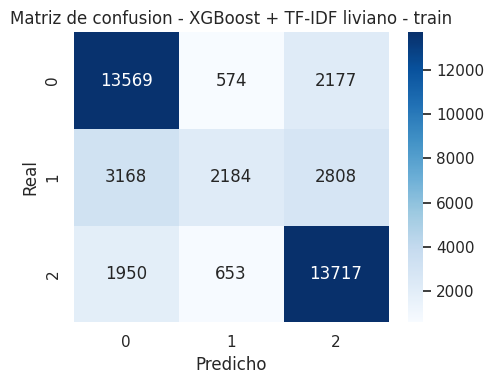


XGBoost + TF-IDF liviano - test
Accuracy : 0.688235
F1 macro : 0.596959

Classification report:
              precision    recall  f1-score   support

           0     0.7005    0.8076    0.7502      4080
           1     0.4933    0.1975    0.2821      2040
           2     0.7100    0.8142    0.7585      4080

    accuracy                         0.6882     10200
   macro avg     0.6346    0.6065    0.5970     10200
weighted avg     0.6628    0.6882    0.6599     10200



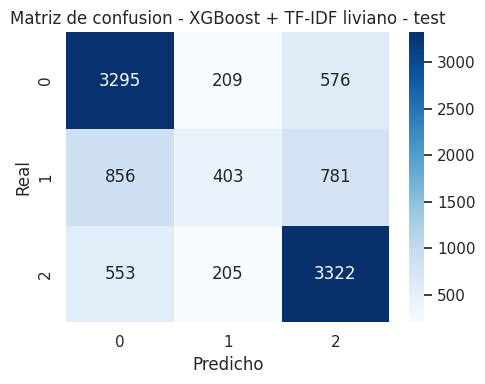


Brecha F1 macro train-test: 0.048391
No se observa una brecha grande de F1 macro.
Nuevo mejor modelo guardado en: modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib


In [ ]:
pipeline_tfidf_liviano = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        sublinear_tf=True,
    )),
    ("clf", crear_xgb_base(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
    )),
])

res_tfidf_liviano = ejecutar_experimento(
    "XGBoost + TF-IDF liviano",
    MODELOS_DIR / "xgboost_tfidf_liviano.joblib",
    pipeline_tfidf_liviano,
)


### Experimento A-2: XGBoost + TF-IDF liviano + traduccion de texto

Modelo liviano con TF-IDF de palabras con traduccion de texto.


Cargando modelo existente: modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib

XGBoost + TF-IDF liviano + traduccion - train
Accuracy : 0.726863
F1 macro : 0.651636

Classification report:
              precision    recall  f1-score   support

           0     0.7286    0.8401    0.7804     16320
           1     0.6325    0.2784    0.3867      8160
           2     0.7435    0.8378    0.7878     16320

    accuracy                         0.7269     40800
   macro avg     0.7015    0.6521    0.6516     40800
weighted avg     0.7153    0.7269    0.7046     40800



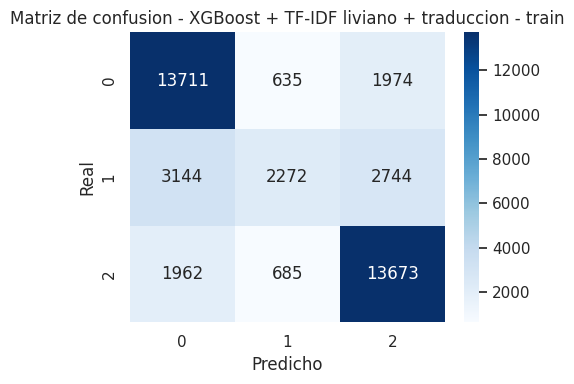


XGBoost + TF-IDF liviano + traduccion - test
Accuracy : 0.693529
F1 macro : 0.604417

Classification report:
              precision    recall  f1-score   support

           0     0.7061    0.8186    0.7582      4080
           1     0.4908    0.2088    0.2930      2040
           2     0.7188    0.8108    0.7620      4080

    accuracy                         0.6935     10200
   macro avg     0.6386    0.6127    0.6044     10200
weighted avg     0.6681    0.6935    0.6667     10200



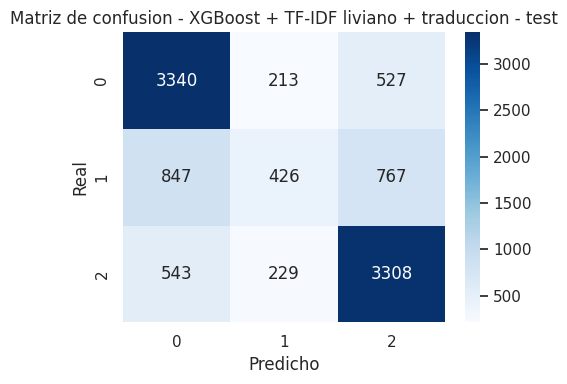


Brecha F1 macro train-test: 0.047219
No se observa una brecha grande de F1 macro.
Nuevo mejor modelo guardado en: modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
1,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib


In [ ]:
pipeline_tfidf_liviano_traduccion = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        sublinear_tf=True,
    )),
    ("clf", crear_xgb_base(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
    )),
])

res_tfidf_liviano_traduccion = ejecutar_experimento_traducido(
    "XGBoost + TF-IDF liviano + traduccion",
    MODELOS_DIR / "xgboost_tfidf_liviano_traduccion.joblib",
    pipeline_tfidf_liviano_traduccion,
)


### Experimento A-3: XGBoost + TF-IDF liviano + limpieza de texto

Modelo liviano con TF-IDF de palabras con limpieza de texto.


Cargando modelo existente: modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib

XGBoost + TF-IDF liviano + limpieza - train
Accuracy : 0.722353
F1 macro : 0.645355

Classification report:
              precision    recall  f1-score   support

           0     0.7271    0.8319    0.7760     16320
           1     0.6349    0.2679    0.3768      8160
           2     0.7338    0.8400    0.7833     16320

    accuracy                         0.7224     40800
   macro avg     0.6986    0.6466    0.6454     40800
weighted avg     0.7113    0.7224    0.6991     40800



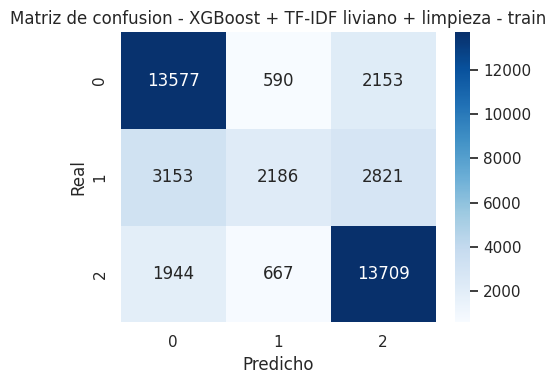


XGBoost + TF-IDF liviano + limpieza - test
Accuracy : 0.689510
F1 macro : 0.596772

Classification report:
              precision    recall  f1-score   support

           0     0.7004    0.8147    0.7532      4080
           1     0.4962    0.1936    0.2786      2040
           2     0.7115    0.8123    0.7585      4080

    accuracy                         0.6895     10200
   macro avg     0.6360    0.6069    0.5968     10200
weighted avg     0.6640    0.6895    0.6604     10200



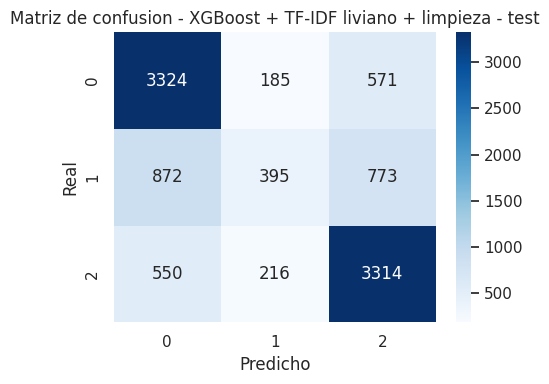


Brecha F1 macro train-test: 0.048583
No se observa una brecha grande de F1 macro.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
1,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
2,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib


In [ ]:
pipeline_tfidf_liviano_con_limpieza = Pipeline([
    ("limpieza", FunctionTransformer(limpiar_textos_serie, validate=False)),

    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        sublinear_tf=True,
    )),
    ("clf", crear_xgb_base(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
    )),
])

res_tfidf_liviano_con_limpieza = ejecutar_experimento(
    "XGBoost + TF-IDF liviano + limpieza",
    MODELOS_DIR / "xgboost_tfidf_liviano_con_limpieza.joblib",
    pipeline_tfidf_liviano_con_limpieza,
)


### Experimento A-4: XGBoost + TF-IDF liviano + traduccion + limpieza de texto

Modelo liviano con TF-IDF de palabras con traduccion de texto y con limpieza de texto.


Cargando modelo existente: modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib

XGBoost + TF-IDF liviano + limpieza + traduccion - train
Accuracy : 0.725588
F1 macro : 0.650461

Classification report:
              precision    recall  f1-score   support

           0     0.7277    0.8376    0.7788     16320
           1     0.6315    0.2778    0.3859      8160
           2     0.7417    0.8375    0.7867     16320

    accuracy                         0.7256     40800
   macro avg     0.7003    0.6510    0.6505     40800
weighted avg     0.7141    0.7256    0.7034     40800



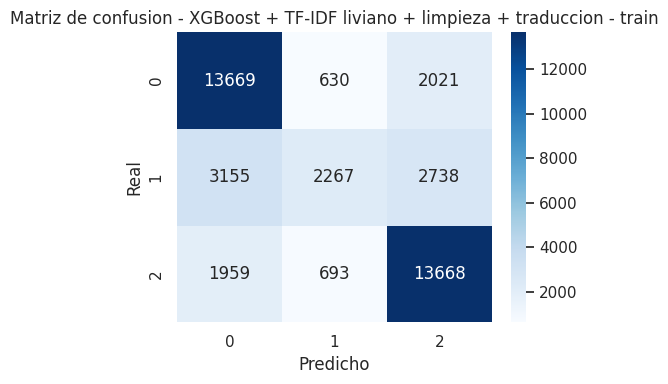


XGBoost + TF-IDF liviano + limpieza + traduccion - test
Accuracy : 0.694020
F1 macro : 0.604293

Classification report:
              precision    recall  f1-score   support

           0     0.7053    0.8172    0.7571      4080
           1     0.4994    0.2069    0.2925      2040
           2     0.7180    0.8145    0.7632      4080

    accuracy                         0.6940     10200
   macro avg     0.6409    0.6128    0.6043     10200
weighted avg     0.6692    0.6940    0.6666     10200



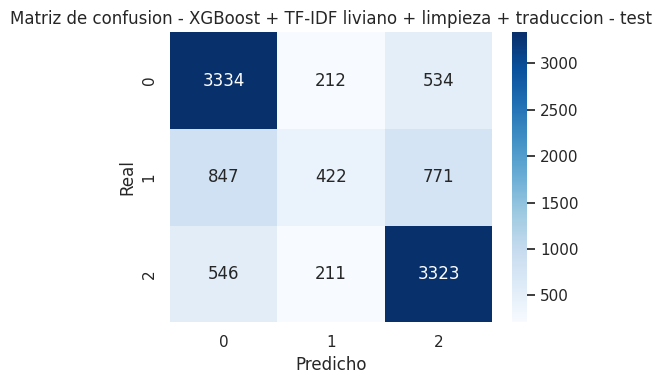


Brecha F1 macro train-test: 0.046168
No se observa una brecha grande de F1 macro.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
1,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
2,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
3,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib


In [ ]:
pipeline_tfidf_liviano_con_limpieza_traducido = Pipeline([
    ("limpieza", FunctionTransformer(limpiar_textos_serie, validate=False)),

    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        sublinear_tf=True,
    )),
    ("clf", crear_xgb_base(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
    )),
])

res_tfidf_liviano_con_limpieza_traducido = ejecutar_experimento_traducido(
    "XGBoost + TF-IDF liviano + limpieza + traduccion",
    MODELOS_DIR / "xgboost_tfidf_liviano_con_limpieza_traduccion.joblib",
    pipeline_tfidf_liviano_con_limpieza_traducido,
)


### Experimento B: XGBoost + Bag of Words liviano

Modelo liviano con Bag of Words.


Cargando modelo existente: modelosXGBoost/xgboost_bow_liviano.joblib

XGBoost + Bag of Words liviano - train
Accuracy : 0.711324
F1 macro : 0.630049

Classification report:
              precision    recall  f1-score   support

           0     0.7231    0.8195    0.7683     16320
           1     0.5995    0.2456    0.3484      8160
           2     0.7196    0.8360    0.7734     16320

    accuracy                         0.7113     40800
   macro avg     0.6807    0.6337    0.6300     40800
weighted avg     0.6970    0.7113    0.6864     40800



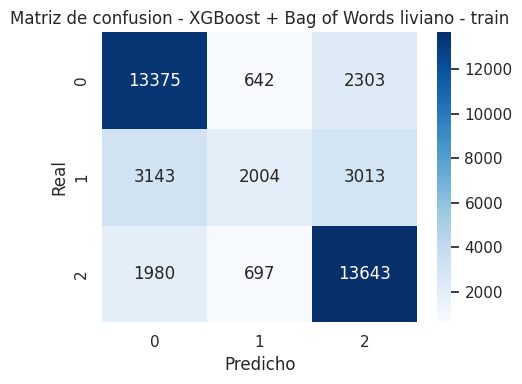


XGBoost + Bag of Words liviano - test
Accuracy : 0.687255
F1 macro : 0.596710

Classification report:
              precision    recall  f1-score   support

           0     0.7000    0.8020    0.7475      4080
           1     0.5037    0.1990    0.2853      2040
           2     0.7059    0.8167    0.7573      4080

    accuracy                         0.6873     10200
   macro avg     0.6366    0.6059    0.5967     10200
weighted avg     0.6631    0.6873    0.6590     10200



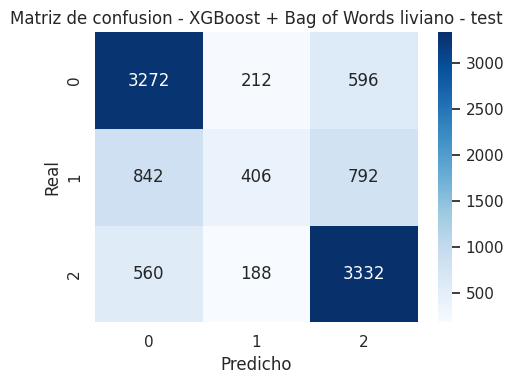


Brecha F1 macro train-test: 0.033339
No se observa una brecha grande de F1 macro.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
1,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
2,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
3,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib
4,XGBoost + Bag of Words liviano,0.630049,0.596710,0.711324,0.687255,0.033339,None,modelosXGBoost/xgboost_bow_liviano.joblib


In [ ]:
pipeline_bow_liviano = Pipeline([
    ("bow", CountVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        binary=False,
    )),
    ("clf", crear_xgb_base(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
    )),
])

res_bow_liviano = ejecutar_experimento(
    "XGBoost + Bag of Words liviano",
    MODELOS_DIR / "xgboost_bow_liviano.joblib",
    pipeline_bow_liviano,
)


### Experimento B-2: XGBoost + Bag of Words liviano + limpieza de texto

Modelo liviano con Bag of Words con limpieza de texto


Cargando modelo existente: modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib

XGBoost + Bag of Words liviano + limpieza de texto - train
Accuracy : 0.710931
F1 macro : 0.629352

Classification report:
              precision    recall  f1-score   support

           0     0.7221    0.8193    0.7677     16320
           1     0.5941    0.2445    0.3464      8160
           2     0.7207    0.8358    0.7740     16320

    accuracy                         0.7109     40800
   macro avg     0.6790    0.6332    0.6294     40800
weighted avg     0.6960    0.7109    0.6859     40800



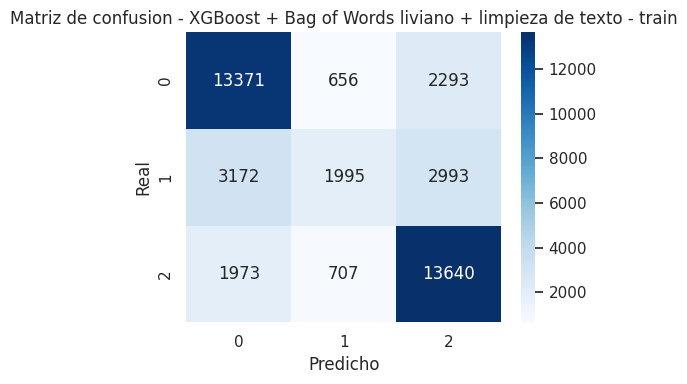


XGBoost + Bag of Words liviano + limpieza de texto - test
Accuracy : 0.688627
F1 macro : 0.600066

Classification report:
              precision    recall  f1-score   support

           0     0.7018    0.8005    0.7479      4080
           1     0.5140    0.2064    0.2945      2040
           2     0.7059    0.8179    0.7578      4080

    accuracy                         0.6886     10200
   macro avg     0.6406    0.6083    0.6001     10200
weighted avg     0.6659    0.6886    0.6612     10200



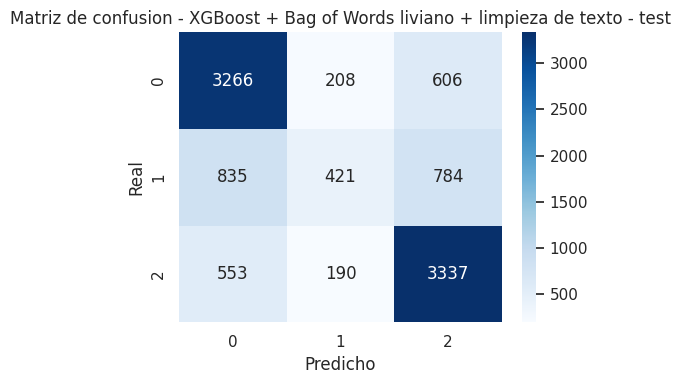


Brecha F1 macro train-test: 0.029287
No se observa una brecha grande de F1 macro.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
1,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
2,XGBoost + Bag of Words liviano + limpieza de texto,0.629352,0.600066,0.710931,0.688627,0.029287,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib
3,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
4,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib
5,XGBoost + Bag of Words liviano,0.630049,0.596710,0.711324,0.687255,0.033339,None,modelosXGBoost/xgboost_bow_liviano.joblib


In [ ]:
pipeline_bow_liviano_limpieza = Pipeline([
    ("limpieza", FunctionTransformer(limpiar_textos_serie, validate=False)),

    ("bow", CountVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        binary=False,
    )),
    ("clf", crear_xgb_base(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
    )),
])

res_bow_liviano_limpieza = ejecutar_experimento(
    "XGBoost + Bag of Words liviano + limpieza de texto",
    MODELOS_DIR / "xgboost_bow_liviano_con_limpieza.joblib",
    pipeline_bow_liviano_limpieza,
)


### Experimento B-3: XGBoost + Bag of Words liviano + traduccion de texto

Modelo liviano con Bag of Words con traduccion de texto.


Cargando modelo existente: modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib

XGBoost + Bag of Words liviano + traduccion de texto - train
Accuracy : 0.714510
F1 macro : 0.634068

Classification report:
              precision    recall  f1-score   support

           0     0.7230    0.8263    0.7712     16320
           1     0.5954    0.2513    0.3535      8160
           2     0.7280    0.8343    0.7775     16320

    accuracy                         0.7145     40800
   macro avg     0.6821    0.6373    0.6341     40800
weighted avg     0.6995    0.7145    0.6902     40800



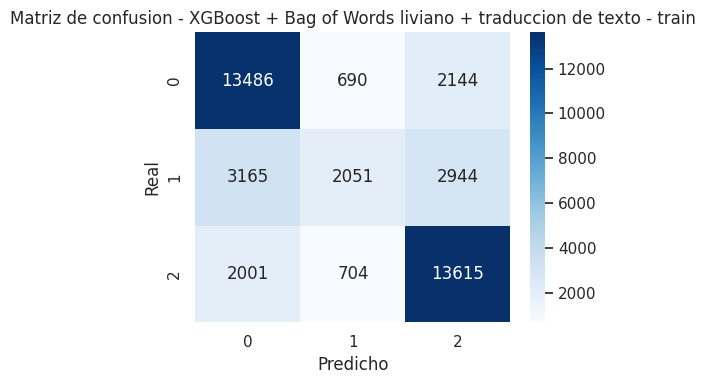


XGBoost + Bag of Words liviano + traduccion de texto - test
Accuracy : 0.693431
F1 macro : 0.605194

Classification report:
              precision    recall  f1-score   support

           0     0.7049    0.8120    0.7547      4080
           1     0.5065    0.2113    0.2982      2040
           2     0.7161    0.8159    0.7627      4080

    accuracy                         0.6934     10200
   macro avg     0.6425    0.6131    0.6052     10200
weighted avg     0.6697    0.6934    0.6666     10200



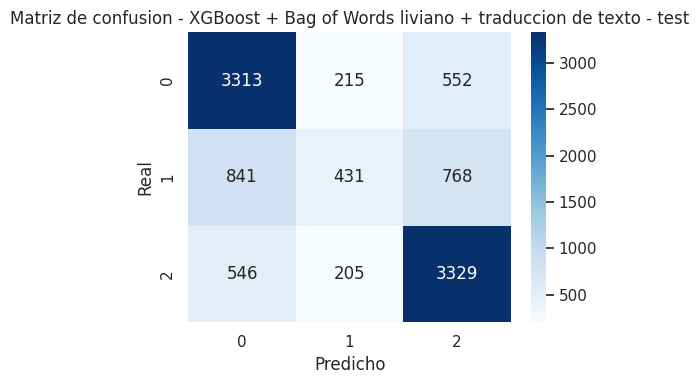


Brecha F1 macro train-test: 0.028874
No se observa una brecha grande de F1 macro.
Nuevo mejor modelo guardado en: modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
1,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
2,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
3,XGBoost + Bag of Words liviano + limpieza de texto,0.629352,0.600066,0.710931,0.688627,0.029287,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib
4,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
5,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib
6,XGBoost + Bag of Words liviano,0.630049,0.596710,0.711324,0.687255,0.033339,None,modelosXGBoost/xgboost_bow_liviano.joblib


In [ ]:
pipeline_bow_liviano_traduccion = Pipeline([
    ("bow", CountVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        binary=False,
    )),
    ("clf", crear_xgb_base(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
    )),
])

res_bow_liviano_traduccion = ejecutar_experimento_traducido(
    "XGBoost + Bag of Words liviano + traduccion de texto",
    MODELOS_DIR / "xgboost_bow_liviano_con_traduccion.joblib",
    pipeline_bow_liviano_traduccion,
)


### Experimento B-4: XGBoost + Bag of Words liviano + traduccion de texto + limpieza de texto

Modelo liviano con Bag of Words de palabras con traduccion de texto y con limpieza de texto.



Cargando modelo existente: modelosXGBoost/xgboost_bow_liviano_con_limpieza_traduccion.joblib

XGBoost + Bag of Words liviano + limpieza + traduccion - train
Accuracy : 0.714706
F1 macro : 0.635369

Classification report:
              precision    recall  f1-score   support

           0     0.7229    0.8265    0.7712     16320
           1     0.5917    0.2558    0.3571      8160
           2     0.7298    0.8324    0.7777     16320

    accuracy                         0.7147     40800
   macro avg     0.6815    0.6382    0.6354     40800
weighted avg     0.6994    0.7147    0.6910     40800



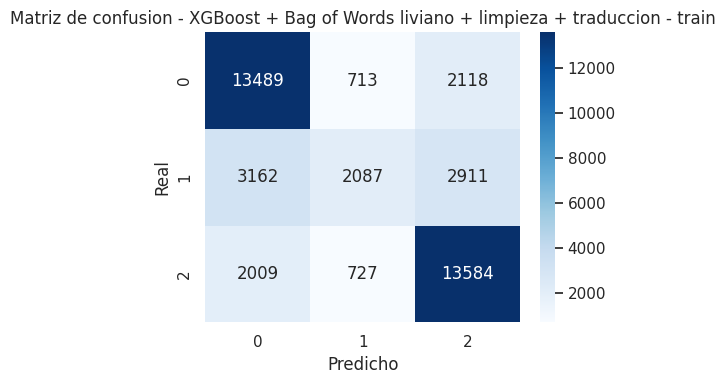


XGBoost + Bag of Words liviano + limpieza + traduccion - test
Accuracy : 0.692745
F1 macro : 0.604040

Classification report:
              precision    recall  f1-score   support

           0     0.7049    0.8103    0.7539      4080
           1     0.5018    0.2093    0.2954      2040
           2     0.7154    0.8169    0.7628      4080

    accuracy                         0.6927     10200
   macro avg     0.6407    0.6122    0.6040     10200
weighted avg     0.6685    0.6927    0.6658     10200



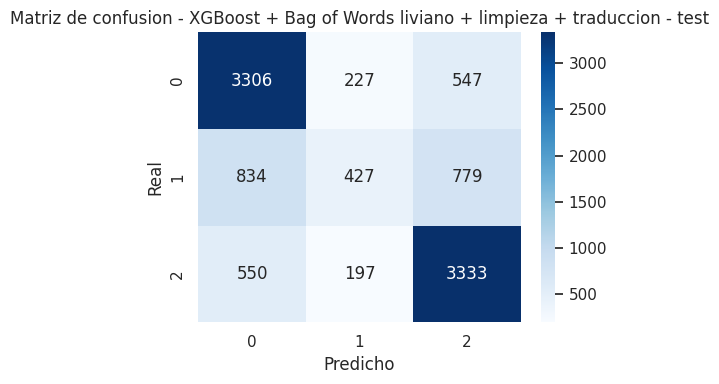


Brecha F1 macro train-test: 0.031329
No se observa una brecha grande de F1 macro.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
1,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
2,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
3,XGBoost + Bag of Words liviano + limpieza + traduccion,0.635369,0.604040,0.714706,0.692745,0.031329,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza_traduccion.joblib
4,XGBoost + Bag of Words liviano + limpieza de texto,0.629352,0.600066,0.710931,0.688627,0.029287,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib
5,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
6,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib
7,XGBoost + Bag of Words liviano,0.630049,0.596710,0.711324,0.687255,0.033339,None,modelosXGBoost/xgboost_bow_liviano.joblib


In [ ]:
pipeline_bow_liviano_con_limpieza_traducido = Pipeline([
    ("limpieza", FunctionTransformer(limpiar_textos_serie, validate=False)),

    ("bow", CountVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        binary=False,
    )),
    ("clf", crear_xgb_base(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
    )),
])

res_bow_liviano_con_limpieza_traducido = ejecutar_experimento_traducido(
    "XGBoost + Bag of Words liviano + limpieza + traduccion",
    MODELOS_DIR / "xgboost_bow_liviano_con_limpieza_traduccion.joblib",
    pipeline_bow_liviano_con_limpieza_traducido,
)


### Experimento C: XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV

Busqueda aleatoria de hiperparametros para TF-IDF y XGBoost, con limpieza y traduccion de texto


Cargando modelo existente: modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib

XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV - train
Accuracy : 0.745441
F1 macro : 0.675370

Classification report:
              precision    recall  f1-score   support

           0     0.7504    0.8553    0.7994     16320
           1     0.6226    0.3162    0.4194      8160
           2     0.7686    0.8502    0.8073     16320

    accuracy                         0.7454     40800
   macro avg     0.7138    0.6739    0.6754     40800
weighted avg     0.7321    0.7454    0.7266     40800



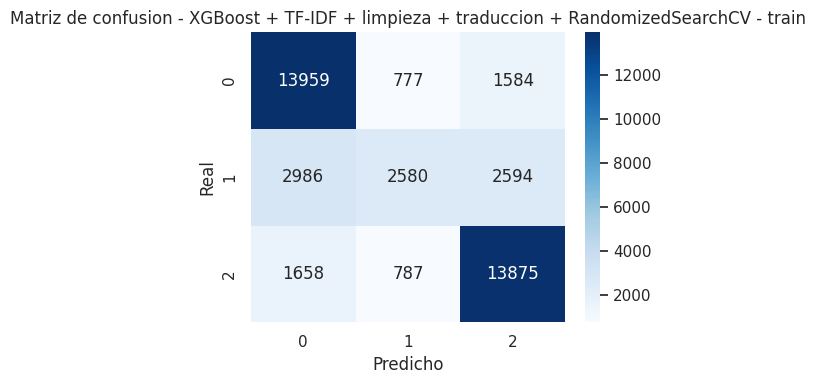


XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV - test
Accuracy : 0.708137
F1 macro : 0.624620

Classification report:
              precision    recall  f1-score   support

           0     0.7231    0.8275    0.7717      4080
           1     0.4915    0.2402    0.3227      2040
           2     0.7404    0.8228    0.7794      4080

    accuracy                         0.7081     10200
   macro avg     0.6516    0.6301    0.6246     10200
weighted avg     0.6837    0.7081    0.6850     10200



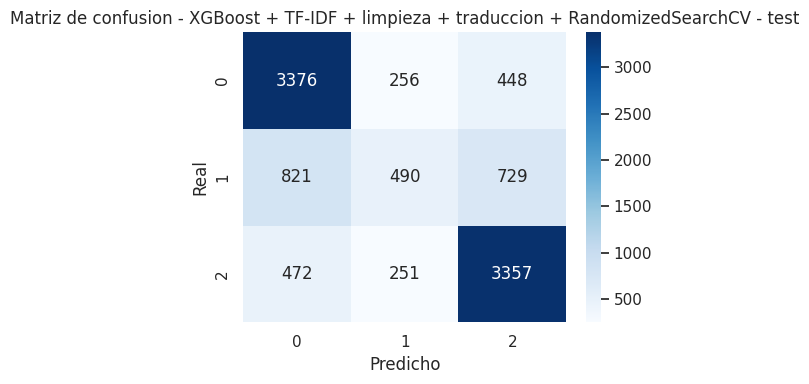


Brecha F1 macro train-test: 0.050750
No se observa una brecha grande de F1 macro.
Nuevo mejor modelo guardado en: modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV,0.675370,0.624620,0.745441,0.708137,0.050750,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib
1,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
2,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
3,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
4,XGBoost + Bag of Words liviano + limpieza + traduccion,0.635369,0.604040,0.714706,0.692745,0.031329,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza_traduccion.joblib
5,XGBoost + Bag of Words liviano + limpieza de texto,0.629352,0.600066,0.710931,0.688627,0.029287,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib
6,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
7,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib
8,XGBoost + Bag of Words liviano,0.630049,0.596710,0.711324,0.687255,0.033339,None,modelosXGBoost/xgboost_bow_liviano.joblib


In [ ]:
pipeline_tfidf_search = Pipeline([
    ("limpieza", FunctionTransformer(limpiar_textos_serie, validate=False)),
    ("tfidf", TfidfVectorizer()),
    ("clf", crear_xgb_base()),
])

params_tfidf_search = {
    "tfidf__max_features": [5000, 10000, 20000, 30000, 50000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__max_df": [0.8, 0.9, 0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],

    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5, 7],
    "clf__gamma": [0, 0.1, 0.3, 0.5],
    "clf__reg_alpha": [0, 0.01, 0.1, 1.0],
    "clf__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}


res_tfidf_search = entrenar_randomized_search(
    "XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV",
    pipeline_tfidf_search,
    params_tfidf_search,
    MODELOS_DIR / "xgboost_tfidf_limpieza_traduccion_random_search.joblib",
    traduccion=True
)




### Experimento C-2: XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + sample weight

Busqueda aleatoria de hiperparametros para TF-IDF y XGBoost, con limpieza, traduccion de texto y balanceo de clases


Cargando modelo existente: modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib

XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo - train
Accuracy : 0.733260
F1 macro : 0.709100

Classification report:
              precision    recall  f1-score   support

           0     0.8205    0.7469    0.7819     16320
           1     0.4761    0.6404    0.5462      8160
           2     0.8352    0.7661    0.7992     16320

    accuracy                         0.7333     40800
   macro avg     0.7106    0.7178    0.7091     40800
weighted avg     0.7575    0.7333    0.7417     40800



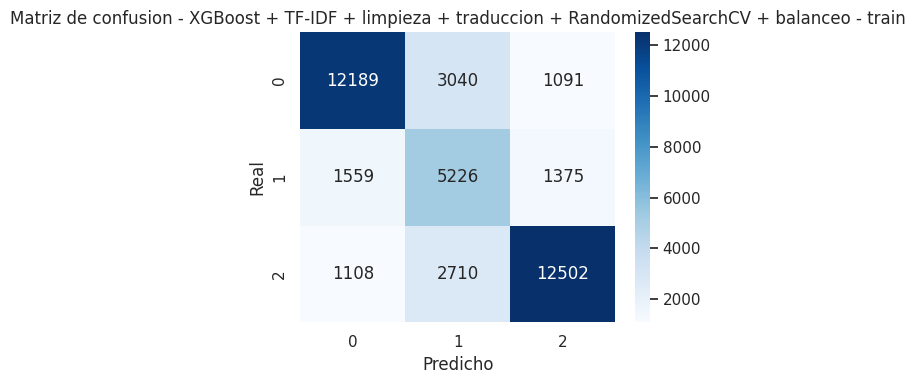


XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo - test
Accuracy : 0.686373
F1 macro : 0.657336

Classification report:
              precision    recall  f1-score   support

           0     0.7847    0.7083    0.7446      4080
           1     0.3967    0.5412    0.4578      2040
           2     0.8053    0.7370    0.7696      4080

    accuracy                         0.6864     10200
   macro avg     0.6622    0.6622    0.6573     10200
weighted avg     0.7153    0.6864    0.6972     10200



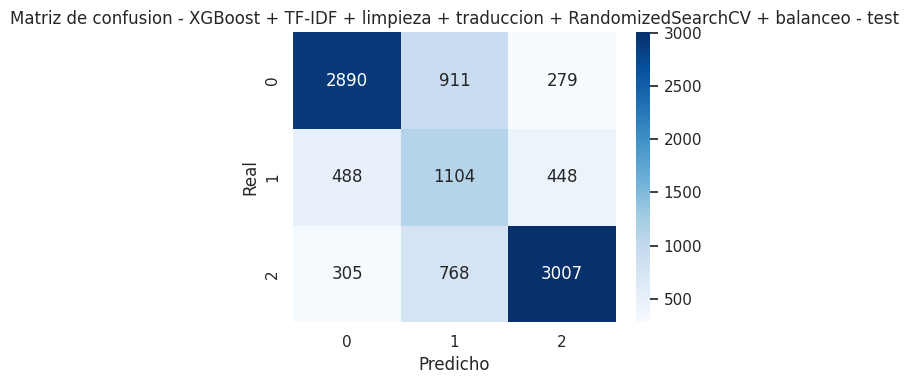


Brecha F1 macro train-test: 0.051764
No se observa una brecha grande de F1 macro.
Nuevo mejor modelo guardado en: modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
1,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV,0.675370,0.624620,0.745441,0.708137,0.050750,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib
2,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
3,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
4,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
5,XGBoost + Bag of Words liviano + limpieza + traduccion,0.635369,0.604040,0.714706,0.692745,0.031329,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza_traduccion.joblib
6,XGBoost + Bag of Words liviano + limpieza de texto,0.629352,0.600066,0.710931,0.688627,0.029287,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib
7,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
8,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib
9,XGBoost + Bag of Words liviano,0.630049,0.596710,0.711324,0.687255,0.033339,None,modelosXGBoost/xgboost_bow_liviano.joblib


In [ ]:
pipeline_tfidf_search = Pipeline([
    ("limpieza", FunctionTransformer(limpiar_textos_serie, validate=False)),
    ("tfidf", TfidfVectorizer()),
    ("clf", crear_xgb_base()),
])

params_tfidf_search = {
    "tfidf__max_features": [5000, 10000, 20000, 30000, 50000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__max_df": [0.8, 0.9, 0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],

    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5, 7],
    "clf__gamma": [0, 0.1, 0.3, 0.5],
    "clf__reg_alpha": [0, 0.01, 0.1, 1.0],
    "clf__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}


res_tfidf_search = entrenar_randomized_search_con_sample_weight(
    "XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo",
    pipeline_tfidf_search,
    params_tfidf_search,
    MODELOS_DIR / "xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib",
    traduccion=True
)




### Experimento C-3: XGBoost + TF-IDF + RandomizedSearchCV + sample weight

Busqueda aleatoria de hiperparametros para TF-IDF y XGBoost con balanceo de pesos


Cargando modelo existente: modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib

XGBoost + TF-IDF + RandomizedSearchCV + balanceo - train
Accuracy : 0.800319
F1 macro : 0.780286

Classification report:
              precision    recall  f1-score   support

           0     0.8709    0.8083    0.8385     16320
           1     0.5761    0.7485    0.6511      8160
           2     0.8872    0.8182    0.8513     16320

    accuracy                         0.8003     40800
   macro avg     0.7781    0.7917    0.7803     40800
weighted avg     0.8185    0.8003    0.8061     40800



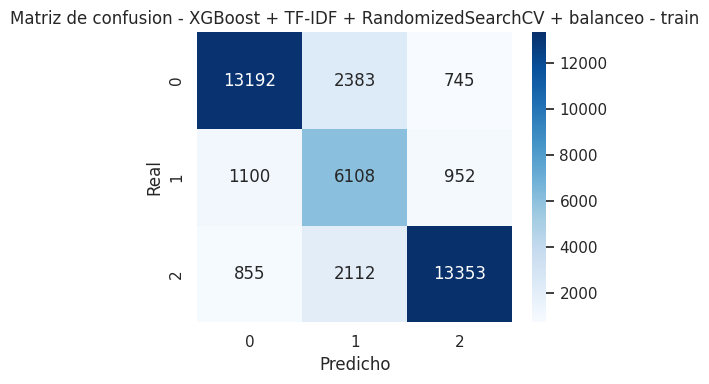


XGBoost + TF-IDF + RandomizedSearchCV + balanceo - test
Accuracy : 0.699510
F1 macro : 0.665027

Classification report:
              precision    recall  f1-score   support

           0     0.7855    0.7324    0.7580      4080
           1     0.3992    0.5093    0.4476      2040
           2     0.8194    0.7618    0.7895      4080

    accuracy                         0.6995     10200
   macro avg     0.6680    0.6678    0.6650     10200
weighted avg     0.7218    0.6995    0.7085     10200



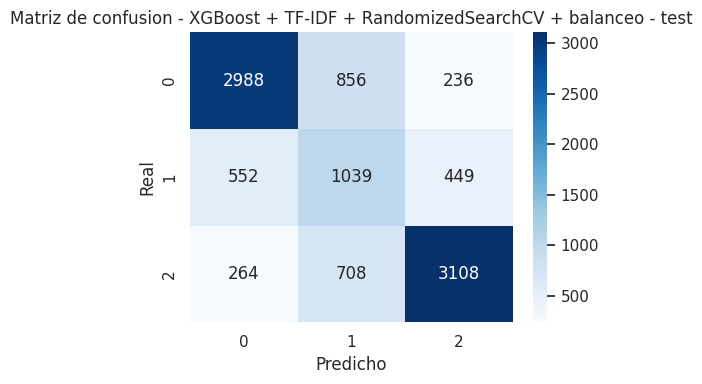


Brecha F1 macro train-test: 0.115259
Posible overfitting: la brecha de F1 macro supera 0.08.
Nuevo mejor modelo guardado en: modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
2,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV,0.675370,0.624620,0.745441,0.708137,0.050750,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib
3,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
4,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
5,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
6,XGBoost + Bag of Words liviano + limpieza + traduccion,0.635369,0.604040,0.714706,0.692745,0.031329,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza_traduccion.joblib
7,XGBoost + Bag of Words liviano + limpieza de texto,0.629352,0.600066,0.710931,0.688627,0.029287,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib
8,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib
9,XGBoost + TF-IDF liviano + limpieza,0.645355,0.596772,0.722353,0.689510,0.048583,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza.joblib


In [ ]:
pipeline_tfidf_search = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", crear_xgb_base()),
])

params_tfidf_search = {
    "tfidf__max_features": [5000, 10000, 20000, 30000, 50000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__max_df": [0.8, 0.9, 0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__strip_accents": ["unicode", None],

    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5, 7],
    "clf__gamma": [0, 0.1, 0.3, 0.5],
    "clf__reg_alpha": [0, 0.01, 0.1, 1.0],
    "clf__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}


res_tfidf_search = entrenar_randomized_search_con_sample_weight(
    "XGBoost + TF-IDF + RandomizedSearchCV + balanceo",
    pipeline_tfidf_search,
    params_tfidf_search,
    MODELOS_DIR / "xgboost_tfidf_random_search_balanceo.joblib",
    traduccion=False
)




### Experimento D: XGBoost + Bag of Words + RandomizedSearchCV + Traduccion

Busqueda aleatoria de hiperparametros para Bag of Words y XGBoost con texto traducido.


Cargando modelo existente: modelosXGBoost/xgboost_bow_random_search_traduccion.joblib

XGBoost + Bag of Words + RandomizedSearchCV + Traduccion - train
Accuracy : 0.782990
F1 macro : 0.731784

Classification report:
              precision    recall  f1-score   support

           0     0.7830    0.8767    0.8272     16320
           1     0.7282    0.4249    0.5366      8160
           2     0.7977    0.8683    0.8315     16320

    accuracy                         0.7830     40800
   macro avg     0.7696    0.7233    0.7318     40800
weighted avg     0.7779    0.7830    0.7708     40800



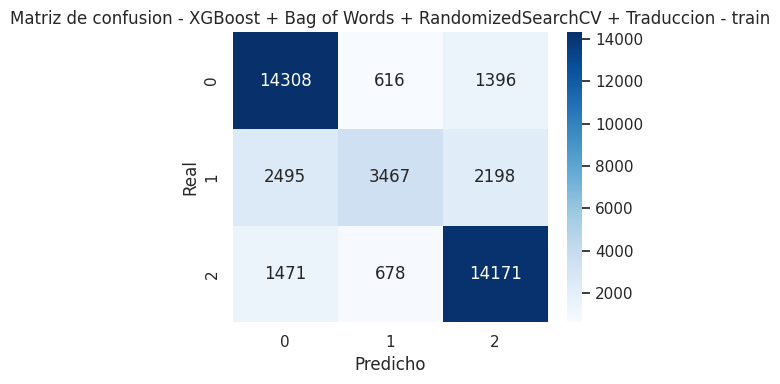


XGBoost + Bag of Words + RandomizedSearchCV + Traduccion - test
Accuracy : 0.708235
F1 macro : 0.627557

Classification report:
              precision    recall  f1-score   support

           0     0.7231    0.8233    0.7700      4080
           1     0.4817    0.2515    0.3304      2040
           2     0.7465    0.8216    0.7823      4080

    accuracy                         0.7082     10200
   macro avg     0.6505    0.6321    0.6276     10200
weighted avg     0.6842    0.7082    0.6870     10200



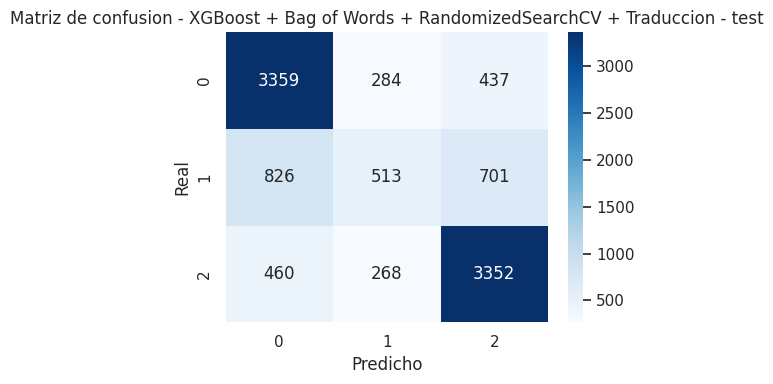


Brecha F1 macro train-test: 0.104227
Posible overfitting: la brecha de F1 macro supera 0.08.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
2,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion,0.731784,0.627557,0.782990,0.708235,0.104227,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion.joblib
3,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV,0.675370,0.624620,0.745441,0.708137,0.050750,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib
4,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
5,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
6,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
7,XGBoost + Bag of Words liviano + limpieza + traduccion,0.635369,0.604040,0.714706,0.692745,0.031329,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza_traduccion.joblib
8,XGBoost + Bag of Words liviano + limpieza de texto,0.629352,0.600066,0.710931,0.688627,0.029287,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib
9,XGBoost + TF-IDF liviano,0.645349,0.596959,0.722304,0.688235,0.048391,None,modelosXGBoost/xgboost_tfidf_liviano.joblib


In [ ]:
pipeline_bow_search = Pipeline([
    ("bow", CountVectorizer()),
    ("clf", crear_xgb_base()),
])

params_bow_search = {
    "bow__max_features": [5000, 10000, 20000, 30000, 50000],
    "bow__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "bow__min_df": [1, 2, 3, 5],
    "bow__max_df": [0.8, 0.9, 0.95, 1.0],
    "bow__binary": [True, False],
    "bow__strip_accents": ["unicode", None],
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5, 7],
    "clf__gamma": [0, 0.1, 0.3, 0.5],
    "clf__reg_alpha": [0, 0.01, 0.1, 1.0],
    "clf__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}


res_bow_search = entrenar_randomized_search(
    "XGBoost + Bag of Words + RandomizedSearchCV + Traduccion",
    pipeline_bow_search,
    params_bow_search,
    MODELOS_DIR / "xgboost_bow_random_search_traduccion.joblib",
    traduccion= True
)




### Experimento D-2: XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + sample weight

Busqueda aleatoria de hiperparametros para Bag of Words y XGBoost con texto traducido y balanceo de clases.


Cargando modelo existente: modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib

XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo - train
Accuracy : 0.775931
F1 macro : 0.754461

Classification report:
              precision    recall  f1-score   support

           0     0.8472    0.7918    0.8185     16320
           1     0.5555    0.7027    0.6205      8160
           2     0.8540    0.7967    0.8244     16320

    accuracy                         0.7759     40800
   macro avg     0.7522    0.7637    0.7545     40800
weighted avg     0.7916    0.7759    0.7813     40800



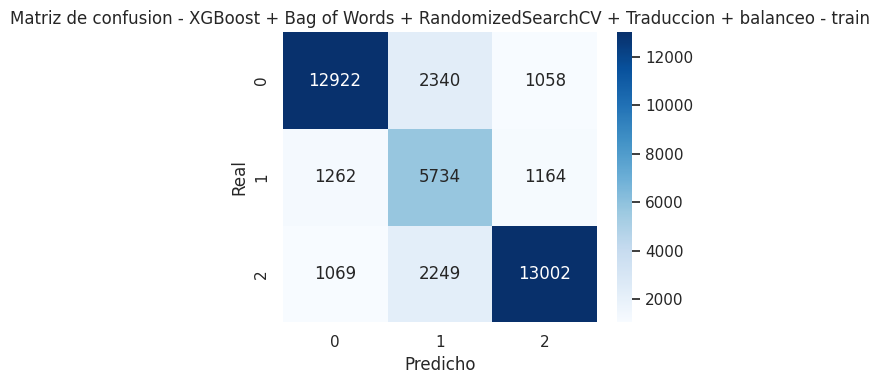


XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo - test
Accuracy : 0.691078
F1 macro : 0.657558

Classification report:
              precision    recall  f1-score   support

           0     0.7812    0.7279    0.7536      4080
           1     0.4034    0.5078    0.4497      2040
           2     0.7945    0.7458    0.7694      4080

    accuracy                         0.6911     10200
   macro avg     0.6597    0.6605    0.6576     10200
weighted avg     0.7110    0.6911    0.6991     10200



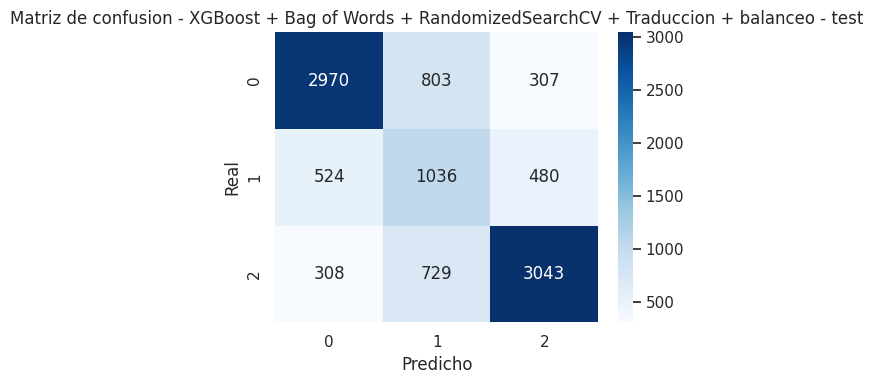


Brecha F1 macro train-test: 0.096902
Posible overfitting: la brecha de F1 macro supera 0.08.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo,0.754461,0.657558,0.775931,0.691078,0.096902,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib
2,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
3,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion,0.731784,0.627557,0.782990,0.708235,0.104227,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion.joblib
4,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV,0.675370,0.624620,0.745441,0.708137,0.050750,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib
5,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
6,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
7,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
8,XGBoost + Bag of Words liviano + limpieza + traduccion,0.635369,0.604040,0.714706,0.692745,0.031329,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza_traduccion.joblib
9,XGBoost + Bag of Words liviano + limpieza de texto,0.629352,0.600066,0.710931,0.688627,0.029287,None,modelosXGBoost/xgboost_bow_liviano_con_limpieza.joblib


In [ ]:
pipeline_bow_search = Pipeline([
    ("bow", CountVectorizer()),
    ("clf", crear_xgb_base()),
])

params_bow_search = {
    "bow__max_features": [5000, 10000, 20000, 30000, 50000],
    "bow__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "bow__min_df": [1, 2, 3, 5],
    "bow__max_df": [0.8, 0.9, 0.95, 1.0],
    "bow__binary": [True, False],
    "bow__strip_accents": ["unicode", None],

    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5, 7],
    "clf__gamma": [0, 0.1, 0.3, 0.5],
    "clf__reg_alpha": [0, 0.01, 0.1, 1.0],
    "clf__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}


res_bow_search = entrenar_randomized_search_con_sample_weight(
    "XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo",
    pipeline_bow_search,
    params_bow_search,
    MODELOS_DIR / "xgboost_bow_random_search_traduccion_balanceo.joblib",
    traduccion= True
)




### Experimento D-3: XGBoost + Bag of Words + RandomizedSearchCV + sample weigth

Busqueda aleatoria de hiperparametros para Bag of Words y XGBoost con balanceo de clases


Cargando modelo existente: modelosXGBoost/xgboost_bow_random_search_balanceo.joblib

XGBoost + Bag of Words + RandomizedSearchCV + balanceo - train
Accuracy : 0.771152
F1 macro : 0.750317

Classification report:
              precision    recall  f1-score   support

           0     0.8478    0.7786    0.8117     16320
           1     0.5510    0.7051    0.6186      8160
           2     0.8460    0.7967    0.8206     16320

    accuracy                         0.7712     40800
   macro avg     0.7483    0.7602    0.7503     40800
weighted avg     0.7877    0.7712    0.7767     40800



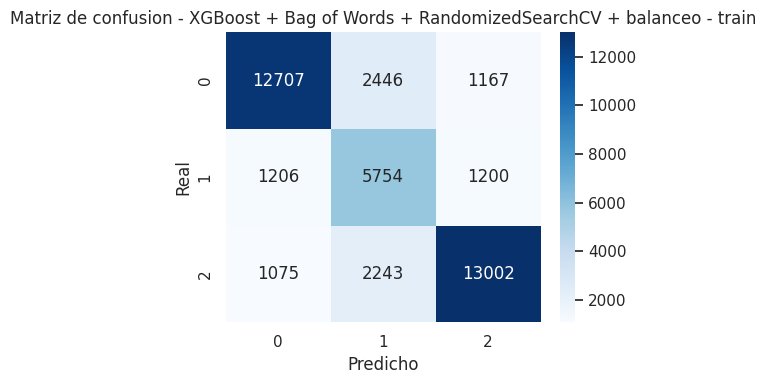


XGBoost + Bag of Words + RandomizedSearchCV + balanceo - test
Accuracy : 0.685000
F1 macro : 0.652906

Classification report:
              precision    recall  f1-score   support

           0     0.7801    0.7113    0.7441      4080
           1     0.4032    0.5132    0.4516      2040
           2     0.7824    0.7446    0.7630      4080

    accuracy                         0.6850     10200
   macro avg     0.6552    0.6564    0.6529     10200
weighted avg     0.7056    0.6850    0.6932     10200



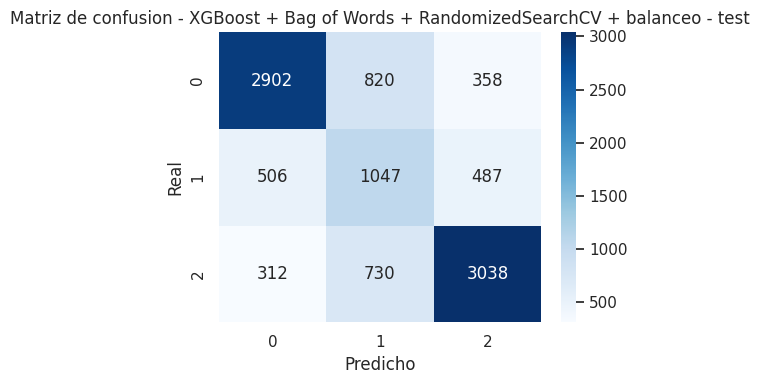


Brecha F1 macro train-test: 0.097412
Posible overfitting: la brecha de F1 macro supera 0.08.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo,0.754461,0.657558,0.775931,0.691078,0.096902,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib
2,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
3,XGBoost + Bag of Words + RandomizedSearchCV + balanceo,0.750317,0.652906,0.771152,0.685000,0.097412,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_balanceo.joblib
4,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion,0.731784,0.627557,0.782990,0.708235,0.104227,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion.joblib
5,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV,0.675370,0.624620,0.745441,0.708137,0.050750,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib
6,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
7,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
8,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccion.joblib
9,XGBoost + Bag of Words liviano + limpieza + traduccion,0.635369,0.604040,0.714706,0.692745,0.031329,None,modelosXGBoost/xgboost_bow_liviano_c

In [ ]:
pipeline_bow_search = Pipeline([
    ("bow", CountVectorizer()),
    ("clf", crear_xgb_base()),
])

params_bow_search = {
    "bow__max_features": [5000, 10000, 20000, 30000, 50000],
    "bow__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "bow__min_df": [1, 2, 3, 5],
    "bow__max_df": [0.8, 0.9, 0.95, 1.0],
    "bow__binary": [True, False],
    "bow__strip_accents": ["unicode", None],
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5, 7],
    "clf__gamma": [0, 0.1, 0.3, 0.5],
    "clf__reg_alpha": [0, 0.01, 0.1, 1.0],
    "clf__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}


res_bow_search = entrenar_randomized_search_con_sample_weight(
    "XGBoost + Bag of Words + RandomizedSearchCV + balanceo",
    pipeline_bow_search,
    params_bow_search,
    MODELOS_DIR / "xgboost_bow_random_search_balanceo.joblib",
    traduccion= False
)




### Experimento E: XGBoost + texto limpio + Fast Text + sample weigth

Modelo base con Fast Text con texto limpio y balanceo de clases


  0%|          | 0/40800 [00:00<?, ?it/s]

  0%|          | 0/10200 [00:00<?, ?it/s]

Entrenando FastText...
FastText guardado.
Cargando embeddings FastText desde disco...
(40800, 300)
(10200, 300)
Cargando modelo existente: modelosXGBoost/xgboost_fasttext_normal_texto_limpio.joblib

XGBoost + FastText normal + texto limpio - train
Accuracy : 0.742525
F1 macro : 0.719155

Classification report:
              precision    recall  f1-score   support

           0     0.8199    0.7639    0.7909     16320
           1     0.4892    0.6580    0.5612      8160
           2     0.8522    0.7634    0.8054     16320

    accuracy                         0.7425     40800
   macro avg     0.7204    0.7284    0.7192     40800
weighted avg     0.7667    0.7425    0.7508     40800



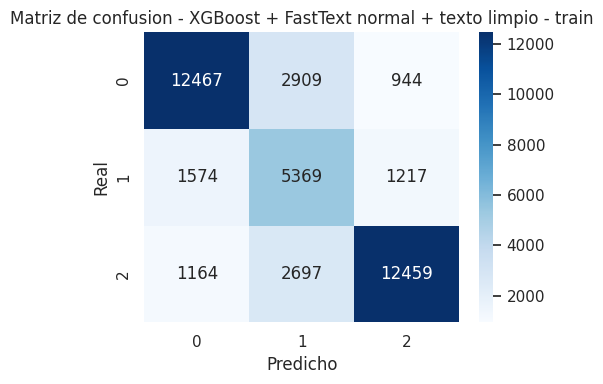


XGBoost + FastText normal + texto limpio - test
Accuracy : 0.673824
F1 macro : 0.640320

Classification report:
              precision    recall  f1-score   support

           0     0.7619    0.7145    0.7374      4080
           1     0.3708    0.4868    0.4209      2040
           2     0.8022    0.7267    0.7626      4080

    accuracy                         0.6738     10200
   macro avg     0.6450    0.6426    0.6403     10200
weighted avg     0.6998    0.6738    0.6842     10200



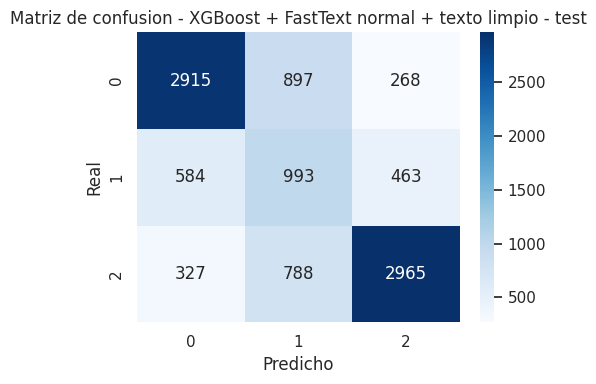


Brecha F1 macro train-test: 0.078835
No se observa una brecha grande de F1 macro.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo,0.754461,0.657558,0.775931,0.691078,0.096902,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib
2,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
3,XGBoost + Bag of Words + RandomizedSearchCV + balanceo,0.750317,0.652906,0.771152,0.685000,0.097412,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_balanceo.joblib
4,XGBoost + FastText normal + texto limpio,0.719155,0.640320,0.742525,0.673824,0.078835,None,modelosXGBoost/xgboost_fasttext_normal_texto_limpio.joblib
5,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion,0.731784,0.627557,0.782990,0.708235,0.104227,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion.joblib
6,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV,0.675370,0.624620,0.745441,0.708137,0.050750,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib
7,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_traduccion.joblib
8,XGBoost + TF-IDF liviano + traduccion,0.651636,0.604417,0.726863,0.693529,0.047219,None,modelosXGBoost/xgboost_tfidf_liviano_traduccion.joblib
9,XGBoost + TF-IDF liviano + limpieza + traduccion,0.650461,0.604293,0.725588,0.694020,0.046168,None,modelosXGBoost/xgboost_tfidf_liviano_con_limpieza_traduccio

{'experimento': 'XGBoost + FastText normal + texto limpio',
 'f1_macro_train': 0.7191545625999712,
 'f1_macro_test': 0.640319526397362,
 'accuracy_train': 0.7425245098039216,
 'accuracy_test': 0.6738235294117647,
 'brecha_f1_train_test': 0.07883503620260923,
 'mejores_parametros': None,
 'ruta_modelo': 'modelosXGBoost/xgboost_fasttext_normal_texto_limpio.joblib'}

In [ ]:

import numpy as np
from gensim.models import FastText


# Datos normales
X_train_ft_textos = X_train
X_test_ft_textos = X_test
y_train_ft = y_train
y_test_ft = y_test

def tokenizar_para_fasttext(texto):
    texto_limpio = limpiar_texto(texto)
    return texto_limpio.split()

tokens_train = [tokenizar_para_fasttext(texto) for texto in tqdm(X_train_ft_textos)]
tokens_test = [tokenizar_para_fasttext(texto) for texto in tqdm(X_test_ft_textos)]

RUTA_FASTTEXT = MODELOS_DIR / "fasttext_entrenado.model"

if RUTA_FASTTEXT.exists():
    print("Cargando FastText existente...")
    modelo_fasttext = FastText.load(str(RUTA_FASTTEXT))
else:
    print("Entrenando FastText...")
    modelo_fasttext = FastText(
        sentences=tokens_train,
        vector_size=300,
        window=5,
        min_count=2,
        workers=6,
        sg=1,
        epochs=20,
        seed=RANDOM_STATE,
    )
    modelo_fasttext.save(str(RUTA_FASTTEXT))
    print("FastText guardado.")

def vectorizar_texto_fasttext(tokens, modelo_fasttext):
    vectores = []

    for palabra in tokens:
        try:
            vectores.append(modelo_fasttext.wv[palabra])
        except KeyError:
            pass

    if len(vectores) == 0:
        return np.zeros(modelo_fasttext.vector_size, dtype=np.float32)

    return np.mean(vectores, axis=0).astype(np.float32)

RUTA_X_TRAIN_FASTTEXT = MODELOS_DIR / "X_train_fasttext.npy"
RUTA_X_TEST_FASTTEXT = MODELOS_DIR / "X_test_fasttext.npy"

if RUTA_X_TRAIN_FASTTEXT.exists() and RUTA_X_TEST_FASTTEXT.exists():
    print("Cargando embeddings FastText desde disco...")
    X_train_fasttext = np.load(RUTA_X_TRAIN_FASTTEXT)
    X_test_fasttext = np.load(RUTA_X_TEST_FASTTEXT)
else:
    print("Generando embeddings FastText para train...")
    X_train_fasttext = np.vstack([
        vectorizar_texto_fasttext(tokens, modelo_fasttext)
        for tokens in tqdm(tokens_train)
    ])

    print("Generando embeddings FastText para test...")
    X_test_fasttext = np.vstack([
        vectorizar_texto_fasttext(tokens, modelo_fasttext)
        for tokens in tqdm(tokens_test)
    ])

    np.save(RUTA_X_TRAIN_FASTTEXT, X_train_fasttext)
    np.save(RUTA_X_TEST_FASTTEXT, X_test_fasttext)

print(X_train_fasttext.shape)
print(X_test_fasttext.shape)

sample_weight_fasttext = compute_sample_weight(
    class_weight="balanced",
    y=y_train_ft,
)

modelo_xgb_fasttext = crear_xgb_base(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2.0,
)

RUTA_XGB_FASTTEXT = MODELOS_DIR / "xgboost_fasttext_normal_texto_limpio.joblib"

def entrenar_xgb_fasttext():
    modelo_xgb_fasttext.fit(
        X_train_fasttext,
        y_train_ft,
        sample_weight=sample_weight_fasttext,
    )
    return modelo_xgb_fasttext

modelo_xgb_fasttext = guardar_o_cargar_modelo(
    RUTA_XGB_FASTTEXT,
    entrenar_xgb_fasttext,
)

metricas_train, metricas_test = evaluar_modelo(
    "XGBoost + FastText normal + texto limpio",
    modelo_xgb_fasttext,
    X_train_fasttext,
    X_test_fasttext,
    y_train_ft,
    y_test_ft,
)

registrar_resultado(
    "XGBoost + FastText normal + texto limpio",
    modelo_xgb_fasttext,
    RUTA_XGB_FASTTEXT,
    metricas_train,
    metricas_test,
)

### Experimento E-2: XGBoost + Fast Text + texto limpio+ sample weigth + random search

Modelo base con Fast Text con texto limpio y balanceo de clases con bisqueda de parametros


Cargando modelo existente: modelosXGBoost/xgboost_fasttext_random_search.joblib
Mejores parámetros:
{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Mejor score CV:
0.6371350451997243

XGBoost + FastText + RandomizedSearchCV - train
Accuracy : 0.791029
F1 macro : 0.771292

Classification report:
              precision    recall  f1-score   support

           0     0.8607    0.8061    0.8325     16320
           1     0.5673    0.7418    0.6429      8160
           2     0.8801    0.8006    0.8384     16320

    accuracy                         0.7910     40800
   macro avg     0.7694    0.7828    0.7713     40800
weighted avg     0.8098    0.7910    0.7970     40800



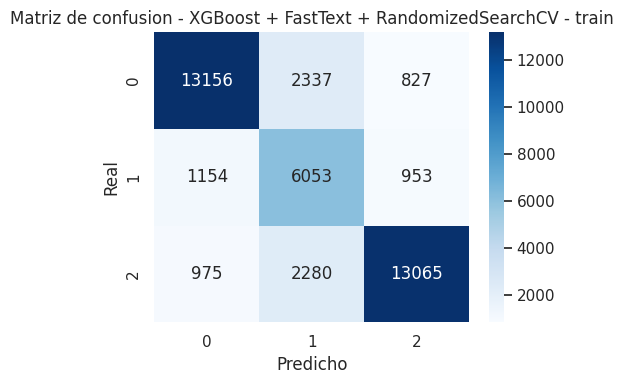


XGBoost + FastText + RandomizedSearchCV - test
Accuracy : 0.683431
F1 macro : 0.648305

Classification report:
              precision    recall  f1-score   support

           0     0.7704    0.7260    0.7475      4080
           1     0.3799    0.4853    0.4262      2040
           2     0.8053    0.7400    0.7712      4080

    accuracy                         0.6834     10200
   macro avg     0.6518    0.6504    0.6483     10200
weighted avg     0.7062    0.6834    0.6927     10200



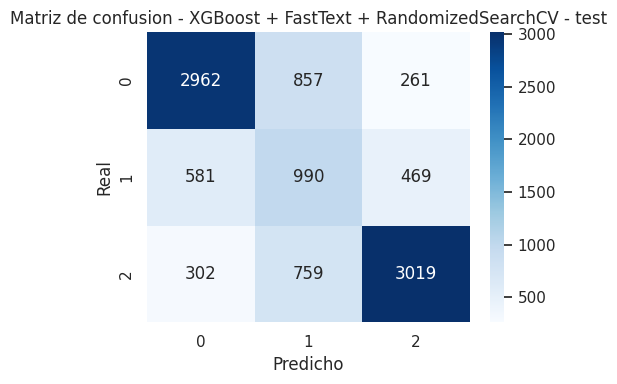


Brecha F1 macro train-test: 0.122987
Posible overfitting: la brecha de F1 macro supera 0.08.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo,0.754461,0.657558,0.775931,0.691078,0.096902,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib
2,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
3,XGBoost + Bag of Words + RandomizedSearchCV + balanceo,0.750317,0.652906,0.771152,0.685000,0.097412,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_balanceo.joblib
4,XGBoost + FastText + RandomizedSearchCV,0.771292,0.648305,0.791029,0.683431,0.122987,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_fasttext_random_search.joblib
5,XGBoost + FastText normal + texto limpio,0.719155,0.640320,0.742525,0.673824,0.078835,None,modelosXGBoost/xgboost_fasttext_normal_texto_limpio.joblib
6,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion,0.731784,0.627557,0.782990,0.708235,0.104227,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion.joblib
7,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV,0.675370,0.624620,0.745441,0.708137,0.050750,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search.joblib
8,XGBoost + Bag of Words liviano + traduccion de texto,0.634068,0.605194,0.714510,0.693431,0.028874,None,modelosXGBoost/xgboost_bow_liviano_con_trad

{'experimento': 'XGBoost + FastText + RandomizedSearchCV',
 'f1_macro_train': 0.7712924356306693,
 'f1_macro_test': 0.648305363294492,
 'accuracy_train': 0.7910294117647059,
 'accuracy_test': 0.6834313725490196,
 'brecha_f1_train_test': 0.12298707233617734,
 'mejores_parametros': {'subsample': 0.7,
  'reg_lambda': 1.0,
  'reg_alpha': 1.0,
  'n_estimators': 300,
  'min_child_weight': 5,
  'max_depth': 4,
  'learning_rate': 0.1,
  'gamma': 0.1,
  'colsample_bytree': 0.7},
 'ruta_modelo': 'modelosXGBoost/xgboost_fasttext_random_search.joblib'}

In [ ]:

params_xgb_fasttext_search = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

sample_weight_fasttext = compute_sample_weight(
    class_weight="balanced",
    y=y_train_ft,
)

search_xgb_fasttext = RandomizedSearchCV(
    estimator=crear_xgb_base(),
    param_distributions=params_xgb_fasttext_search,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring=SCORING,
    cv=CV,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=6,
)

RUTA_XGB_FASTTEXT_SEARCH = MODELOS_DIR / "xgboost_fasttext_random_search.joblib"

def entrenar_xgb_fasttext_search():
    search_xgb_fasttext.fit(
        X_train_fasttext,
        y_train_ft,
        sample_weight=sample_weight_fasttext,
    )
    return search_xgb_fasttext

modelo_xgb_fasttext_search = guardar_o_cargar_modelo(
    RUTA_XGB_FASTTEXT_SEARCH,
    entrenar_xgb_fasttext_search,
)

print("Mejores parámetros:")
print(modelo_xgb_fasttext_search.best_params_)

print("Mejor score CV:")
print(modelo_xgb_fasttext_search.best_score_)

metricas_train, metricas_test = evaluar_modelo(
    "XGBoost + FastText + RandomizedSearchCV",
    modelo_xgb_fasttext_search,
    X_train_fasttext,
    X_test_fasttext,
    y_train_ft,
    y_test_ft,
)

registrar_resultado(
    "XGBoost + FastText + RandomizedSearchCV",
    modelo_xgb_fasttext_search,
    RUTA_XGB_FASTTEXT_SEARCH,
    metricas_train,
    metricas_test,
    mejores_parametros=modelo_xgb_fasttext_search.best_params_,
)

### Experimento E-2: XGBoost + Fast Text + traduccion + texto limpio + sample weigth + random search

Modelo base con Fast Text con texto traducido, limpio y balanceo de clases con bisqueda de parametros


  0%|          | 0/40800 [00:00<?, ?it/s]

  0%|          | 0/10200 [00:00<?, ?it/s]

Cargando FastText traducido existente...
Cargando embeddings FastText traducidos desde disco...
(40800, 300)
(10200, 300)
Cargando modelo existente: modelosXGBoost/xgboost_fasttext_traducido_random_search.joblib
Mejores parámetros:
{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Mejor score CV:
0.6387677788984438

XGBoost + FastText traducido + RandomizedSearchCV - train
Accuracy : 0.791667
F1 macro : 0.772102

Classification report:
              precision    recall  f1-score   support

           0     0.8598    0.8049    0.8314     16320
           1     0.5672    0.7450    0.6440      8160
           2     0.8839    0.8018    0.8408     16320

    accuracy                         0.7917     40800
   macro avg     0.7703    0.7839    0.7721     40800
weighted avg     0.8109    0.7917    0.7977     40800



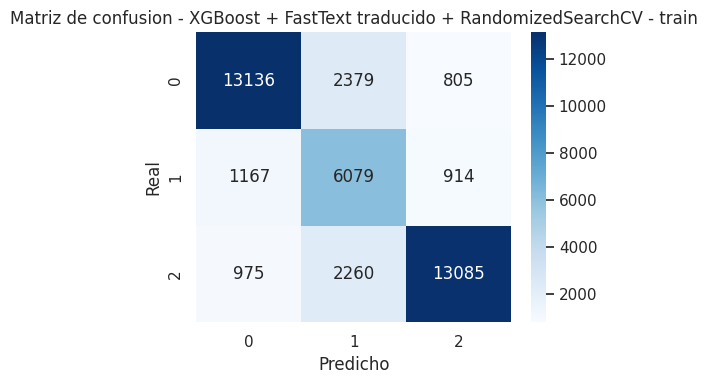


XGBoost + FastText traducido + RandomizedSearchCV - test
Accuracy : 0.682745
F1 macro : 0.648125

Classification report:
              precision    recall  f1-score   support

           0     0.7741    0.7240    0.7482      4080
           1     0.3731    0.4877    0.4228      2040
           2     0.8111    0.7390    0.7734      4080

    accuracy                         0.6827     10200
   macro avg     0.6528    0.6502    0.6481     10200
weighted avg     0.7087    0.6827    0.6932     10200



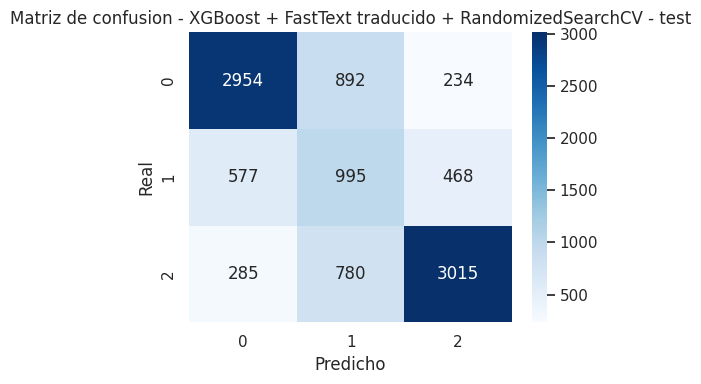


Brecha F1 macro train-test: 0.123976
Posible overfitting: la brecha de F1 macro supera 0.08.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV,0.803973,0.663796,0.823725,0.704020,0.140176,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_es_traducido_random_search.joblib
2,XGBoost + SentenceTransformer multilingue + RandomizedSearchCV,0.784732,0.658396,0.806103,0.698333,0.126336,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib
3,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo,0.754461,0.657558,0.775931,0.691078,0.096902,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib
4,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
5,XGBoost + Bag of Words + RandomizedSearchCV + balanceo,0.750317,0.652906,0.771152,0.685000,0.097412,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_balanceo.joblib
6,XGBoost + FastText + RandomizedSearchCV,0.771292,0.648305,0.791029,0.683431,0.122987,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_fasttext_random_search.joblib
7,XGBoost + FastText traducido + RandomizedSearchCV,0.772102,0.648125,0.791667,0.682745,0.123976,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_fasttext_traducido_random_search.joblib
8,XGBoost + FastText traducido + RandomizedSearchCV,0.772102,0.648125,0.791667,0.682745,0.123976,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelo

{'experimento': 'XGBoost + FastText traducido + RandomizedSearchCV',
 'f1_macro_train': 0.7721017811921905,
 'f1_macro_test': 0.6481253053829207,
 'accuracy_train': 0.7916666666666666,
 'accuracy_test': 0.6827450980392157,
 'brecha_f1_train_test': 0.12397647580926985,
 'mejores_parametros': {'subsample': 0.7,
  'reg_lambda': 1.0,
  'reg_alpha': 1.0,
  'n_estimators': 300,
  'min_child_weight': 5,
  'max_depth': 4,
  'learning_rate': 0.1,
  'gamma': 0.1,
  'colsample_bytree': 0.7},
 'ruta_modelo': 'modelosXGBoost/xgboost_fasttext_traducido_random_search.joblib'}

In [ ]:
# Usamos dataset traducido
X_train_ft_traducido_textos = X_train_traducido
X_test_ft_traducido_textos = X_test_traducido
y_train_ft_traducido = y_train_traducido
y_test_ft_traducido = y_test_traducido


def tokenizar_para_fasttext(texto):
    texto_limpio = limpiar_texto(texto)
    return texto_limpio.split()


tokens_train_ft_traducido = [
    tokenizar_para_fasttext(texto)
    for texto in tqdm(X_train_ft_traducido_textos)
]

tokens_test_ft_traducido = [
    tokenizar_para_fasttext(texto)
    for texto in tqdm(X_test_ft_traducido_textos)
]
RUTA_FASTTEXT_TRADUCIDO = MODELOS_DIR / "fasttext_entrenado_traducido.model"

if RUTA_FASTTEXT_TRADUCIDO.exists():
    print("Cargando FastText traducido existente...")
    modelo_fasttext_traducido = FastText.load(str(RUTA_FASTTEXT_TRADUCIDO))
else:
    print("Entrenando FastText con textos traducidos...")
    modelo_fasttext_traducido = FastText(
        sentences=tokens_train_ft_traducido,
        vector_size=300,
        window=5,
        min_count=2,
        workers=6,
        sg=1,
        epochs=20,
        seed=RANDOM_STATE,
    )
    modelo_fasttext_traducido.save(str(RUTA_FASTTEXT_TRADUCIDO))
    print("FastText traducido guardado.")

def vectorizar_texto_fasttext(tokens, modelo_fasttext):
    vectores = []

    for palabra in tokens:
        try:
            vectores.append(modelo_fasttext.wv[palabra])
        except KeyError:
            pass

    if len(vectores) == 0:
        return np.zeros(modelo_fasttext.vector_size, dtype=np.float32)

    return np.mean(vectores, axis=0).astype(np.float32)

RUTA_X_TRAIN_FASTTEXT_TRADUCIDO = MODELOS_DIR / "X_train_fasttext_traducido.npy"
RUTA_X_TEST_FASTTEXT_TRADUCIDO = MODELOS_DIR / "X_test_fasttext_traducido.npy"

if RUTA_X_TRAIN_FASTTEXT_TRADUCIDO.exists() and RUTA_X_TEST_FASTTEXT_TRADUCIDO.exists():
    print("Cargando embeddings FastText traducidos desde disco...")
    X_train_fasttext_traducido = np.load(RUTA_X_TRAIN_FASTTEXT_TRADUCIDO)
    X_test_fasttext_traducido = np.load(RUTA_X_TEST_FASTTEXT_TRADUCIDO)
else:
    print("Generando embeddings FastText traducidos para train...")
    X_train_fasttext_traducido = np.vstack([
        vectorizar_texto_fasttext(tokens, modelo_fasttext_traducido)
        for tokens in tqdm(tokens_train_ft_traducido)
    ])

    print("Generando embeddings FastText traducidos para test...")
    X_test_fasttext_traducido = np.vstack([
        vectorizar_texto_fasttext(tokens, modelo_fasttext_traducido)
        for tokens in tqdm(tokens_test_ft_traducido)
    ])

    np.save(RUTA_X_TRAIN_FASTTEXT_TRADUCIDO, X_train_fasttext_traducido)
    np.save(RUTA_X_TEST_FASTTEXT_TRADUCIDO, X_test_fasttext_traducido)

print(X_train_fasttext_traducido.shape)
print(X_test_fasttext_traducido.shape)

params_xgb_fasttext_traducido_search = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

sample_weight_fasttext_traducido = compute_sample_weight(
    class_weight="balanced",
    y=y_train_ft_traducido,
)

search_xgb_fasttext_traducido = RandomizedSearchCV(
    estimator=crear_xgb_base(),
    param_distributions=params_xgb_fasttext_traducido_search,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring=SCORING,
    cv=CV,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=6,
)

RUTA_XGB_FASTTEXT_TRADUCIDO_SEARCH = (
    MODELOS_DIR / "xgboost_fasttext_traducido_random_search.joblib"
)

def entrenar_xgb_fasttext_traducido_search():
    search_xgb_fasttext_traducido.fit(
        X_train_fasttext_traducido,
        y_train_ft_traducido,
        sample_weight=sample_weight_fasttext_traducido,
    )
    return search_xgb_fasttext_traducido


modelo_xgb_fasttext_traducido_search = guardar_o_cargar_modelo(
    RUTA_XGB_FASTTEXT_TRADUCIDO_SEARCH,
    entrenar_xgb_fasttext_traducido_search,
)

print("Mejores parámetros:")
print(modelo_xgb_fasttext_traducido_search.best_params_)

print("Mejor score CV:")
print(modelo_xgb_fasttext_traducido_search.best_score_)

metricas_train, metricas_test = evaluar_modelo(
    "XGBoost + FastText traducido + RandomizedSearchCV",
    modelo_xgb_fasttext_traducido_search,
    X_train_fasttext_traducido,
    X_test_fasttext_traducido,
    y_train_ft_traducido,
    y_test_ft_traducido,
)

registrar_resultado(
    "XGBoost + FastText traducido + RandomizedSearchCV",
    modelo_xgb_fasttext_traducido_search,
    RUTA_XGB_FASTTEXT_TRADUCIDO_SEARCH,
    metricas_train,
    metricas_test,
    mejores_parametros=modelo_xgb_fasttext_traducido_search.best_params_,
)


### Experimento F: XGBoost + SentenceTransformer Multilingual + sample weight + RandomizedSearchCV

En este experimento se generan embeddings con un modelo `SentenceTransformer` multilingual. Luego se entrena un clasificador XGBoost usando `sample_weight` para balancear clases y `RandomizedSearchCV` para buscar mejores hiperparámetros, optimizando `f1_macro`.

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Cargando embeddings SentenceTransformer desde disco...
(40800, 384)
(10200, 384)
Cargando modelo existente: modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib
Cargando modelo existente: modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib

XGBoost + SentenceTransformer multilingue + RandomizedSearchCV - train
Accuracy : 0.806103
F1 macro : 0.784732

Classification report:
              precision    recall  f1-score   support

           0     0.8635    0.8303    0.8466     16320
           1     0.5897    0.7335    0.6538      8160
           2     0.8927    0.8182    0.8538     16320

    accuracy                         0.8061     40800
   macro avg     0.7820    0.7940    0.7847     40800
weighted avg     0.8204    0.8061    0.8109     40800



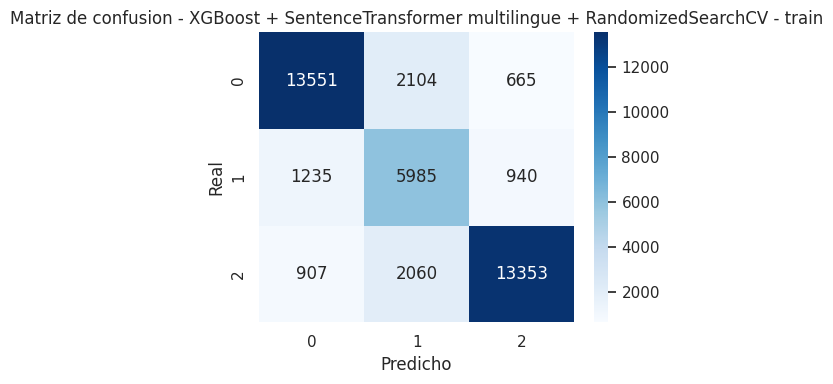


XGBoost + SentenceTransformer multilingue + RandomizedSearchCV - test
Accuracy : 0.698333
F1 macro : 0.658396

Classification report:
              precision    recall  f1-score   support

           0     0.7701    0.7473    0.7586      4080
           1     0.3857    0.4647    0.4215      2040
           2     0.8263    0.7662    0.7951      4080

    accuracy                         0.6983     10200
   macro avg     0.6607    0.6594    0.6584     10200
weighted avg     0.7157    0.6983    0.7058     10200



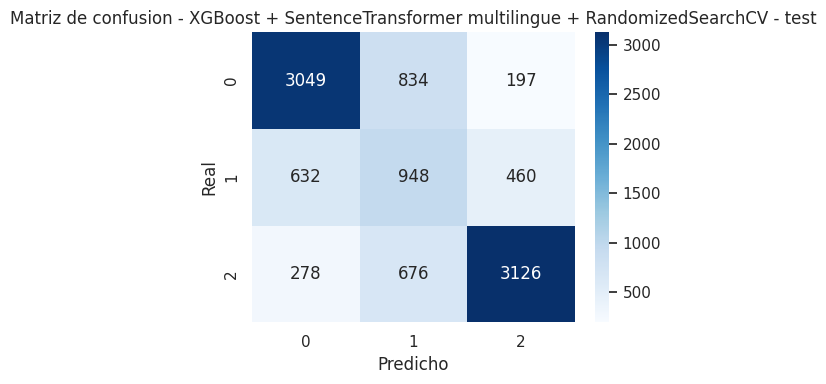


Brecha F1 macro train-test: 0.126336
Posible overfitting: la brecha de F1 macro supera 0.08.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV,0.803973,0.663796,0.823725,0.704020,0.140176,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_es_traducido_random_search.joblib
2,XGBoost + SentenceTransformer multilingue + RandomizedSearchCV,0.784732,0.658396,0.806103,0.698333,0.126336,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib
3,XGBoost + SentenceTransformer multilingue + RandomizedSearchCV,0.784732,0.658396,0.806103,0.698333,0.126336,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib
4,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo,0.754461,0.657558,0.775931,0.691078,0.096902,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib
5,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
6,XGBoost + Bag of Words + RandomizedSearchCV + balanceo,0.750317,0.652906,0.771152,0.685000,0.097412,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_balanceo.joblib
7,XGBoost + FastText + RandomizedSearchCV,0.771292,0.648305,0.791029,0.683431,0.122987,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_fasttext_random_search.joblib
8,XGBoost + FastText traducido + RandomizedSearchCV,0.772102,0.648125,0.791667,0.682745,0.123976,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'cols

{'experimento': 'XGBoost + SentenceTransformer multilingue + RandomizedSearchCV',
 'f1_macro_train': 0.7847324578207587,
 'f1_macro_test': 0.6583963674560855,
 'accuracy_train': 0.8061029411764706,
 'accuracy_test': 0.6983333333333334,
 'brecha_f1_train_test': 0.1263360903646732,
 'mejores_parametros': {'subsample': 0.7,
  'reg_lambda': 1.0,
  'reg_alpha': 1.0,
  'n_estimators': 300,
  'min_child_weight': 5,
  'max_depth': 4,
  'learning_rate': 0.1,
  'gamma': 0.1,
  'colsample_bytree': 0.7},
 'ruta_modelo': 'modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib'}

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

MODELO_SENTENCE_TRANSFORMER = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

X_train_st_textos = X_train.astype(str).tolist()
X_test_st_textos = X_test.astype(str).tolist()

y_train_st = y_train
y_test_st = y_test

RUTA_X_TRAIN_ST = MODELOS_DIR / "X_train_sentence_transformer_multilingue.npy"
RUTA_X_TEST_ST = MODELOS_DIR / "X_test_sentence_transformer_multilingue.npy"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

modelo_st = SentenceTransformer(MODELO_SENTENCE_TRANSFORMER, device=device)

if RUTA_X_TRAIN_ST.exists() and RUTA_X_TEST_ST.exists():
    print("Cargando embeddings SentenceTransformer desde disco...")
    X_train_st = np.load(RUTA_X_TRAIN_ST)
    X_test_st = np.load(RUTA_X_TEST_ST)
else:
    print("Generando embeddings SentenceTransformer para train...")

    X_train_st = modelo_st.encode(
        X_train_st_textos,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")

    print("Generando embeddings SentenceTransformer para test...")

    X_test_st = modelo_st.encode(
        X_test_st_textos,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")

    np.save(RUTA_X_TRAIN_ST, X_train_st)
    np.save(RUTA_X_TEST_ST, X_test_st)

print(X_train_st.shape)
print(X_test_st.shape)

sample_weight_st = compute_sample_weight(
    class_weight="balanced",
    y=y_train_st,
)

params_xgb_st_search = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search_xgb_st = RandomizedSearchCV(
    estimator=crear_xgb_base(),
    param_distributions=params_xgb_st_search,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring=SCORING,
    cv=CV,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=6,
)

RUTA_XGB_ST_SEARCH = MODELOS_DIR / "xgboost_sentence_transformer_multilingue_random_search.joblib"

def entrenar_xgb_sentence_transformer_search():
    search_xgb_st.fit(
        X_train_st,
        y_train_st,
        sample_weight=sample_weight_st,
    )
    return search_xgb_st

modelo_xgb_st_search = guardar_o_cargar_modelo(
    RUTA_XGB_ST_SEARCH,
    entrenar_xgb_sentence_transformer_search,
)

RUTA_XGB_ST_SEARCH = MODELOS_DIR / "xgboost_sentence_transformer_multilingue_random_search.joblib"

def entrenar_xgb_sentence_transformer_search():
    search_xgb_st.fit(
        X_train_st,
        y_train_st,
        sample_weight=sample_weight_st,
    )
    return search_xgb_st

modelo_xgb_st_search = guardar_o_cargar_modelo(
    RUTA_XGB_ST_SEARCH,
    entrenar_xgb_sentence_transformer_search,
)
metricas_train, metricas_test = evaluar_modelo(
    "XGBoost + SentenceTransformer multilingue + RandomizedSearchCV",
    modelo_xgb_st_search,
    X_train_st,
    X_test_st,
    y_train_st,
    y_test_st,
)

registrar_resultado(
    "XGBoost + SentenceTransformer multilingue + RandomizedSearchCV",
    modelo_xgb_st_search,
    RUTA_XGB_ST_SEARCH,
    metricas_train,
    metricas_test,
    mejores_parametros=modelo_xgb_st_search.best_params_,
)

### Experimento G: XGBoost + SentenceTransformer español + textos traducidos + sample weight + RandomizedSearchCV

En este experimento se utilizan los textos traducidos al español y se generan embeddings con un modelo `SentenceTransformer` orientado a español. Luego se entrena un clasificador XGBoost usando `sample_weight` para balancear clases y `RandomizedSearchCV` para buscar mejores hiperparámetros, optimizando `f1_macro`.

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Cargando embeddings SentenceTransformer español desde disco...
(40800, 768)
(10200, 768)
Cargando modelo existente: modelosXGBoost/xgboost_sentence_transformer_es_traducido_random_search.joblib
Mejores parámetros:
{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Mejor score CV:
0.6519351417457272

XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV - train
Accuracy : 0.823725
F1 macro : 0.803973

Classification report:
              precision    recall  f1-score   support

           0     0.8847    0.8458    0.8648     16320
           1     0.6121    0.7691    0.6817      8160
           2     0.9053    0.8289    0.8654     16320

    accuracy                         0.8237     40800
   macro avg     0.8007    0.8146    0.8040     40800
weighted avg     0.8384    0.8237    0.8284     40800



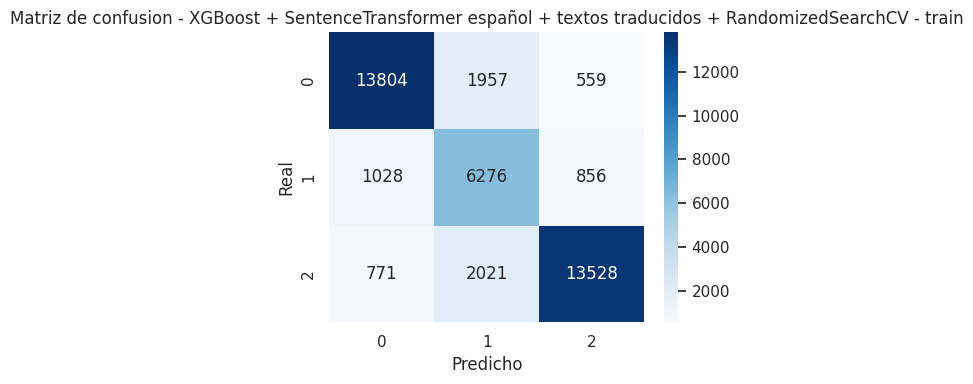


XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV - test
Accuracy : 0.704020
F1 macro : 0.663796

Classification report:
              precision    recall  f1-score   support

           0     0.7786    0.7620    0.7702      4080
           1     0.3874    0.4686    0.4241      2040
           2     0.8334    0.7637    0.7970      4080

    accuracy                         0.7040     10200
   macro avg     0.6664    0.6648    0.6638     10200
weighted avg     0.7223    0.7040    0.7117     10200



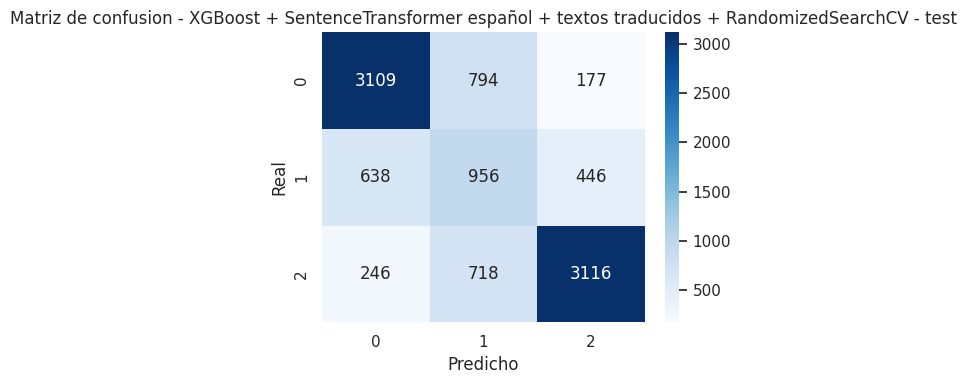


Brecha F1 macro train-test: 0.140176
Posible overfitting: la brecha de F1 macro supera 0.08.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV,0.803973,0.663796,0.823725,0.704020,0.140176,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_es_traducido_random_search.joblib
2,XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV,0.803973,0.663796,0.823725,0.704020,0.140176,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_es_traducido_random_search.joblib
3,XGBoost + SentenceTransformer multilingue + RandomizedSearchCV,0.784732,0.658396,0.806103,0.698333,0.126336,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib
4,XGBoost + SentenceTransformer multilingue + RandomizedSearchCV,0.784732,0.658396,0.806103,0.698333,0.126336,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib
5,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo,0.754461,0.657558,0.775931,0.691078,0.096902,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib
6,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
7,XGBoost + Bag of Words + RandomizedSearchCV + balanceo,0.750317,0.652906,0.771152,0.685000,0.097412,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_balanceo.joblib
8,XGBoost + FastText + RandomizedSearchCV,0.771292,0.648305,0.791029,0.683431,0.122987,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'ma

{'experimento': 'XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV',
 'f1_macro_train': 0.8039727473964634,
 'f1_macro_test': 0.6637964889121956,
 'accuracy_train': 0.8237254901960784,
 'accuracy_test': 0.7040196078431372,
 'brecha_f1_train_test': 0.14017625848426785,
 'mejores_parametros': {'subsample': 0.7,
  'reg_lambda': 1.0,
  'reg_alpha': 1.0,
  'n_estimators': 300,
  'min_child_weight': 5,
  'max_depth': 4,
  'learning_rate': 0.1,
  'gamma': 0.1,
  'colsample_bytree': 0.7},
 'ruta_modelo': 'modelosXGBoost/xgboost_sentence_transformer_es_traducido_random_search.joblib'}

In [ ]:
# Modelo SentenceTransformer orientado a español
MODELO_SENTENCE_TRANSFORMER_ES = "hiiamsid/sentence_similarity_spanish_es"

# Usamos los textos traducidos
X_train_st_es_textos = X_train_traducido.astype(str).tolist()
X_test_st_es_textos = X_test_traducido.astype(str).tolist()

y_train_st_es = y_train_traducido
y_test_st_es = y_test_traducido

# Rutas distintas
RUTA_X_TRAIN_ST_ES = MODELOS_DIR / "X_train_sentence_transformer_es_traducido.npy"
RUTA_X_TEST_ST_ES = MODELOS_DIR / "X_test_sentence_transformer_es_traducido.npy"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

modelo_st_es = SentenceTransformer(
    MODELO_SENTENCE_TRANSFORMER_ES,
    device=device
)

batch_size = 128 if device == "cuda" else 32

if RUTA_X_TRAIN_ST_ES.exists() and RUTA_X_TEST_ST_ES.exists():
    print("Cargando embeddings SentenceTransformer español desde disco...")
    X_train_st_es = np.load(RUTA_X_TRAIN_ST_ES)
    X_test_st_es = np.load(RUTA_X_TEST_ST_ES)
else:
    print("Generando embeddings SentenceTransformer español para train...")

    X_train_st_es = modelo_st_es.encode(
        X_train_st_es_textos,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")

    print("Generando embeddings SentenceTransformer español para test...")

    X_test_st_es = modelo_st_es.encode(
        X_test_st_es_textos,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")

    np.save(RUTA_X_TRAIN_ST_ES, X_train_st_es)
    np.save(RUTA_X_TEST_ST_ES, X_test_st_es)

print(X_train_st_es.shape)
print(X_test_st_es.shape)

sample_weight_st_es = compute_sample_weight(
    class_weight="balanced",
    y=y_train_st_es,
)

params_xgb_st_es_search = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search_xgb_st_es = RandomizedSearchCV(
    estimator=crear_xgb_base(),
    param_distributions=params_xgb_st_es_search,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring=SCORING,
    cv=CV,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=6,
)

RUTA_XGB_ST_ES_SEARCH = MODELOS_DIR / "xgboost_sentence_transformer_es_traducido_random_search.joblib"

def entrenar_xgb_sentence_transformer_es_search():
    search_xgb_st_es.fit(
        X_train_st_es,
        y_train_st_es,
        sample_weight=sample_weight_st_es,
    )
    return search_xgb_st_es

modelo_xgb_st_es_search = guardar_o_cargar_modelo(
    RUTA_XGB_ST_ES_SEARCH,
    entrenar_xgb_sentence_transformer_es_search,
)

print("Mejores parámetros:")
print(modelo_xgb_st_es_search.best_params_)

print("Mejor score CV:")
print(modelo_xgb_st_es_search.best_score_)

metricas_train, metricas_test = evaluar_modelo(
    "XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV",
    modelo_xgb_st_es_search,
    X_train_st_es,
    X_test_st_es,
    y_train_st_es,
    y_test_st_es,
)

registrar_resultado(
    "XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV",
    modelo_xgb_st_es_search,
    RUTA_XGB_ST_ES_SEARCH,
    metricas_train,
    metricas_test,
    mejores_parametros=modelo_xgb_st_es_search.best_params_,
)

### Ranking final

Se ordenan todos los experimentos ejecutados por `f1_macro_test` de mayor a menor.


,experimento,f1_macro_train,f1_macro_test,accuracy_train,accuracy_test,brecha_f1_train_test,mejores_parametros,ruta_modelo
0,XGBoost + TF-IDF + RandomizedSearchCV + balanceo,0.780286,0.665027,0.800319,0.699510,0.115259,"{'tfidf__sublinear_tf': True, 'tfidf__strip_accents': 'unicode', 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 2, 'tfidf__max_features': 20000, 'tfidf__max_df': 0.8, 'clf__subsample': 0.8, 'clf__reg_lambda': 5.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 3, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.9}",modelosXGBoost/xgboost_tfidf_random_search_balanceo.joblib
1,XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV,0.803973,0.663796,0.823725,0.704020,0.140176,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_es_traducido_random_search.joblib
2,XGBoost + SentenceTransformer español + textos traducidos + RandomizedSearchCV,0.803973,0.663796,0.823725,0.704020,0.140176,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_es_traducido_random_search.joblib
3,XGBoost + SentenceTransformer multilingue + RandomizedSearchCV,0.784732,0.658396,0.806103,0.698333,0.126336,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib
4,XGBoost + SentenceTransformer multilingue + RandomizedSearchCV,0.784732,0.658396,0.806103,0.698333,0.126336,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}",modelosXGBoost/xgboost_sentence_transformer_multilingue_random_search.joblib
5,XGBoost + Bag of Words + RandomizedSearchCV + Traduccion + balanceo,0.754461,0.657558,0.775931,0.691078,0.096902,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_traduccion_balanceo.joblib
6,XGBoost + TF-IDF + limpieza + traduccion + RandomizedSearchCV + balanceo,0.709100,0.657336,0.733260,0.686373,0.051764,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_range': [1, 3], 'tfidf__min_df': 1, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.95, 'clf__subsample': 0.7, 'clf__reg_lambda': 1.0, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 500, 'clf__min_child_weight': 7, 'clf__max_depth': 3, 'clf__learning_rate': 0.1, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}",modelosXGBoost/xgboost_tfidf_limpieza_traduccion_random_search_balanceo.joblib
7,XGBoost + Bag of Words + RandomizedSearchCV + balanceo,0.750317,0.652906,0.771152,0.685000,0.097412,"{'clf__subsample': 0.8, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.9, 'bow__strip_accents': 'unicode', 'bow__ngram_range': [1, 3], 'bow__min_df': 5, 'bow__max_features': 5000, 'bow__max_df': 0.95, 'bow__binary': False}",modelosXGBoost/xgboost_bow_random_search_balanceo.joblib
8,XGBoost + FastText + RandomizedSearchCV,0.771292,0.648305,0.791029,0.683431,0.122987,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'ma

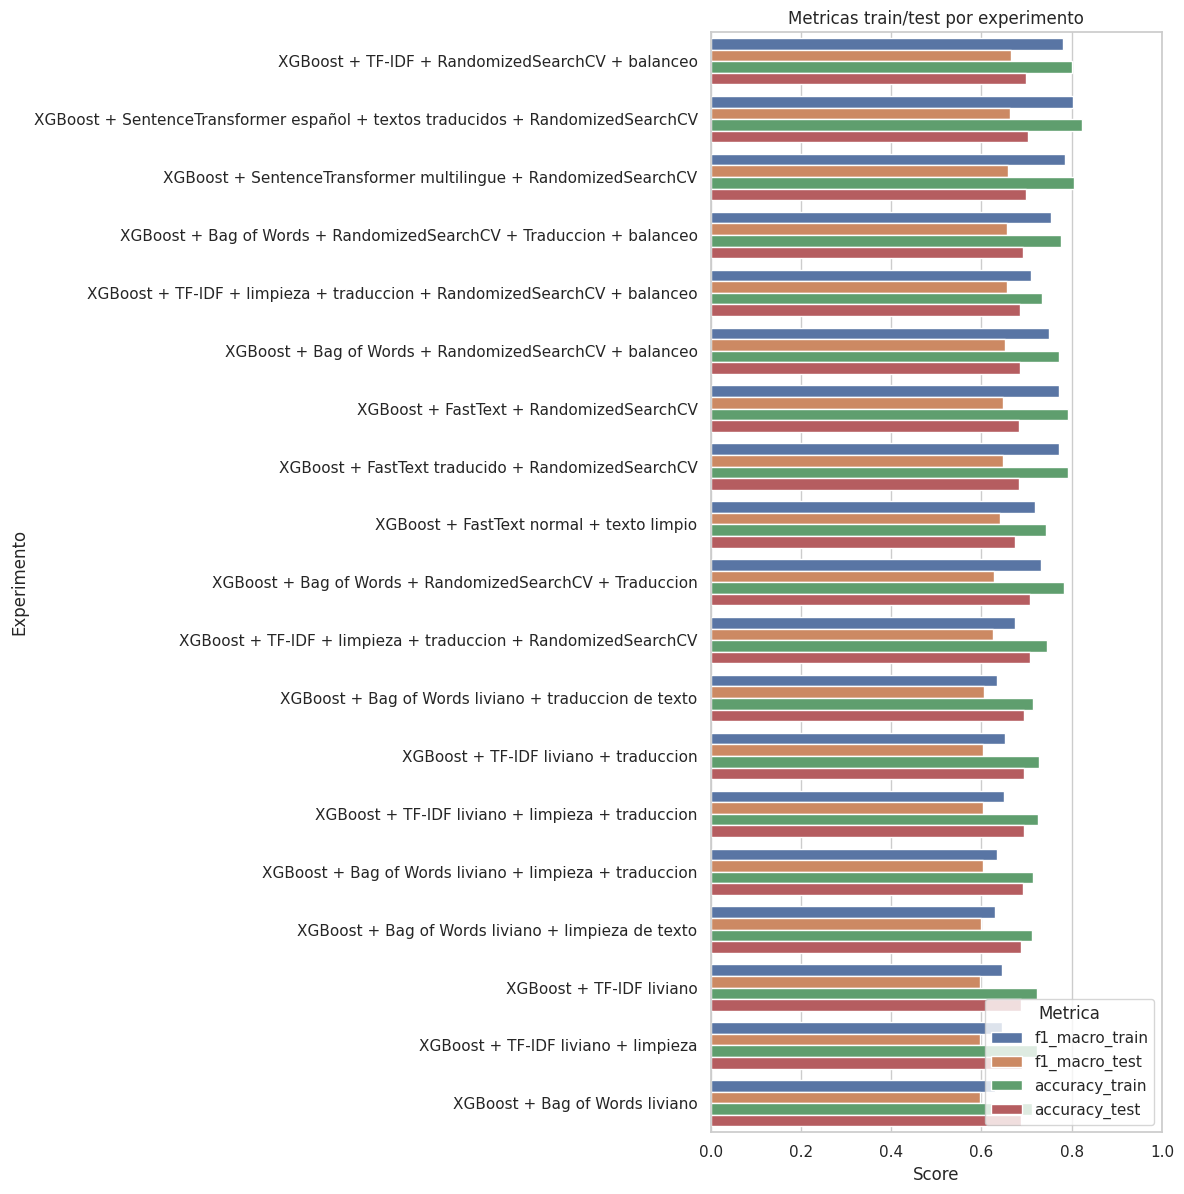

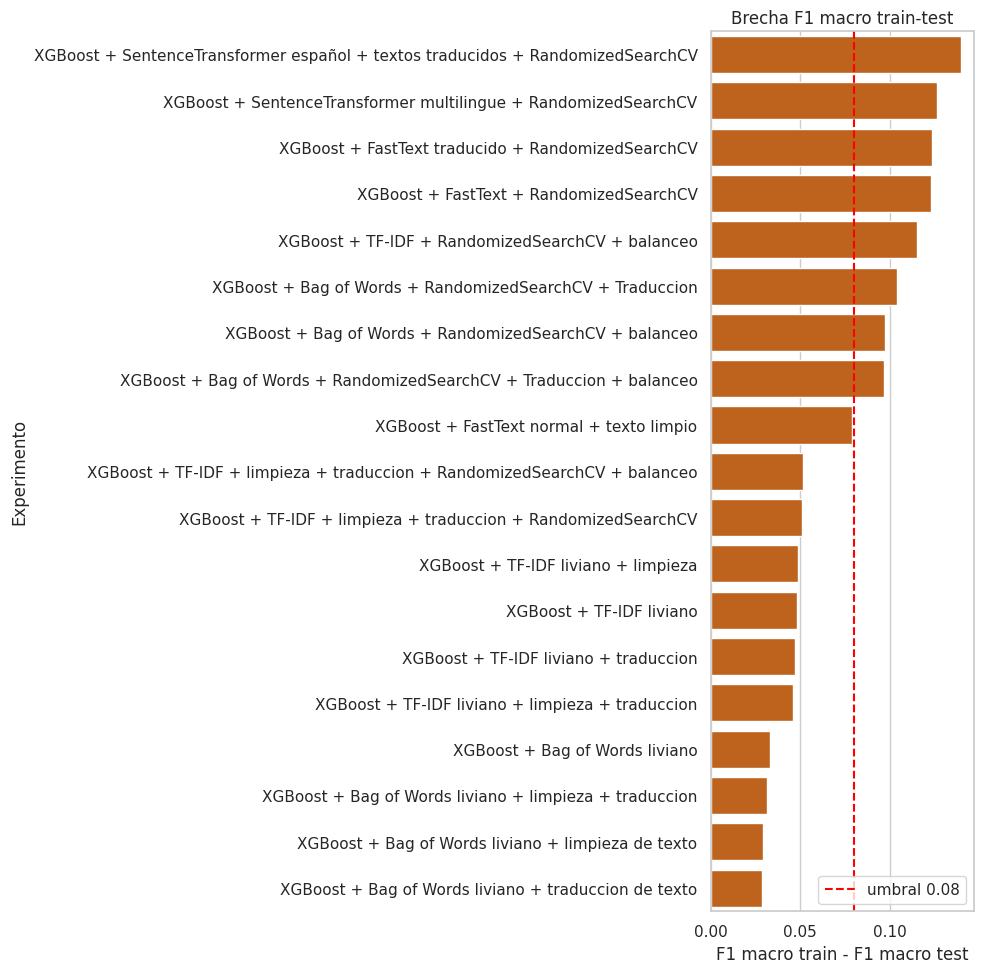

Mejor experimento: XGBoost + TF-IDF + RandomizedSearchCV + balanceo
Mejor F1 macro test: 0.665027
Accuracy test: 0.699510
Modelo final guardado en: modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib
Mejores parametros:


{'tfidf__sublinear_tf': True,
 'tfidf__strip_accents': 'unicode',
 'tfidf__ngram_range': [1, 3],
 'tfidf__min_df': 2,
 'tfidf__max_features': 20000,
 'tfidf__max_df': 0.8,
 'clf__subsample': 0.8,
 'clf__reg_lambda': 5.0,
 'clf__reg_alpha': 0.01,
 'clf__n_estimators': 500,
 'clf__min_child_weight': 3,
 'clf__max_depth': 4,
 'clf__learning_rate': 0.2,
 'clf__gamma': 0.1,
 'clf__colsample_bytree': 0.9}

In [ ]:
ranking_final = guardar_resultados()
display(ranking_final)
graficar_ranking_metricas(ranking_final)

if mejor_resultado is not None:
    print("Mejor experimento:", mejor_resultado["experimento"])
    print(f"Mejor F1 macro test: {mejor_resultado['f1_macro_test']:.6f}")
    print(f"Accuracy test: {mejor_resultado['accuracy_test']:.6f}")
    print("Modelo final guardado en:", MEJOR_MODELO_PATH)
    print("Mejores parametros:")
    display(mejor_resultado.get("mejores_parametros"))
else:
    print("Todavia no hay resultados registrados.")


### Conclusión


In [ ]:
if mejor_resultado is None:
    print("No hay modelos evaluados todavia.")
else:
    print(f"Mejor experimento: {mejor_resultado['experimento']}")
    print(f"Mejor F1 macro en test: {mejor_resultado['f1_macro_test']:.6f}")
    print(f"Mejor accuracy en test: {mejor_resultado['accuracy_test']:.6f}")
    print(f"Ruta del mejor modelo: {MEJOR_MODELO_PATH}")
    print("Mejores parametros si corresponde:")
    print(json.dumps(mejor_resultado.get("mejores_parametros"), indent=2, ensure_ascii=False))


Mejor experimento: XGBoost + TF-IDF + RandomizedSearchCV + balanceo
Mejor F1 macro en test: 0.665027
Mejor accuracy en test: 0.699510
Ruta del mejor modelo: modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib
Mejores parametros si corresponde:
{
  "tfidf__sublinear_tf": true,
  "tfidf__strip_accents": "unicode",
  "tfidf__ngram_range": [
    1,
    3
  ],
  "tfidf__min_df": 2,
  "tfidf__max_features": 20000,
  "tfidf__max_df": 0.8,
  "clf__subsample": 0.8,
  "clf__reg_lambda": 5.0,
  "clf__reg_alpha": 0.01,
  "clf__n_estimators": 500,
  "clf__min_child_weight": 3,
  "clf__max_depth": 4,
  "clf__learning_rate": 0.2,
  "clf__gamma": 0.1,
  "clf__colsample_bytree": 0.9
}


### Prediccion final sobre test.csv

Genera el archivo de submission usando el mejor modelo guardado por la notebook.

In [ ]:

# from pathlib import Path

# import joblib
# import pandas as pd

# TEST_PATH = Path("test.csv")
# MODELO_PATH = Path("modelosXGBoost/mejor_modelo_f1_macro_xgboost.joblib")
# SUBMISSION_PATH = Path("submission_xgboost_mejor_modelo.csv")

# pruebas_df = pd.read_csv(TEST_PATH)
# if {"id", "text"} - set(pruebas_df.columns):
# modelo_xgb = joblib.load(MODELO_PATH)
# predicciones = modelo_xgb.predict(pruebas_df["text"].astype(str))

# submission = pd.DataFrame({
#     "id": pruebas_df["id"],
#     "label": predicciones.astype(int),
# })
# submission.to_csv(SUBMISSION_PATH, index=False)

# print(f"Archivo generado correctamente: {SUBMISSION_PATH}")
# display(submission.head())

##Redes neuronales

### Justificación de la elección de BETO

Los modelos clásicos basados en *bag of words* (Naïve Bayes, Random Forest, XGBoost) procesan el texto como un conjunto de palabras: el peso de cada término es independiente de su posición y de su contexto. Es evidente que la aparición de conectores como "pero" o "aunque" o reseñas que tienen un contenido mixto hacen necesario que se deba ponderar cuanto pesa cada cosa de acuerdo a su contexto.

Para validar esta hipótesis antes del modelado con redes neuronales, exploramos cuánto pesan este tipo de reseñas en los errores de los modelos clásicos.

In [ ]:
import re
import numpy as np
import joblib

textos = df['text'].fillna('').astype(str).values
y = df['label'].values

#Buscamos los conectores típicos
re_pero = re.compile(r'(?:\bpero\b|\baunque\b|sin embargo|no obstante|si bien|aun así)', re.I)
tiene_pero = np.array([bool(re_pero.search(t)) for t in textos])

print(f"=== Reseñas con 'pero', 'aunque' o similares ===")
print(f"Total con 'pero/aunque': {tiene_pero.sum()} ({tiene_pero.mean():.1%} del dataset)")

# Usamos como modelo de referencia clásico un XGBOOST entrenado en una de las pruebas
proba_xgb_tfidf = joblib.load('modelos/y_proba_oof_xgb_tfidf_peso20.joblib')
y_pred = proba_xgb_tfidf.argmax(axis=1)
errores = (y_pred != y)

print(f"\n=== Tasa de error del modelo clásico (XGBoost + TF-IDF) ===")
print(f"En reseñas SIN 'pero/aunque': {errores[~tiene_pero].mean():.1%}")
print(f"En reseñas CON 'pero/aunque': {errores[tiene_pero].mean():.1%}")
print(f"→ El error casi se duplica en reseñas con 'pero/aunque'.")

print(f"\n=== Composición de los errores ===")
print(f"De los {errores.sum()} errores totales del modelo:")
print(f"  {errores[tiene_pero].sum()} ({errores[tiene_pero].sum()/errores.sum():.1%}) son reseñas con 'pero/aunque'")
print(f"  (estas reseñas son solo el {tiene_pero.mean():.1%} del dataset, pero acumulan casi la mitad de los errores)")

involucra_neutro = ((y == 1) | (y_pred == 1)) & errores
print(f"\n=== Rol de la clase neutra ===")
print(f"{involucra_neutro.sum()} de {errores.sum()} errores ({involucra_neutro.sum()/errores.sum():.1%}) involucran la clase 1 (neutro)")

print(f"\n=== Tasa de error por clase real ===")
print(f"{'Clase':<15}{'Sin pero/aunque':<22}{'Con pero/aunque':<22}")
nombres = {0: 'Negativa (0)', 1: 'Neutra (1)', 2: 'Positiva (2)'}
for clase in [0, 1, 2]:
    mask = (y == clase)
    err_sin = errores[mask & ~tiene_pero].mean()
    err_con = errores[mask & tiene_pero].mean()
    print(f"{nombres[clase]:<15}{err_sin:>6.1%}{'':<16}{err_con:>6.1%}")

=== Reseñas con 'pero', 'aunque' o similares ===
Total con 'pero/aunque': 15868 (31.1% del dataset)

=== Tasa de error del modelo clásico (XGBoost + TF-IDF) ===
En reseñas SIN 'pero/aunque': 26.4%
En reseñas CON 'pero/aunque': 45.0%
→ El error casi se duplica en reseñas con 'pero/aunque'.

=== Composición de los errores ===
De los 16423 errores totales del modelo:
  7145 (43.5%) son reseñas con 'pero/aunque'
  (estas reseñas son solo el 31.1% del dataset, pero acumulan casi la mitad de los errores)

=== Rol de la clase neutra ===
13081 de 16423 errores (79.7%) involucran la clase 1 (neutro)

=== Tasa de error por clase real ===
Clase          Sin pero/aunque       Con pero/aunque       
Negativa (0)    20.4%                 47.2%
Neutra (1)      72.1%                 29.5%
Positiva (2)    16.3%                 57.9%


**Conclusiones del análisis**:

1. Las reseñas con conectores de "contraste" son el 31% del dataset pero acumulan el 45% de los errores del modelo clásico, es decir, están sobre representadas en los fallos.
2. La tasa de error se duplica en reseñas con estos conectores (26% vs 45%).
3. La clase 1 (neutro) está involucrada en el 79,7% de los errores: los modelos clásicos confunden "neutro" con los extremos justo en reseñas con sentimiento mixto, no pueden determinar cual es el factor que más pesa antes y después del conector, por ejemplo: "buen producto aunque llegó muy tarde".
4. La asimetría por clase es clave: el "pero" empeora la clasificación de las clases extremas (buenas o malas) pero mejora la clase 1 (de 72,1% a 29,5%). Esto sugiere que el modelo clásico interpreta el "pero" como señal de neutralidad, lo cual es correcto cuando la reseña es realmente neutra pero erróneo cuando la reseña es mixta con opinión dominante hacia un extremo (el modelo no puede darse cuenta hacia donde se decanta la reseña).

Esta evidencia motiva el uso de un modelo que pueda leer la estructura secuencial de la oración y ponderar diferencialmente las partes antes y después del conector. Los transformers, mediante su mecanismo de atención, satisfacen esta necesidad: cada token atiende diferencialmente a los demás según el contexto, lo que captura conectores de contraste, negaciones y matices que las representaciones planas no expresan.

Se eligió específicamente BETO siguiendo con la sugerencia de la cátedra principalmente porque es un modelo pre-entrenado específicamente en español

### Arquitectura

**BETO** es una versión de esta arquitectura entrenada específicamente en español (aproximadamente 3.000 millones de palabras de Wikipedia y libros). Por defecto, BETO no clasifica nada — solo produce una representación numérica del texto. Para usarlo en este problema:

1. Le pasamos el texto de la reseña.
2. BETO lo procesa internamente y produce un vector numérico que resume la oración.
3. Agregamos sobre esa salida una **capa lineal de clasificación** que mapea ese vector a 3 valores, uno por clase (negativa, neutra, positiva). Esta capa se agrega automáticamente al instanciar el modelo con `num_labels=3` en HuggingFace Transformers.
4. Aplicamos softmax sobre esos 3 valores para obtener probabilidades.

Durante el fine-tuning, **todos los parámetros se actualizan**: tanto los de BETO (que se especializan al dominio de reseñas) como los de la capa de clasificación (que aprende qué representaciones corresponden a cada clase).

```
"buen producto pero llegó tarde"
           ↓
        BETO (procesa el texto considerando contexto)
           ↓
       vector resumen del texto
           ↓
  capa de clasificación + softmax
           ↓
P(negativa) = 0.30   P(neutra) = 0.55   P(positiva) = 0.15
```

**Lo que esto resuelve respecto a los modelos clásicos**: en el análisis previo vimos que la tasa de error del modelo clásico salta casi al doble cuando aparece un "pero". Los transformers no garantizan acertar siempre en estos casos —al final, algunos son intrínsecamente ambiguos—, pero sí atacan la causa: la incapacidad de los modelos clásicos para ponderar palabras según el contexto.

### Carga de modelos guardados en memoria (si se omite este paso reentrenará los modelos)

In [ ]:
CARPETA_MODELOS = 'modelos'
os.makedirs(CARPETA_MODELOS, exist_ok=True)

USAR_MODELOS_CACHEADOS = len(os.listdir(CARPETA_MODELOS)) > 0

###Setup

Hacemos 80% para entrenamiento y 20% para test

In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

Setup del modelo:

In [ ]:
import torch
import numpy as np
import pandas as pd
import os
import joblib
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed)
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Configuración del modelo
MODELO_BETO = 'dccuchile/bert-base-spanish-wwm-uncased'
MAX_LENGTH = 128
EPOCHS = 3
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
SEED = 42

set_seed(SEED)

tokenizer = AutoTokenizer.from_pretrained(MODELO_BETO)

class ReviewDataset(Dataset):
    def __init__(self, textos, etiquetas, tokenizer, max_length=128):
        self.textos = list(textos)
        self.etiquetas = list(etiquetas) if etiquetas is not None else None
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.textos[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.etiquetas is not None:
            item['labels'] = torch.tensor(self.etiquetas[idx], dtype=torch.long)
        return item

print(f"\nSetup completo. Modelo: {MODELO_BETO}")


Setup completo. Modelo: dccuchile/bert-base-spanish-wwm-uncased


### Hiperparámetros y búsqueda

BETO tiene varios hiperparámetros que afectan el fine-tuning. Se priorizan los dos más sensibles: learning rate y épocas, y se fijan los demás en valores estándar.

**Grilla explorada**:

- `learning_rate`: 0.00001, 0.00002, 0.00005
- `epochs`: 2, 3

Total: 6 combinaciones, evaluadas por macro F1 sobre un split de validación del 10% del train

In [ ]:
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

ruta_busqueda = 'modelos/busqueda_beto.joblib'

if USAR_MODELOS_CACHEADOS and os.path.exists(ruta_busqueda):
    resultados_busqueda = joblib.load(ruta_busqueda)
    print("Resultados de búsqueda cargados desde disco.")
else:
    textos_full = df['text'].fillna('').astype(str).values
    y_full = df['label'].values
    X_tr, X_val, y_tr, y_val = train_test_split(
        textos_full, y_full, test_size=0.1,
        stratify=y_full, random_state=SEED
    )
    print(f"Split: {len(X_tr)} train, {len(X_val)} val")

    # Grilla: 3 learning rates × 2 epochs = 6 combinaciones
    configs = [
        {'lr': 1e-5, 'epochs': 2},
        {'lr': 1e-5, 'epochs': 3},
        {'lr': 2e-5, 'epochs': 2},
        {'lr': 2e-5, 'epochs': 3},
        {'lr': 3e-5, 'epochs': 2},
        {'lr': 3e-5, 'epochs': 3},
    ]

    resultados_busqueda = []

    for i, cfg in enumerate(configs, start=1):
        print(f"\n{'='*60}")
        print(f"Configuración {i}/{len(configs)}: lr={cfg['lr']}, epochs={cfg['epochs']}")
        print('='*60)

        set_seed(SEED)
        train_ds = ReviewDataset(X_tr, y_tr, tokenizer, MAX_LENGTH)
        val_ds = ReviewDataset(X_val, y_val, tokenizer, MAX_LENGTH)

        modelo = AutoModelForSequenceClassification.from_pretrained(
            MODELO_BETO, num_labels=3
        )

        args = TrainingArguments(
            output_dir=f'./beto_search_lr{cfg["lr"]}_ep{cfg["epochs"]}',
            num_train_epochs=cfg['epochs'],
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=64,
            learning_rate=cfg['lr'],
            warmup_ratio=0.1,
            weight_decay=0.01,
            eval_strategy='no',
            save_strategy='no',
            logging_steps=200,
            report_to='none',
            fp16=True,
            seed=SEED,
        )

        trainer = Trainer(model=modelo, args=args, train_dataset=train_ds)
        trainer.train()

        pred = trainer.predict(val_ds)
        y_pred = pred.predictions.argmax(axis=1)
        macro_f1 = f1_score(y_val, y_pred, average='macro')

        resultados_busqueda.append({
            'lr': cfg['lr'],
            'epochs': cfg['epochs'],
            'macro_f1_val': macro_f1,
        })

        print(f"Macro F1 en val: {macro_f1:.4f}")

        del modelo, trainer, train_ds, val_ds
        torch.cuda.empty_cache()

        joblib.dump(resultados_busqueda, ruta_busqueda)

    print(f"\n✓ Búsqueda completa, guardada en {ruta_busqueda}")

print("\n=== Resumen de la búsqueda ===")
print(f"{'learning_rate':<15}{'epochs':<10}{'macro F1':<12}")
print("-" * 37)
for r in resultados_busqueda:
    print(f"{r['lr']:<15}{r['epochs']:<10}{r['macro_f1_val']:.4f}")

mejor = max(resultados_busqueda, key=lambda r: r['macro_f1_val'])
print(f"\n→ Mejor configuración: lr={mejor['lr']}, epochs={mejor['epochs']}, macro F1={mejor['macro_f1_val']:.4f}")
print(f"  Estos hiperparámetros se utilizan en las secciones siguientes.")

LEARNING_RATE = mejor['lr']
EPOCHS = mejor['epochs']

Resultados de búsqueda cargados desde disco.

=== Resumen de la búsqueda ===
learning_rate  epochs    macro F1    
-------------------------------------
1e-05          2         0.7070
1e-05          3         0.7062
2e-05          2         0.7079
2e-05          3         0.7104
3e-05          2         0.7075
3e-05          3         0.7052

→ Mejor configuración: lr=2e-05, epochs=3, macro F1=0.7104
  Estos hiperparámetros se utilizan en las secciones siguientes.


### Ponderar la clase minoritaria

Como vimos en el análisis de errores, la clase 1 (neutra) es el cuello de botella del modelo y representa solo el 20% del dataset. Una técnica común para mitigar el desbalance es usar **weighted cross-entropy**: penalizar más fuertemente los errores en clases minoritarias durante el entrenamiento.

Es la misma estrategia que se aplicó en XGBoost con `sample_weight`. En transformers, se implementa modificando la función de pérdida del `Trainer` para que reciba un vector de pesos por clase. Probamos un peso de 2.0 para la clase 1 (el doble que las demás), manteniendo los hiperparámetros ganadores de la búsqueda anterior.

Este experimento se evalúa sobre el mismo split de validación interno (10% del train) usado en la búsqueda, para que sea comparable con el modelo principal.

In [ ]:
import torch
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed)

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

CLASS_WEIGHTS = torch.tensor([1.0, 2.0, 1.0])

ruta_exp_pesos = 'modelos/experimento_pesos_beto.joblib'

if USAR_MODELOS_CACHEADOS and os.path.exists(ruta_exp_pesos):
    resultado_exp = joblib.load(ruta_exp_pesos)
    print("Resultado del experimento cargado desde disco.")
else:
    textos_full = df['text'].fillna('').astype(str).values
    y_full = df['label'].values
    X_tr, X_val, y_tr, y_val = train_test_split(
        textos_full, y_full, test_size=0.1,
        stratify=y_full, random_state=SEED
    )

    print(f"Entrenando BETO con weighted cross-entropy")
    print(f"  Pesos: clase 0=1.0, clase 1=2.0, clase 2=1.0")
    print(f"  Hiperparámetros: lr={LEARNING_RATE}, epochs={EPOCHS}")
    print(f"  Tiempo estimado: ~25 minutos\n")

    set_seed(SEED)
    train_ds = ReviewDataset(X_tr, y_tr, tokenizer, MAX_LENGTH)
    val_ds = ReviewDataset(X_val, y_val, tokenizer, MAX_LENGTH)

    modelo = AutoModelForSequenceClassification.from_pretrained(MODELO_BETO, num_labels=3)

    args = TrainingArguments(
        output_dir='./beto_pesos_tmp',
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=64,
        learning_rate=LEARNING_RATE,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy='no',
        save_strategy='no',
        logging_steps=200,
        report_to='none',
        fp16=True,
        seed=SEED,
    )

    trainer = WeightedTrainer(
        class_weights=CLASS_WEIGHTS,
        model=modelo,
        args=args,
        train_dataset=train_ds,
    )
    trainer.train()

    pred = trainer.predict(val_ds)
    y_pred = pred.predictions.argmax(axis=1)
    macro_f1_pesos = f1_score(y_val, y_pred, average='macro')
    report_pesos = classification_report(y_val, y_pred, digits=4,
                                          target_names=['Negativa', 'Neutra', 'Positiva'])

    resultado_exp = {
        'macro_f1_val': macro_f1_pesos,
        'classification_report': report_pesos,
        'class_weights': [1.0, 2.0, 1.0],
    }
    joblib.dump(resultado_exp, ruta_exp_pesos)

    del modelo, trainer, train_ds, val_ds
    torch.cuda.empty_cache()
    print(f"\n✓ Experimento guardado en {ruta_exp_pesos}")

mejor_baseline = max(resultados_busqueda, key=lambda r: r['macro_f1_val'])

print(f"\n=== Comparación: con vs sin pesos de clase ===\n")
print(f"BETO sin pesos (mejor de la búsqueda):")
print(f"  lr={mejor_baseline['lr']}, epochs={mejor_baseline['epochs']}")
print(f"  Macro F1 en val: {mejor_baseline['macro_f1_val']:.4f}\n")

print(f"BETO con pesos [1.0, 2.0, 1.0]:")
print(f"  lr={LEARNING_RATE}, epochs={EPOCHS}")
print(f"  Macro F1 en val: {resultado_exp['macro_f1_val']:.4f}\n")

diferencia = resultado_exp['macro_f1_val'] - mejor_baseline['macro_f1_val']
print(f"Diferencia: {diferencia:+.4f}")

if diferencia > 0.003:
    print(f"\n→ Los pesos mejoran el desempeño en {diferencia:+.4f}.")
    print(f"  Se utilizarán pesos en el modelo final.")
elif diferencia < -0.003:
    print(f"\n→ Los pesos empeoran el desempeño en {diferencia:+.4f}.")
    print(f"  Se mantiene el modelo principal sin pesos.")
else:
    print(f"\n→ La diferencia ({diferencia:+.4f}) está dentro del ruido experimental.")
    print(f"  Se mantiene el modelo principal sin pesos por simplicidad.")

print(f"\nReporte detallado de la variante con pesos:")
print(resultado_exp['classification_report'])

Resultado del experimento cargado desde disco.

=== Comparación: con vs sin pesos de clase ===

BETO sin pesos (mejor de la búsqueda):
  lr=2e-05, epochs=3
  Macro F1 en val: 0.7104

BETO con pesos [1.0, 2.0, 1.0]:
  lr=2e-05, epochs=3
  Macro F1 en val: 0.7174

Diferencia: +0.0071

→ Los pesos mejoran el desempeño en +0.0071.
  Se utilizarán pesos en el modelo final.

Reporte detallado de la variante con pesos:
              precision    recall  f1-score   support

    Negativa     0.8410    0.7701    0.8040      2040
      Neutra     0.4479    0.5441    0.4914      1020
    Positiva     0.8670    0.8471    0.8569      2040

    accuracy                         0.7557      5100
   macro avg     0.7187    0.7204    0.7174      5100
weighted avg     0.7728    0.7557    0.7626      5100



La ponderación de la clase minoritaria con pesos mejora el macro F1 en +0.0071 sobre la mejor configuración sin pesos (0.7174 vs 0.7104).

Observando el desglose por clase del modelo con pesos:

- Clase 1 (neutra): el recall sube a 0.5441 y el F1 a 0.4914. Esta clase es la que más se beneficia de los pesos: penalizar más fuertemente sus errores durante el entrenamiento permite al modelo arriesgar más predicciones de clase 1 cuando duda, en lugar de refugiarse por defecto en los extremos.
- Clases extremas (0 y 2): mantienen su F1 prácticamente intacto (0.8040 y 0.8569). El intercambio es asimétrico a nuestro favor: ganamos en la clase difícil sin sacrificar las fáciles.

Esto es consistente con el diagnóstico de los modelos clásicos: la clase 1 es el cuello de botella del problema, no solo por su naturaleza minoritaria sino porque concentra los casos ambiguos.

### Entrenamiento con K-Fold (probabilidades out-of-fold)

Se realiza validación cruzada estratificada de 5 folds:

1. Se divide el train en 5 partes iguales (manteniendo la proporción de clases).
2. Para cada fold, BETO se entrena sobre las otras 4 partes y predice sobre la parte restante.
3. Las 5 predicciones se combinan en una matriz `(51000, 3)` con probabilidades out-of-fold (OOF).

In [ ]:
import os
import joblib
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold

ruta_oof = 'modelos/y_proba_oof_beto.joblib'

textos_full = df['text'].fillna('').astype(str).values
y_full = df['label'].values

os.makedirs('modelos/beto_folds', exist_ok=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

if os.path.exists(ruta_oof):
    proba_beto_oof = joblib.load(ruta_oof)
    print(f"Probas OOF de BETO ya completas. Shape: {proba_beto_oof.shape}")
else:
    proba_beto_oof = np.zeros((len(y_full), 3))
    folds_completados = []

    progreso_path = 'modelos/beto_folds/progreso.joblib'
    if os.path.exists(progreso_path):
        estado = joblib.load(progreso_path)
        proba_beto_oof = estado['proba']
        folds_completados = estado['folds_completados']
        print(f"Progreso recuperado: folds ya completados = {folds_completados}")

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(textos_full, y_full), start=1):
        if fold_idx in folds_completados:
            print(f"Fold {fold_idx}/5 ya completado, salteando")
            continue

        print(f"\n{'='*60}")
        print(f"FOLD {fold_idx}/5 — entrenando BETO sobre {len(train_idx)} muestras")
        print(f"Pesos de clase: [1.0, 2.0, 1.0]")
        print('='*60)

        set_seed(SEED)
        train_ds = ReviewDataset(textos_full[train_idx], y_full[train_idx], tokenizer, MAX_LENGTH)
        test_ds = ReviewDataset(textos_full[test_idx], y_full[test_idx], tokenizer, MAX_LENGTH)

        modelo = AutoModelForSequenceClassification.from_pretrained(MODELO_BETO, num_labels=3)

        args = TrainingArguments(
            output_dir=f'./beto_fold{fold_idx}',
            num_train_epochs=EPOCHS,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=64,
            learning_rate=LEARNING_RATE,
            warmup_ratio=0.1,
            weight_decay=0.01,
            eval_strategy='no',
            save_strategy='no',
            logging_steps=200,
            report_to='none',
            fp16=True,
            seed=SEED,
        )

        trainer = WeightedTrainer(
            class_weights=torch.tensor([1.0, 2.0, 1.0]),
            model=modelo, args=args, train_dataset=train_ds,
        )
        trainer.train()

        pred = trainer.predict(test_ds)
        proba = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()
        proba_beto_oof[test_idx] = proba

        folds_completados.append(fold_idx)
        joblib.dump({'proba': proba_beto_oof, 'folds_completados': folds_completados},
                    progreso_path)
        print(f"Fold {fold_idx} completado y guardado en progreso.")

        del modelo, trainer, train_ds, test_ds
        torch.cuda.empty_cache()

    joblib.dump(proba_beto_oof, ruta_oof)
    if os.path.exists(progreso_path):
        os.remove(progreso_path)
    print(f"\n✓ Probas OOF de BETO completas. Shape: {proba_beto_oof.shape}")
    print(f"  Guardadas en {ruta_oof}")


FOLD 1/5 — entrenando BETO sobre 40800 muestras
Pesos de clase: [1.0, 2.0, 1.0]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Step,Training Loss
200,0.936335
400,0.730523
600,0.708535
800,0.683558
1000,0.675384
1200,0.641676
1400,0.594518
1600,0.569131
1800,0.578598
2000,0.563384


Fold 1 completado y guardado en progreso.

FOLD 2/5 — entrenando BETO sobre 40800 muestras
Pesos de clase: [1.0, 2.0, 1.0]


...

Fold 4 completado y guardado en progreso.

FOLD 5/5 — entrenando BETO sobre 40800 muestras
Pesos de clase: [1.0, 2.0, 1.0]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Step,Training Loss
200,0.927088
400,0.726155
600,0.699473
800,0.674701
1000,0.669852
1200,0.660395
1400,0.601984
1600,0.581117
1800,0.557787
2000,0.558408


Fold 5 completado y guardado en progreso.

✓ Probas OOF de BETO completas. Shape: (51000, 3)
  Guardadas en modelos/y_proba_oof_beto.joblib


### Evaluación local del modelo

Con las probabilidades out-of-fold se evalúa el desempeño de BETO sobre el train, sin entrenar sobre las mismas muestras que se evalúan. Reportamos macro F1, precision y recall por clase, y la matriz de confusión.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

y_pred_beto = proba_beto_oof.argmax(axis=1)

print("=== Evaluación de BETO (out-of-fold) ===\n")
print(classification_report(y_full, y_pred_beto, digits=4,
                              target_names=['Negativa (0)', 'Neutra (1)', 'Positiva (2)']))

print("\nMatriz de confusión:")
print(f"{'':>15}{'Pred 0':>10}{'Pred 1':>10}{'Pred 2':>10}")
cm = confusion_matrix(y_full, y_pred_beto)
nombres = ['Real 0', 'Real 1', 'Real 2']
for i, fila in enumerate(cm):
    print(f"{nombres[i]:>15}{fila[0]:>10}{fila[1]:>10}{fila[2]:>10}")

print(f"\nMacro F1: {f1_score(y_full, y_pred_beto, average='macro'):.4f}")

=== Evaluación de BETO (out-of-fold) ===

              precision    recall  f1-score   support

Negativa (0)     0.8376    0.7715    0.8032     20400
  Neutra (1)     0.4384    0.5581    0.4911     10200
Positiva (2)     0.8741    0.8238    0.8482     20400

    accuracy                         0.7497     51000
   macro avg     0.7167    0.7178    0.7142     51000
weighted avg     0.7724    0.7497    0.7588     51000


Matriz de confusión:
                   Pred 0    Pred 1    Pred 2
         Real 0     15738      4174       488
         Real 1      2575      5693      1932
         Real 2       476      3119     16805

Macro F1: 0.7142


### Entrenamiento final sobre el 100% del train

Para predecir el test de Kaggle se entrena un modelo final sobre el 100% del train, usando los mismos hiperparámetros ganadores.

In [ ]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments

ruta_final = 'modelos/beto_finetuned'

if os.path.exists(ruta_final):
    print(f"BETO final ya entrenado en {ruta_final}, no se vuelve a entrenar.")
else:
    print(f"Entrenando BETO final sobre 100% del train (~30 min)...")
    print(f"Hiperparámetros: lr={LEARNING_RATE}, epochs={EPOCHS}")
    print(f"Pesos de clase: {CLASS_WEIGHTS.tolist()}")

    set_seed(SEED)
    train_ds = ReviewDataset(textos_full, y_full, tokenizer, MAX_LENGTH)

    modelo = AutoModelForSequenceClassification.from_pretrained(MODELO_BETO, num_labels=3)

    args = TrainingArguments(
        output_dir='./beto_final_tmp',
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=64,
        learning_rate=LEARNING_RATE,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy='no',
        save_strategy='no',
        logging_steps=200,
        report_to='none',
        fp16=True,
        seed=SEED,
    )

    trainer = WeightedTrainer(
        class_weights=CLASS_WEIGHTS,
        model=modelo, args=args, train_dataset=train_ds,
    )
    trainer.train()

    trainer.save_model(ruta_final)
    tokenizer.save_pretrained(ruta_final)
    print(f"✓ Modelo guardado en {ruta_final}")

    del modelo, trainer, train_ds
    torch.cuda.empty_cache()

Entrenando BETO final sobre 100% del train (~30 min)...
Hiperparámetros: lr=2e-05, epochs=3
Pesos de clase: [1.0, 2.0, 1.0]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

Step,Training Loss
200,0.943359
400,0.736948
600,0.697797
800,0.698362
1000,0.674069
1200,0.656766
1400,0.656114
1600,0.641243
1800,0.569014
2000,0.568099


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Modelo guardado en modelos/beto_finetuned


### Predicción sobre el test y submission a Kaggle

Cargamos el archivo test.csv de la competencia, se tokeniza con el mismo tokenizer y se generan predicciones con el modelo final.

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

tokenizer_final = AutoTokenizer.from_pretrained('modelos/beto_finetuned')
modelo_final = AutoModelForSequenceClassification.from_pretrained('modelos/beto_finetuned')
modelo_final.eval()

df_test = pd.read_csv('/content/test.csv')
df_test['text'] = df_test['text'].fillna('').astype(str)
textos_test = df_test['text'].tolist()
print(f"Filas en test: {len(df_test)}")

class TestDataset(Dataset):
    def __init__(self, textos, tokenizer, max_length=128):
        self.textos = list(textos)
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.textos)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.textos[idx], truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors='pt',
        )
        return {k: v.squeeze(0) for k, v in enc.items()}

test_ds = TestDataset(textos_test, tokenizer_final)

args = TrainingArguments(
    output_dir='./pred_tmp',
    per_device_eval_batch_size=64,
    report_to='none',
    fp16=torch.cuda.is_available(),
)
trainer = Trainer(model=modelo_final, args=args)

print("Generando predicciones sobre el test...")
pred = trainer.predict(test_ds)
y_test_pred = pred.predictions.argmax(axis=1)

df_submission = pd.DataFrame({'id': df_test['id'], 'label': y_test_pred})
df_submission.to_csv('submission_beto.csv', index=False)

print(f"\n✓ Archivo guardado: submission_beto.csv ({len(df_submission)} filas)")
print(f"\nDistribución de predicciones:")
print(df_submission['label'].value_counts().sort_index())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Filas en test: 8500
Generando predicciones sobre el test...



✓ Archivo guardado: submission_beto.csv (8500 filas)

Distribución de predicciones:
label
0    3153
1    2185
2    3162
Name: count, dtype: int64


Resultado en Kaggle sin los pesos: 0.71681

Resultado en Kaggle con los pesos: 0.72006

Haremos una última prueba para ver si se obtiene un mejor resultado utilizando la versión traducida del train:

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, set_seed)
from torch.utils.data import Dataset

class ReviewDataset(Dataset):
    def __init__(self, textos, labels, tokenizer, max_length=128):
        self.textos = list(textos)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.textos[idx], truncation=True,
                             padding='max_length', max_length=self.max_length,
                             return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

CLASS_WEIGHTS = torch.tensor([1.0, 2.0, 1.0])

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

SEED = 42
MODELO_BETO = 'dccuchile/bert-base-spanish-wwm-uncased'
MAX_LENGTH = 128
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
EPOCHS = 3

df = pd.read_csv('train_traducido.csv')
df['text'] = df['text'].fillna('').astype(str)
textos_full = df['text'].values
y_full = df['label'].values

n_traducidas = (df['idioma'] == 'en').sum()
print(f"Train traducido: {len(df)} muestras ({n_traducidas} fueron traducidas de inglés)")

X_tr, X_val, y_tr, y_val = train_test_split(
    textos_full, y_full, test_size=0.1,
    stratify=y_full, random_state=SEED
)
print(f"Train: {len(X_tr)} | Val: {len(X_val)}")

tokenizer = AutoTokenizer.from_pretrained(MODELO_BETO)
modelo = AutoModelForSequenceClassification.from_pretrained(MODELO_BETO, num_labels=3)

train_ds = ReviewDataset(X_tr, y_tr, tokenizer, MAX_LENGTH)
val_ds = ReviewDataset(X_val, y_val, tokenizer, MAX_LENGTH)

args = TrainingArguments(
    output_dir='./beto_traducido_tmp',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=64,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='no',
    save_strategy='no',
    logging_steps=200,
    report_to='none',
    fp16=True,
    seed=SEED,
)

set_seed(SEED)
trainer = WeightedTrainer(
    class_weights=CLASS_WEIGHTS,
    model=modelo, args=args, train_dataset=train_ds,
)

print(f"\nEntrenando BETO sobre train traducido (pesos [1, 2, 1])...")
trainer.train()

pred = trainer.predict(val_ds)
y_pred = pred.predictions.argmax(axis=1)
f1 = f1_score(y_val, y_pred, average='macro')

print(f"\n========================================================")
print(f"  BETO con TRADUCCIÓN sobre validación 90/10")
print(f"========================================================")
print(f"  Macro F1:                        {f1:.5f}")
print(f"  Referencia BETO sin traducción:  0.7174 (con pesos)")
print(f"  Diferencia:                      {f1 - 0.7174:+.5f}")
print(f"========================================================")
print(classification_report(y_val, y_pred, digits=4,
                             target_names=['Negativa', 'Neutra', 'Positiva']))

print(f"\n=== Performance específica en las 163 inglesas del val (aprox) ===")
df_val = pd.DataFrame({'text': X_val, 'label': y_val, 'pred': y_pred})
df_val = df_val.merge(df[['text', 'idioma']].drop_duplicates('text'), on='text', how='left')
df_val_en = df_val[df_val['idioma'] == 'en']
if len(df_val_en) > 0:
    f1_en = f1_score(df_val_en['label'], df_val_en['pred'], average='macro')
    acc_en = (df_val_en['label'] == df_val_en['pred']).mean()
    print(f"  Reseñas inglesas en val: {len(df_val_en)}")
    print(f"  Macro F1 sobre inglesas: {f1_en:.4f}")
    print(f"  Accuracy sobre inglesas: {acc_en:.4f}")

Train traducido: 51000 muestras (1632 fueron traducidas de inglés)
Train: 45900 | Val: 5100


config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING


Entrenando BETO sobre train traducido (pesos [1, 2, 1])...


Step,Training Loss
200,0.947190
400,0.714858
600,0.688391
800,0.694468
1000,0.661211
1200,0.648049
1400,0.654349
1600,0.588339
1800,0.559515
2000,0.560303


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


  BETO con TRADUCCIÓN sobre validación 90/10
  Macro F1:                        0.71725
  Referencia BETO sin traducción:  0.7174 (con pesos)
  Diferencia:                      -0.00015
              precision    recall  f1-score   support

    Negativa     0.8469    0.7676    0.8053      2040
      Neutra     0.4489    0.5471    0.4932      1020
    Positiva     0.8601    0.8466    0.8533      2040

    accuracy                         0.7551      5100
   macro avg     0.7186    0.7204    0.7173      5100
weighted avg     0.7726    0.7551    0.7621      5100


=== Performance específica en las 163 inglesas del val (aprox) ===
  Reseñas inglesas en val: 156
  Macro F1 sobre inglesas: 0.6841
  Accuracy sobre inglesas: 0.6987


Si bien hay una mejora con las reseñas en inglés, la mejora global es marginal, por lo que no se justifica volver a entrenar todo el modelo.

##Ensamble

Estudiamos diferentes tipos de modelos en los ensambles, omitiremos en esta sección el entrenamiento y solo mostraremos como fue la evolución del ensamble

Carga de probabilidad oof y dataset:

In [7]:
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

df_train = pd.read_csv("train.csv")
y_train = df_train["label"].values

proba_lr_emb_es   = joblib.load("modelos/y_proba_oof_lr_emb_es.joblib")
proba_lr_minilm   = joblib.load("modelos/y_proba_oof_lr_minilm.joblib")
proba_xgb_emb_es  = joblib.load("modelos/y_proba_oof_xgb_emb_es_peso30.joblib")
proba_xgb_tfidf   = joblib.load("modelos/y_proba_oof_xgb_tfidf_peso20.joblib")
proba_cnb         = joblib.load("modelos/y_proba_oof_cnb.joblib")
proba_beto = joblib.load("modelos/y_proba_oof_beto.joblib")
proba_robertuito = joblib.load("modelos/y_proba_oof_robertuito.joblib")

print("y_train:", y_train.shape)
print("Shapes cargados:")
for nombre, arr in [
    ("RL embed_es", proba_lr_emb_es),
    ("RL MiniLM", proba_lr_minilm),
    ("XGB embed_es", proba_xgb_emb_es),
    ("XGB TF-IDF", proba_xgb_tfidf),
    ("CNB", proba_cnb),
]:
    print(f"  {nombre}: {arr.shape}")

y_train: (51000,)
Shapes cargados:
  RL embed_es: (51000, 3)
  RL MiniLM: (51000, 3)
  XGB embed_es: (51000, 3)
  XGB TF-IDF: (51000, 3)
  CNB: (51000, 3)


El primer modelo con mejor perfomance en las fases iniciales fue uno de regresión logística utilizando embeddings en español:

In [2]:
X_meta_1 = proba_lr_emb_es

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_modelo_1 = LogisticRegression(max_iter=1000)

pred_oof_1 = cross_val_predict(meta_modelo_1, X_meta_1, y_train, cv=skf)
f1_etapa_1 = f1_score(y_train, pred_oof_1, average="macro")

print(f"Etapa 1 — Modelos base: RL(embed_es)")
print(f"F1 macro (OOF): {f1_etapa_1:.4f}")

Etapa 1 — Modelos base: RL(embed_es)
F1 macro (OOF): 0.6392


El F1 en este caso fue 0.6392, como segundo paso agregamos otro modelo de regresión lineal pero usando embeddings multilingües para poder abordar las reseñas en otros idiomas:

In [3]:
X_meta_2 = np.hstack([proba_lr_emb_es, proba_lr_minilm])

meta_modelo_2 = LogisticRegression(max_iter=1000)
pred_oof_2 = cross_val_predict(meta_modelo_2, X_meta_2, y_train, cv=skf)
f1_etapa_2 = f1_score(y_train, pred_oof_2, average="macro")

print(f"Etapa 2 — Modelos base: RL(embed_es) + RL(MiniLM)")
print(f"F1 macro (OOF): {f1_etapa_2:.4f}")
print(f"Mejora vs. etapa anterior: {f1_etapa_2 - f1_etapa_1:+.4f}")

Etapa 2 — Modelos base: RL(embed_es) + RL(MiniLM)
F1 macro (OOF): 0.6574
Mejora vs. etapa anterior: +0.0182


Obtuvimos una mejora considerable con este primer ensamble llegando a 0.6574, agregamos otros dos modelos más al ensamble, esta vez XGBoost para añadir más diversidad, usaremos tanto embeddings como tfidf:

In [4]:
X_meta_3 = np.hstack([
    proba_lr_emb_es,
    proba_lr_minilm,
    proba_xgb_tfidf,
    proba_xgb_emb_es,
])

meta_modelo_3 = LogisticRegression(max_iter=1000)
pred_oof_3 = cross_val_predict(meta_modelo_3, X_meta_3, y_train, cv=skf)
f1_etapa_3 = f1_score(y_train, pred_oof_3, average="macro")

print(f"Etapa 3 — Modelos base: RL(embed_es) + RL(MiniLM) + XGB(TF-IDF) + XGB(embed_es)")
print(f"F1 macro (OOF): {f1_etapa_3:.4f}")
print(f"Mejora vs. etapa anterior: {f1_etapa_3 - f1_etapa_2:+.4f}")

Etapa 3 — Modelos base: RL(embed_es) + RL(MiniLM) + XGB(TF-IDF) + XGB(embed_es)
F1 macro (OOF): 0.6704
Mejora vs. etapa anterior: +0.0131


Nuevamente la mejora es notable, alcanzando 0.6704, esto nos motiva a incluir otro tipo de modelo: un bayes naive

In [5]:
X_meta_4 = np.hstack([
    proba_lr_emb_es,
    proba_lr_minilm,
    proba_xgb_tfidf,
    proba_xgb_emb_es,
    proba_cnb,
])

meta_modelo_4 = LogisticRegression(max_iter=1000)
pred_oof_4 = cross_val_predict(meta_modelo_4, X_meta_4, y_train, cv=skf)
f1_etapa_4 = f1_score(y_train, pred_oof_4, average="macro")

print(f"Etapa 4 — Modelos base: RL(embed_es) + RL(MiniLM) + XGB(TF-IDF) + XGB(embed_es) + CNB")
print(f"F1 macro (OOF): {f1_etapa_4:.4f}")
print(f"Mejora vs. etapa anterior: {f1_etapa_4 - f1_etapa_3:+.4f}")

Etapa 4 — Modelos base: RL(embed_es) + RL(MiniLM) + XGB(TF-IDF) + XGB(embed_es) + CNB
F1 macro (OOF): 0.6741
Mejora vs. etapa anterior: +0.0037


Vemos que la mejora comienza a estancarse, por lo tanto para seguir sumando diversidad probamos con la red neuronal BETO:

In [8]:
X_meta_5 = np.hstack([
    proba_lr_emb_es,
    proba_lr_minilm,
    proba_xgb_tfidf,
    proba_xgb_emb_es,
    proba_cnb,
    proba_beto,
])

meta_modelo_5 = LogisticRegression(max_iter=1000)
pred_oof_5 = cross_val_predict(meta_modelo_5, X_meta_5, y_train, cv=skf)
f1_etapa_5 = f1_score(y_train, pred_oof_5, average="macro")

print(f"Etapa 5 — Modelos base: RL(embed_es) + RL(MiniLM) + XGB(TF-IDF) + XGB(embed_es) + CNB + BETO")
print(f"F1 macro (OOF): {f1_etapa_5:.4f}")
print(f"Mejora vs. etapa anterior: {f1_etapa_5 - f1_etapa_4:+.4f}")

Etapa 5 — Modelos base: RL(embed_es) + RL(MiniLM) + XGB(TF-IDF) + XGB(embed_es) + CNB + BETO
F1 macro (OOF): 0.7016
Mejora vs. etapa anterior: +0.0275


La mejora es impresionante, finalmente se rompe el techo del 70%. Siguiendo la misma lógica se añade otra red neuronal diferente:

In [9]:
X_meta_6 = np.hstack([
    proba_lr_emb_es,
    proba_lr_minilm,
    proba_xgb_tfidf,
    proba_xgb_emb_es,
    proba_cnb,
    proba_beto,
    proba_robertuito,
])

meta_modelo_6 = LogisticRegression(max_iter=1000)
pred_oof_6 = cross_val_predict(meta_modelo_6, X_meta_6, y_train, cv=skf)
f1_etapa_6 = f1_score(y_train, pred_oof_6, average="macro")

print(f"Etapa 6 — Modelos base: RL(embed_es) + RL(MiniLM) + XGB(TF-IDF) + XGB(embed_es) + CNB + BETO + RoBERTuito")
print(f"F1 macro (OOF): {f1_etapa_6:.4f}")
print(f"Mejora vs. etapa anterior: {f1_etapa_6 - f1_etapa_5:+.4f}")

Etapa 6 — Modelos base: RL(embed_es) + RL(MiniLM) + XGB(TF-IDF) + XGB(embed_es) + CNB + BETO + RoBERTuito
F1 macro (OOF): 0.7097
Mejora vs. etapa anterior: +0.0080


La mejora nuevamente comienza a estancarse, por lo que para el modelo final decidimos profundizar por otra dirección.

Podemos ver en este gráfico como fue la mejora a medida que se añadía diversidad al ensamble:

,Etapa,Modelos incluidos,F1 macro (OOF),Mejora
0,1,RL(embed_es),0.639231,NaN
1,2,+ RL(MiniLM),0.657389,0.018157
2,3,+ XGB(TF-IDF) + XGB(embed_es),0.670446,0.013058
3,4,+ CNB,0.674140,0.003694
4,5,+ BETO,0.701647,0.027507
5,6,+ RoBERTuito,0.709662,0.008015


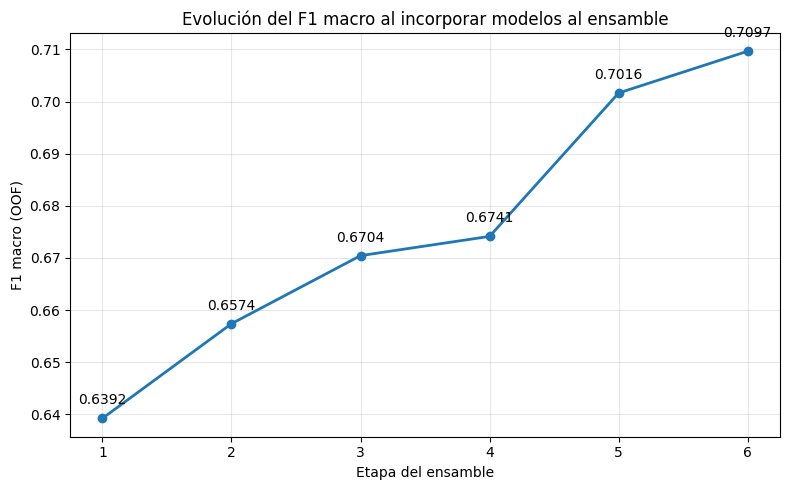

In [10]:
import matplotlib.pyplot as plt

resultados = pd.DataFrame({
    "Etapa": [1, 2, 3, 4, 5, 6],
    "Modelos incluidos": [
        "RL(embed_es)",
        "+ RL(MiniLM)",
        "+ XGB(TF-IDF) + XGB(embed_es)",
        "+ CNB",
        "+ BETO",
        "+ RoBERTuito",
    ],
    "F1 macro (OOF)": [f1_etapa_1, f1_etapa_2, f1_etapa_3, f1_etapa_4, f1_etapa_5, f1_etapa_6],
})
resultados["Mejora"] = resultados["F1 macro (OOF)"].diff()

display(resultados)

plt.figure(figsize=(8, 5))
plt.plot(resultados["Etapa"], resultados["F1 macro (OOF)"], marker="o", linewidth=2)
for _, fila in resultados.iterrows():
    plt.annotate(f'{fila["F1 macro (OOF)"]:.4f}',
                 (fila["Etapa"], fila["F1 macro (OOF)"]),
                 textcoords="offset points", xytext=(0, 10), ha="center")
plt.xticks(resultados["Etapa"])
plt.xlabel("Etapa del ensamble")
plt.ylabel("F1 macro (OOF)")
plt.title("Evolución del F1 macro al incorporar modelos al ensamble")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###Mejor modelo final

Tras todas las alternativas probadas, observamos que los ensambles de redes neuronales eran los que mejor perfomance final tenían, por lo tanto, para nuestro modelo final construimos lo siguiente:

La formula será:

$$\text{Ensamble} = \text{NN BETO} + \text{NN RoBERTa} + \text{XGBoost BERT FINE-TUNED}$$

Con este trío tenemos:

- El mejor predictor absoluto (NN BETO).
- Un corrector de sutilezas lingüísticas (NN RoBERTa).
- Un regulador basado en lógica no-lineal de árboles (XGBoost BERT FINE-TUNED).


#### Soft Voting

Variante de Voting que suma los vectores de probabilidad de cada clase ponderados por el peso que le asignamos a cada modelo, y recién al final aplica el `np.argmax`.

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
# ==========================================
# 1. CLASE DATASET NATIVA
# ==========================================
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    def __len__(self):
        return len(self.encodings['input_ids'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Carga del Test real de Kaggle
print("Cargando el conjunto de Test de Kaggle...")
test_df = pd.read_csv('test.csv')
X_test_txt = test_df['text'].tolist()

# ==========================================
# 2. EXTRACCIÓN DE PROBABILIDADES DE LAS REDES
# ==========================================

# --- MODELO 1: BETO ---
print("\n[BETO] Cargando modelo y tokenizador de Drive...")
tokenizer_beto = AutoTokenizer.from_pretrained('/content/drive/MyDrive/cdd_tp2_data/beto_nn_campeon')
model_beto = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/cdd_tp2_data/beto_nn_campeon').to(device)

encodings_beto = tokenizer_beto(X_test_txt, truncation=True, padding=True, max_length=128)
dataset_beto = TestDataset(encodings_beto)

print("[BETO] Calculando logits sobre el Test...")
trainer_beto = Trainer(model=model_beto)
preds_raw_beto = trainer_beto.predict(dataset_beto)
# Pasamos los logits a probabilidades usando Softmax
probs_test_beto = torch.nn.functional.softmax(torch.tensor(preds_raw_beto.predictions), dim=-1).numpy()


# --- MODELO 2: ROBERTA ---
print("\n[RoBERTa] Cargando modelo y tokenizador de Drive...")
tokenizer_roberta = AutoTokenizer.from_pretrained('/content/drive/MyDrive/cdd_tp2_data/roberta_nn_campeon')
model_roberta = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/cdd_tp2_data/roberta_nn_campeon').to(device)

encodings_roberta = tokenizer_roberta(X_test_txt, truncation=True, padding=True, max_length=128)
dataset_roberta = TestDataset(encodings_roberta)

print("[RoBERTa] Calculando logits sobre el Test...")
trainer_roberta = Trainer(model=model_roberta)
preds_raw_roberta = trainer_roberta.predict(dataset_roberta)
probs_test_roberta = torch.nn.functional.softmax(torch.tensor(preds_raw_roberta.predictions), dim=-1).numpy()


# ==========================================
# 3. EXTRACCIÓN DE PROBABILIDADES DE XGBOOST
# ==========================================
print("\n[XGBoost] Cargando modelo de Drive...")
xgb_model = joblib.load('/content/drive/MyDrive/cdd_tp2_data/xgboost_bert_tuneado.joblib')

print("[XGBoost] Calculando predict_proba...")
# Asegurate de que X_test_embeddings tenga las features semánticas de las 8500 filas de test
X_test_embeddings = joblib.load('/content/drive/MyDrive/cdd_tp2_data/bert_tuneado_embeddings_test.joblib')
probs_test_xgb = xgb_model.predict_proba(X_test_embeddings)

# ==========================================
# 4. CONTROL DE MATRICES Y VOTACIÓN BLANDA (SOFT VOTING)
# ==========================================
print("\n=== Control de alineación de formas ===")
print(f"BETO:    {probs_test_beto.shape}")
print(f"RoBERTa: {probs_test_roberta.shape}")
print(f"XGBoost: {probs_test_xgb.shape}")

# Pesos basados en la jerarquía de tu tabla de posiciones
W_BETO = 0.45
W_ROBERTA = 0.25
W_XGBOOST = 0.30

print("\nFusionando curvas de probabilidad (Soft Voting)...")
print(f"PROBA BETO:{probs_test_beto}")
print(f"PROBA ROBERTA:{probs_test_roberta}")
print(f"PROBA FINE-TUNED:{probs_test_xgb}")
probabilidades_finales = (W_BETO * probs_test_beto) + \
                         (W_ROBERTA * probs_test_roberta) + \
                         (W_XGBOOST * probs_test_xgb)

# Argmax final para consolidar etiquetas discretas (0, 1 o 2)
predicciones_ensamble = np.argmax(probabilidades_finales, axis=1)


# ==========================================
# 5. GENERACIÓN DEL ARCHIVO CAMPEÓN KAGGLE
# ==========================================
submission_ensamble = pd.DataFrame({
    'id': test_df['id'],
    'label': predicciones_ensamble
})

ruta_salida_final = '/content/drive/MyDrive/cdd_tp2_data/ensamble_soft_voting.csv'
submission_ensamble.to_csv(ruta_salida_final, index=False)

print(f"\n[¡PROCESO COMPLETADO EXITO!] Archivo final guardado en: {ruta_salida_final}")

Cargando el conjunto de Test de Kaggle...

[BETO] Cargando modelo y tokenizador de Drive...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[BETO] Calculando logits sobre el Test...



[RoBERTa] Cargando modelo y tokenizador de Drive...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[RoBERTa] Calculando logits sobre el Test...



[XGBoost] Cargando modelo de Drive...
[XGBoost] Calculando predict_proba...

=== Control de alineación de formas ===
BETO:    (8500, 3)
RoBERTa: (8500, 3)
XGBoost: (8500, 3)

Fusionando curvas de probabilidad (Soft Voting)...
PROBA BETO:[[1.9545772e-03 6.4330928e-02 9.3371451e-01]
 [2.8238041e-02 6.6910875e-01 3.0265319e-01]
 [9.7833283e-04 2.6301999e-02 9.7271967e-01]
 ...
 [1.4532068e-03 5.8732156e-02 9.3981463e-01]
 [9.8718446e-01 1.1481327e-02 1.3341905e-03]
 [1.3836379e-03 2.4099866e-02 9.7451651e-01]]
PROBA ROBERTA:[[0.01387603 0.1648888  0.8212351 ]
 [0.01495351 0.37751964 0.60752684]
 [0.00488387 0.06384856 0.9312676 ]
 ...
 [0.00474314 0.08427753 0.9109793 ]
 [0.9468251  0.050972   0.00220288]
 [0.00546436 0.06440013 0.93013555]]
PROBA FINE-TUNED:[[0.361391   0.29163852 0.34697044]
 [0.05052963 0.62662435 0.32284603]
 [0.00742898 0.11611766 0.8764534 ]
 ...
 [0.00479215 0.24350232 0.7517056 ]
 [0.7716951  0.20805682 0.02024814]
 [0.00465805 0.1270463  0.86829567]]

[¡PROCESO 

Este fue finalmente el mejor modelo que pudimos presentar en Kaggle, obtuvimos una metrica F1-SCORE de 0.73204

#Conclusiones

Para este problema en particular las mayores dificultades se encuentran en las reseñas más ambiguas o aquellas donde la razón por la cual el texto y el puntaje no obedecen a la lógica, es decir, hay elementos que afectan al puntaje y no están dentro del dataset.

De igual modo, la diversidad de modelos son capaces de explotar otras dimensiones del texto (sentimiento, conectores de ambigüedad, uso del lenguaje, etc), la unión de todos estos elementos va mejorando las perfomance del modelo final se manera cuasi logarítmica, acercándose cada vez más al techo estructural del dataset en cuestión.

Mediante la experimentación y el análisis que hemos llevado a cabo podemos concluir en que la mayor posibilidad de mejora en la perfomance se encuentra explorando los ensambles donde los modelos añaden cada vez más diversidad.

---
# Bibliografia
- https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
- https://www.ibm.com/think/topics/transfer-learning
- https://docs.pytorch.org/docs/2.12/generated/torch.optim.AdamW.html
- https://medium.com/@abhishekjainindore24/silu-and-gelu-activation-function-in-tra-a808c73c18da
- https://github.com/PlanTL-GOB-ES/lm-spanish